# 김민정 - 2차 EDA (~7/27(월)) 

In [2]:
import pandas as pd
import numpy as np

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:,.4f}".format)

In [3]:
import pandas as pd
from pathlib import Path

train_path = Path(
    r"C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP"
    r"\Fraud-FDS-Project\data\raw\fraudTrain.csv"
)

print("파일 존재 여부:", train_path.exists())
print("데이터 경로:", train_path)

train = pd.read_csv(
    train_path,
    low_memory=False
)

train = train.drop(
    columns=[
        col for col in train.columns
        if col.startswith("Unnamed")
    ],
    errors="ignore"
)

print("데이터 크기:", train.shape)
display(train.head())

파일 존재 여부: True
데이터 경로: C:\Users\splen\OneDrive\Desktop\BDAI_\BOOSTMAP\Fraud-FDS-Project\data\raw\fraudTrain.csv
데이터 크기: (1296675, 22)


,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,city,state,zip,lat,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud
0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.9700,Jennifer,Banks,F,561 Perry Cove,Moravian Falls,NC,28654,36.0788,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.0113,-82.0483,0
1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.2300,Stephanie,Gill,F,43039 Riley Greens Suite 393,Orient,WA,99160,48.8878,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.1590,-118.1865,0
2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.1100,Edward,Sanchez,M,594 White Dale Suite 530,Malad City,ID,83252,42.1808,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.1507,-112.1545,0
3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.0000,Jeremy,White,M,9443 Cynthia Court Apt. 038,Boulder,MT,59632,46.2306,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.0343,-112.5611,0
4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.9600,Tyler,Garcia,M,408 Bradley Rest,Doe Hill,VA,24433,38.4207,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.6750,-78.6325,0


In [ ]:
required_cols = ["merchant", "cc_num", "is_fraud"]

missing_cols = [
    col for col in required_cols
    if col not in train.columns
]

if missing_cols:
    raise KeyError(f"누락된 컬럼: {missing_cols}")

print("총 고객 수:", train["cc_num"].nunique())
print("총 가맹점 수:", train["merchant"].nunique())
print("전체 이상거래율:", round(train["is_fraud"].mean() * 100, 4), "%")

총 고객 수: 983
총 가맹점 수: 693
전체 이상거래율: 0.5789 %


전체 이상거래율 0.5789% 의미
: 전체 거래 1,000건 중 약 6건이 is_fraud=1 인 이상거래.
-> 이상거래율은 매우 낮아 정상/이상거래 간 클래스 불균형이 심한 데이터.

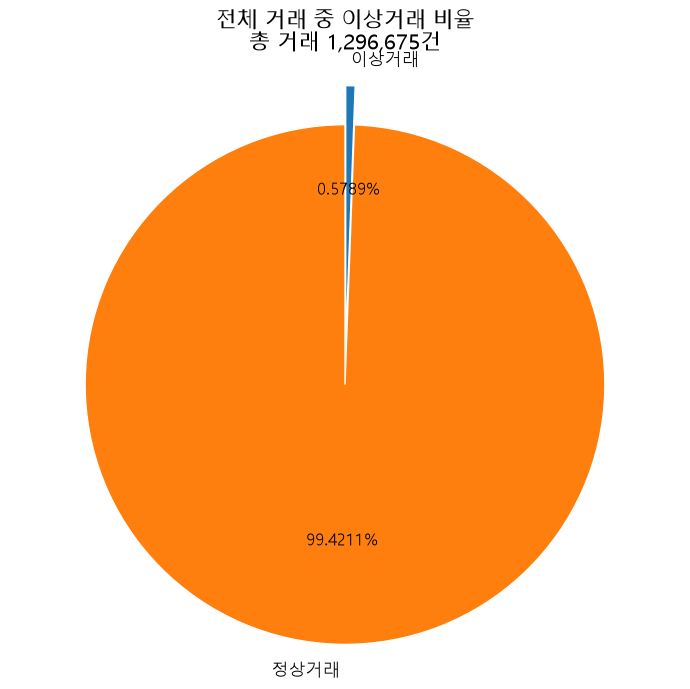

In [11]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

total_transaction_count = len(train)
anomaly_transaction_count = int(train["is_fraud"].sum())

normal_transaction_count = (
    total_transaction_count - anomaly_transaction_count
)

transaction_counts = [
    anomaly_transaction_count,
    normal_transaction_count
]

transaction_labels = [
    "이상거래",
    "정상거래"
]

plt.figure(figsize=(7, 7))

plt.pie(
    transaction_counts,
    labels=transaction_labels,
    autopct="%1.4f%%",
    startangle=90,
    counterclock=False,
    explode=(0.15, 0),
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 12}
)

plt.title(
    f"전체 거래 중 이상거래 비율\n총 거래 {total_transaction_count:,}건",
    fontsize=15
)

plt.axis("equal")
plt.tight_layout()
plt.show()

In [9]:
total_customer_count = train["cc_num"].nunique()

# 이상거래가 1건 이상 있는 고객
anomaly_customer_count = (
    train.loc[train["is_fraud"] == 1, "cc_num"]
    .nunique()
)

normal_only_customer_count = total_customer_count - anomaly_customer_count

# 고객 기준 이상거래 경험률
anomaly_customer_rate = (
    anomaly_customer_count / total_customer_count * 100
)

print("총 고객 수:", total_customer_count)
print("이상거래 경험 고객 수:", anomaly_customer_count)
print("이상거래 미경험 고객 수:", normal_only_customer_count)
print("이상거래 경험 고객 비율:", round(anomaly_customer_rate, 2), "%")

총 고객 수: 983
이상거래 경험 고객 수: 762
이상거래 미경험 고객 수: 221
이상거래 경험 고객 비율: 77.52 %


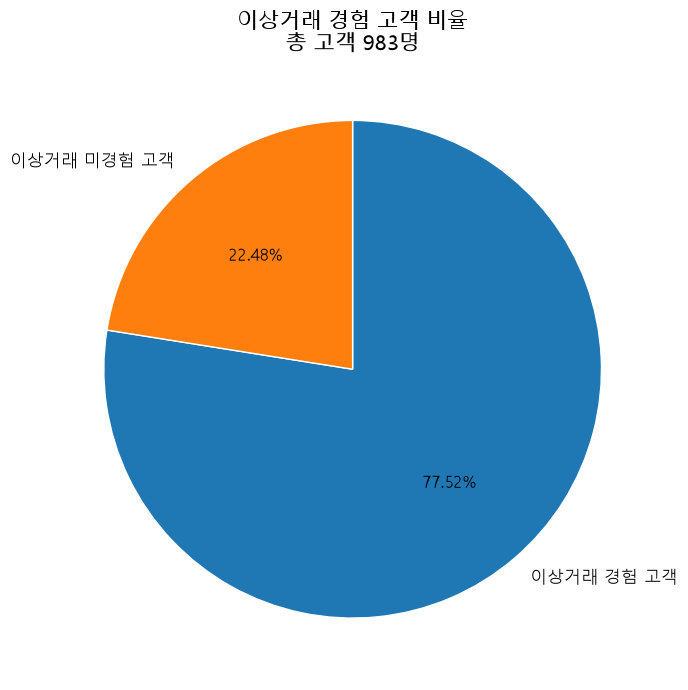

In [10]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

total_customer_count = train["cc_num"].nunique()

anomaly_customer_count = (
    train.loc[train["is_fraud"] == 1, "cc_num"]
    .nunique()
)

no_anomaly_customer_count = (
    total_customer_count - anomaly_customer_count
)

customer_counts = [
    anomaly_customer_count,
    no_anomaly_customer_count
]

customer_labels = [
    "이상거래 경험 고객",
    "이상거래 미경험 고객"
]

plt.figure(figsize=(7, 7))

plt.pie(
    customer_counts,
    labels=customer_labels,
    autopct="%1.2f%%",
    startangle=90,
    counterclock=False,
    wedgeprops={"edgecolor": "white"},
    textprops={"fontsize": 12}
)

plt.title(
    f"이상거래 경험 고객 비율\n총 고객 {total_customer_count:,}명",
    fontsize=15
)

plt.axis("equal")
plt.tight_layout()
plt.show()

In [14]:
## 가맹점별 거래 현황 계산

# 전체 거래의 is_fraud 비율 -> 0.5789%
overall_is_fraud_rate = train["is_fraud"].mean()

# 가맹점별 기본 지표
merchant_summary = (
    train.groupby("merchant", as_index=False)
    .agg(
        total_transactions=("is_fraud", "size"),  # 전체 거래 건수
        is_fraud_transactions=("is_fraud", "sum"), # is_fraud=1 거래 건수
        is_fraud_rate=("is_fraud", "mean"), # is_fraud=1 거래 비율
        unique_customers=("cc_num", "nunique") # 해당 가맹점을 이용한 고객 수
    )
)

# 가맹점별 is_fraud 경험 고객 수
is_fraud_customer_summary = (
    train.loc[train["is_fraud"] == 1]
    .groupby("merchant")["cc_num"]
    .nunique()
    .rename("is_fraud_customers")
    .reset_index()
)

# 가맹점 요약표에 결합
merchant_summary = merchant_summary.merge(
    is_fraud_customer_summary,
    on="merchant",
    how="left"
)

# is_fraud 거래가 없었던 가맹점은 고객 수를 0으로 처리(NaN->0)
merchant_summary["is_fraud_customers"] = (
    merchant_summary["is_fraud_customers"]
    .fillna(0)
    .astype(int)
)

# 가맹점별 is_fraud 비율을 백분율로 표현
merchant_summary["is_fraud_rate_pct"] = (
    merchant_summary["is_fraud_rate"] * 100
).round(3)

# 전체 평균 is_fraud 비율 대비 배수: 해당 가맹점의 is_fraud 비율이 전체 평균보다 몇 배 높은지
merchant_summary["is_fraud_rate_lift"] = (
    merchant_summary["is_fraud_rate"]
    / overall_is_fraud_rate
).round(2)

# 해당 가맹점 이용 고객 중 is_fraud 경험 고객 비율
merchant_summary["is_fraud_customer_rate_pct"] = (
    merchant_summary["is_fraud_customers"]
    / merchant_summary["unique_customers"]
    * 100
).round(2)

# 전체 평균 대비 is_fraud 비율이 높은 순으로 정렬
merchant_summary = merchant_summary.sort_values(
    ["is_fraud_rate_lift", "is_fraud_transactions"],
    ascending=False
).reset_index(drop=True)

display(merchant_summary.head(5))

,merchant,total_transactions,is_fraud_transactions,is_fraud_rate,unique_customers,is_fraud_customers,is_fraud_rate_pct,is_fraud_rate_lift,is_fraud_customer_rate_pct
0,fraud_Kozey-Boehm,1866,48,0.0257,704,46,2.5720,4.4400,6.5300
1,"fraud_Herman, Treutel and Dickens",1300,33,0.0254,625,33,2.5380,4.3900,5.2800
2,fraud_Kerluke-Abshire,1838,41,0.0223,697,39,2.2310,3.8500,5.6000
3,fraud_Brown PLC,1176,26,0.0221,585,26,2.2110,3.8200,4.4400
4,fraud_Goyette Inc,1943,42,0.0216,720,42,2.1620,3.7300,5.8300


In [ ]:
## 가맹점 분석 시각화를 위한 공통설정
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [ ]:
## 시각화용 파생변수 생성

# 원본 보호를 위해 시각화용 데이터 복사
merchant_viz = merchant_summary.copy()

# is_fraud 발생 여부
merchant_viz["has_is_fraud"] = np.where(
    merchant_viz["is_fraud_transactions"] > 0,
    "발생",
    "미발생"
)

# 전체 평균보다 is_fraud 비율이 높은지
merchant_viz["above_average_rate"] = np.where(
    merchant_viz["is_fraud_rate_lift"] >= 1,
    "전체 평균 이상",
    "전체 평균 미만"
)

# 거래량 중앙값
transaction_median = merchant_viz["total_transactions"].median()

# 가맹점 위험 유형
merchant_viz["merchant_risk_group"] = np.select(
    [
        (merchant_viz["total_transactions"] >= transaction_median)
        & (merchant_viz["is_fraud_rate_lift"] >= 1),

        (merchant_viz["total_transactions"] < transaction_median)
        & (merchant_viz["is_fraud_rate_lift"] >= 1),

        (merchant_viz["total_transactions"] >= transaction_median)
        & (merchant_viz["is_fraud_rate_lift"] < 1)
    ],
    [
        "거래량·비율 모두 높음",
        "거래량은 적지만 비율 높음",
        "거래량은 많지만 비율 낮음"
    ],
    default="거래량·비율 모두 낮음"
)

merchant_viz.head()

,merchant,total_transactions,is_fraud_transactions,is_fraud_rate,unique_customers,is_fraud_customers,is_fraud_rate_pct,is_fraud_rate_lift,is_fraud_customer_rate_pct,has_is_fraud,above_average_rate,merchant_risk_group
0,fraud_Kozey-Boehm,1866,48,0.0257,704,46,2.5720,4.4400,6.5300,발생,전체 평균 이상,거래량·비율 모두 높음
1,"fraud_Herman, Treutel and Dickens",1300,33,0.0254,625,33,2.5380,4.3900,5.2800,발생,전체 평균 이상,거래량은 적지만 비율 높음
2,fraud_Kerluke-Abshire,1838,41,0.0223,697,39,2.2310,3.8500,5.6000,발생,전체 평균 이상,거래량은 적지만 비율 높음
3,fraud_Brown PLC,1176,26,0.0221,585,26,2.2110,3.8200,4.4400,발생,전체 평균 이상,거래량은 적지만 비율 높음
4,fraud_Goyette Inc,1943,42,0.0216,720,42,2.1620,3.7300,5.8300,발생,전체 평균 이상,거래량·비율 모두 높음


New 파생변수
has_is_fraud: 해당 가맹점에서 is_fraud=1 거래가 발생했는지
above_average_rate: 가맹점의 is_fraud 비율이 전체평균보다 이상인지
merchant_risk_group: 거래량과 is_fraud 비율을 함께 고려한 가맹점 위험 유형

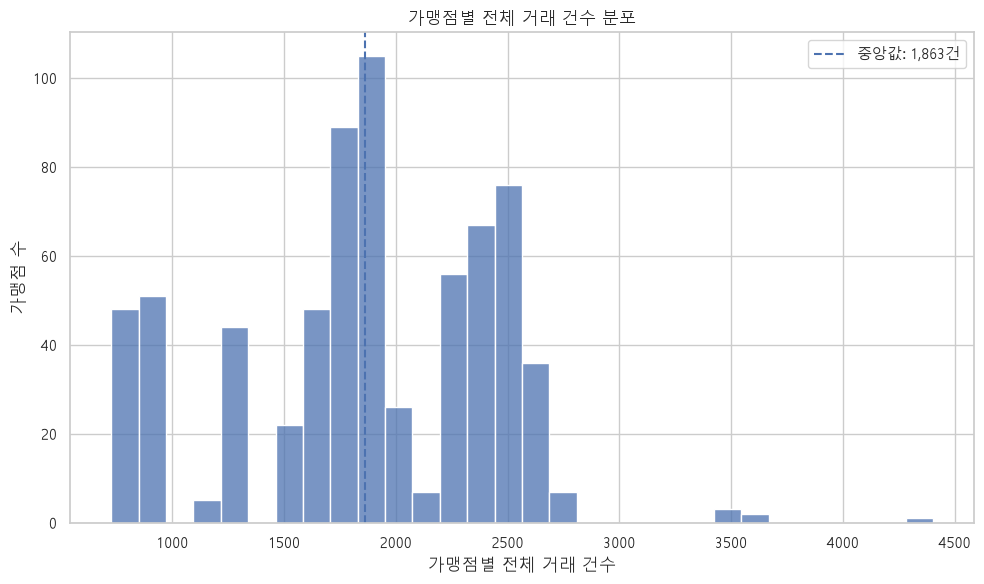

In [ ]:
## '가맹점별 전체 거래 건수' 분포

plt.figure(figsize=(10, 6))

sns.histplot(
    data=merchant_viz,
    x="total_transactions",
    bins=30
)

plt.axvline(
    merchant_viz["total_transactions"].median(),
    linestyle="--",
    label=f'중앙값: {merchant_viz["total_transactions"].median():,.0f}건'
)

plt.title("가맹점별 전체 거래 건수 분포")
plt.xlabel("가맹점별 전체 거래 건수")
plt.ylabel("가맹점 수")
plt.legend()
plt.tight_layout()
plt.show()

=> 가맹점 거래량은 중앙값인 1,863건 부근에 많이 집중되어 있지만,
약 3,500~4,500건의 거래가 발생한 일부 고거래량 가맹점도 존재한다.

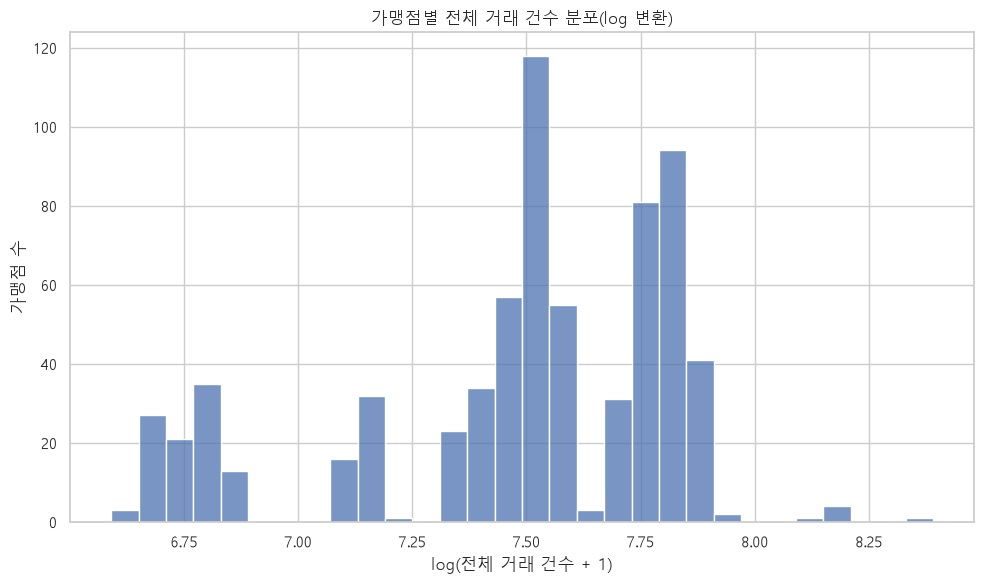

In [ ]:
## 로그 변환 그래프 (거래량 차이가 커서)
plt.figure(figsize=(10, 6))

sns.histplot(
    np.log1p(merchant_viz["total_transactions"]),
    bins=30
)

plt.title("가맹점별 전체 거래 건수 분포(log 변환)")
plt.xlabel("log(전체 거래 건수 + 1)")
plt.ylabel("가맹점 수")
plt.tight_layout()
plt.show()

=> 로그 변환도 비슷.
로그변환: 거래량이 매우 큰 일부 가맹점 때문에 나머지 가맹점의 분포가 눌려보이는 문제를 줄이기 위해 함.(오른쪽으로 치우친 거래량 분포를 보기쉽게 바꿈)


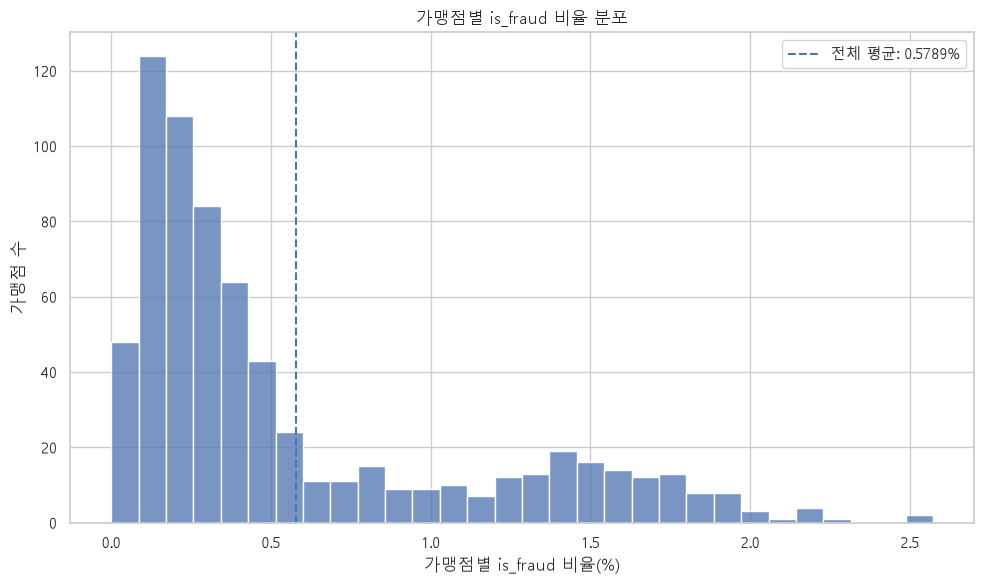

In [ ]:
## 가맹점별 is_fraud 비율 분포

plt.figure(figsize=(10, 6))

sns.histplot(
    data=merchant_viz,
    x="is_fraud_rate_pct",
    bins=30
)

plt.axvline(
    overall_is_fraud_rate * 100,
    linestyle="--",
    label=f"전체 평균: {overall_is_fraud_rate * 100:.4f}%"
)

plt.title("가맹점별 is_fraud 비율 분포")
plt.xlabel("가맹점별 is_fraud 비율(%)")
plt.ylabel("가맹점 수")
plt.legend()
plt.tight_layout()
plt.show()

=> 대부분의 가맹점은 전체 평균인 0.5789% 이하의 낮은 is_fraud=1 비율을 보이지만,
일부 가맹점은 1~2.5%의 높은 비율을 보여 is_fraud 거래가 특정 가맹점군에 상대적으로 집중될 가능성이 있다. (단, 거래 건수가 적어서 비율이 높아졌을 수도 있으므로, 최소 거래 건수 기준을 적용한 뒤 우선 관리 가맹점을 선정해야 함)

In [7]:
## 이상거래 발생 가맹점 수 확인

total_merchant_count = merchant_summary["merchant"].nunique()

anomaly_merchant_count = (
    merchant_summary["anomaly_transactions"] > 0
).sum()

no_anomaly_merchant_count = (
    merchant_summary["anomaly_transactions"] == 0
).sum()

print("총 가맹점 수:", total_merchant_count)
print("이상거래 발생 가맹점 수:", anomaly_merchant_count)
print("이상거래 미발생 가맹점 수:", no_anomaly_merchant_count)
print(
    "이상거래 발생 가맹점 비율:",
    round(anomaly_merchant_count / total_merchant_count * 100, 2),
    "%"
)

총 가맹점 수: 693
이상거래 발생 가맹점 수: 679
이상거래 미발생 가맹점 수: 14
이상거래 발생 가맹점 비율: 97.98 %


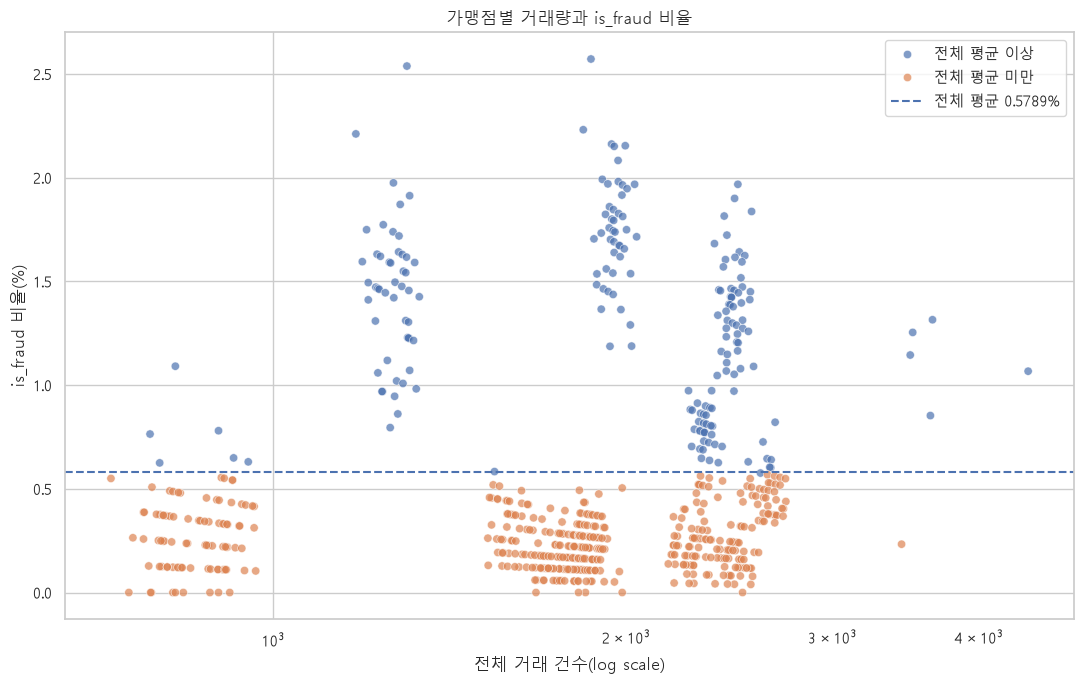

In [ ]:
## '가맹점별 거래량'과 'is_fraud 비율' 관계
## -> 거래량이 많은 가맹점일수록 is_fraud 거래가 많이 관측되는지 확인.

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=merchant_viz,
    x="total_transactions",
    y="is_fraud_rate_pct",
    hue="above_average_rate",
    alpha=0.7
)

plt.axhline(
    overall_is_fraud_rate * 100,
    linestyle="--",
    label=f"전체 평균 {overall_is_fraud_rate * 100:.4f}%"
)

plt.xscale("log")

plt.title("가맹점별 거래량과 is_fraud 비율")
plt.xlabel("전체 거래 건수(log scale)")
plt.ylabel("is_fraud 비율(%)")
plt.legend()
plt.tight_layout()
plt.show()

=> 거래량 자체보다 '가맹점별 is_fraud 비율'의 차이가 더 중요하겠군.

인사이트1: 거래량이 많다고 is_fraud 비율이 반드시 높아지지는 않음.

인사이트2: 비슷한 거래량의 가맹점도 is_fraud 비율 차이가 매우 큼.
-> category, 고객 구성, 평균 결제금액, 이용 시간대, 특정 고객에게 이상거래가 집중되는 정도 등의 요인 추가 분석이 필요함.

인사이트3: 전체 평균보다 2~4% 높은 가맹점이 다수 존재함.
전체 평균은 0.5789% 지만, 약 1.2~2.2%의 가맹점이 여러 개 존재함.
-> 따라서, 전체 평균보다 몇 배 높은지인 'is_fraud_rate_lift'를 이용해 위험 가맹점을 구분하는 것이 적절함.

인사이트4: 거래량 약 1,300~1,600건 구간에 '고비율 가맹점군'이 존재함.
이 구간에 is_fraud=1 비율이 약 1~2.5%인 가맹점들이 모여 있음. 특정 업종이나 가맹점군의 공통 특성이 있는지 확인 필요.

인사이트5: 거래량 약 1,800~2,100건 구간에서 '두 집단이 뚜렷'하게 나뉨.
약 0.1~0.5%의 낮은 비율 가맹점/ 약 1.2~2.2%의 높은 비율 가맹점이 동시에 존재.
-> 거래량은 비슷하지만 위험 수준은 크게 다르므로, 고위험/저위험 가맹점을 비교하기 좋은 분석 대상.
-> 비교 항목: 업종 구성, 평균 거래금액, 심야 거래 비중, 원거리 거래 비중, 고객별 반복 이상거래 여부

인사이트6: 우측 상단(고거래량, 고비율) 가맹점이 가장 중요한 관리 대상.
비율만 높은 소규모 가맹점보다, 실제 이상거래 건수가 많을 가능성이 높기 때문에 'FDS 운영상 가장 먼저 조사해야 하는 가맹점군'임.

인사이트7: 좌측 상단(저거래량, 고비율) 가맹점은 별도로 해석.
실제로 위험한 가맹점일수도, 거래 건수가 적어서 비율이 높을수도 있음.
-> 따라서 '최소 거래 건수 기준'이나 '신뢰구간'을 함께 적용해야 함.

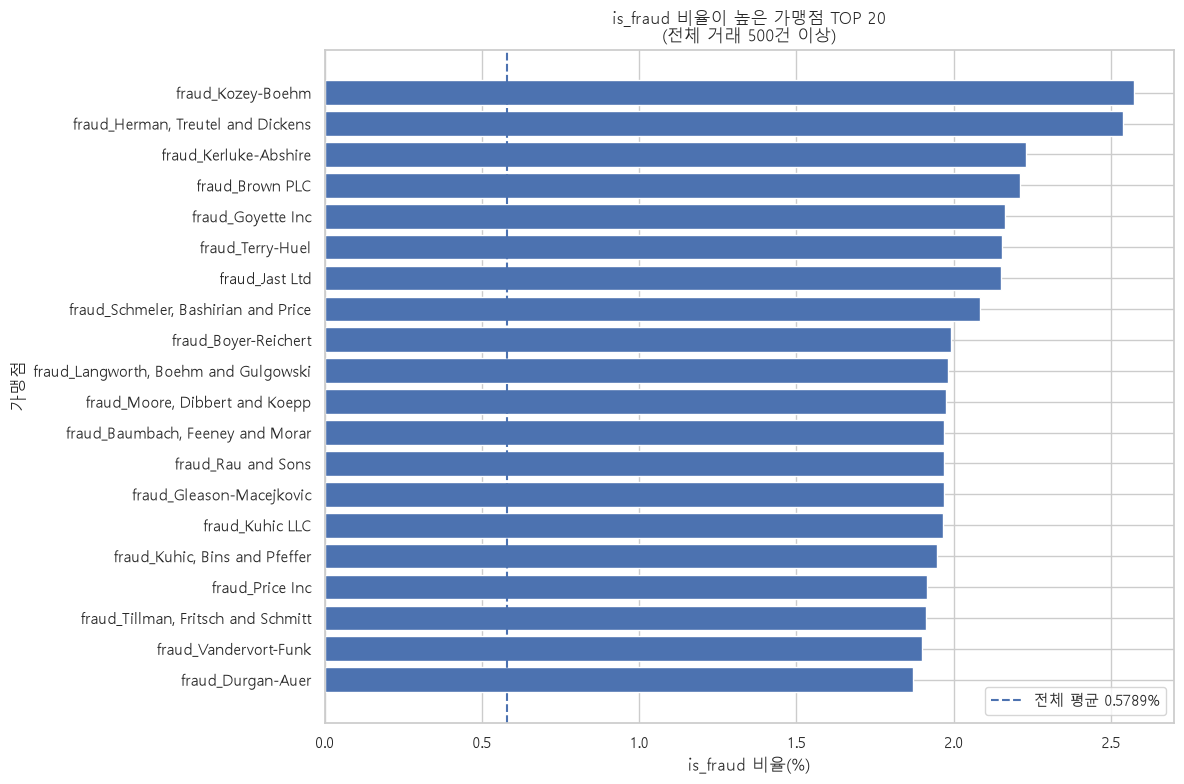

In [24]:
## is_fraud 비율이 높은 가맹점 TOP 20

minimum_transactions = 500

top_rate_merchants = (
    merchant_viz.loc[
        merchant_viz["total_transactions"] >= minimum_transactions
    ]
    .nlargest(20, "is_fraud_rate_pct")
    .sort_values("is_fraud_rate_pct")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_rate_merchants["merchant"],
    top_rate_merchants["is_fraud_rate_pct"]
)

plt.axvline(
    overall_is_fraud_rate * 100,
    linestyle="--",
    label=f"전체 평균 {overall_is_fraud_rate * 100:.4f}%"
)

plt.title(
    f"is_fraud 비율이 높은 가맹점 TOP 20\n"
    f"(전체 거래 {minimum_transactions:,}건 이상)"
)
plt.xlabel("is_fraud 비율(%)")
plt.ylabel("가맹점")
plt.legend()
plt.tight_layout()
plt.show()

=> 상위 20곳 가맹점의 is_fraud 비율은 약 1.9~2.6%로, 전체 평균 0.5789%보다 약 3.3~4.5배 높게 나타남. 
-> 해당 가맹점의 업종, 평균 금액, 이용 시간대, 이상거래 고객 수 등을 추가로 비교해야 함.
(최소 거래 500건 기준을 적용했기 때문에, 거래가 몇 건 없는 가맹점에서 우연히 비율이 높아진 현상일 가능성은 줄임)

추가로, is_fraud 비율이 높은 순으로 'category' 정리(다영님or세진님)한 거에서
각 category마다 is_fraud 비율이 높은 '가맹점' 14개 그래프로 다 시각화 해 보기.

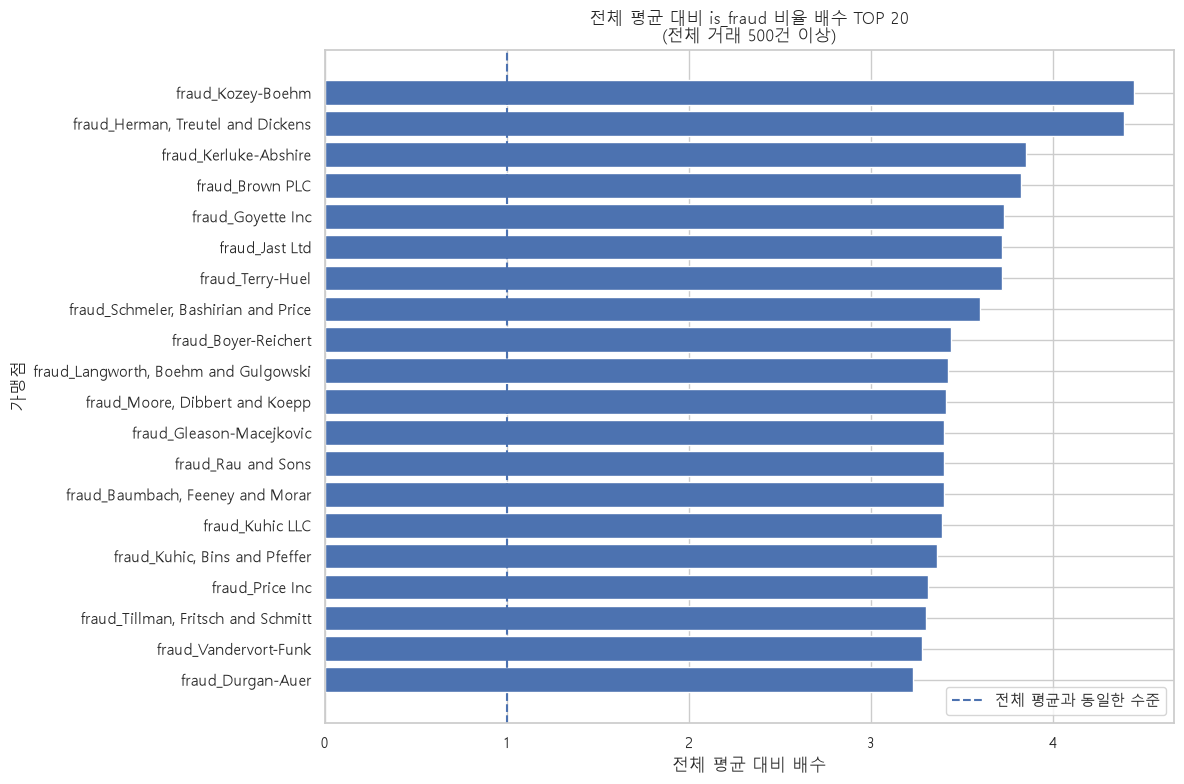

In [ ]:
## 배수만 따로 보기

minimum_transactions = 500

top_lift_merchants = (
    merchant_viz.loc[
        merchant_viz["total_transactions"] >= minimum_transactions
    ]
    .nlargest(20, "is_fraud_rate_lift")
    .sort_values("is_fraud_rate_lift")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_lift_merchants["merchant"],
    top_lift_merchants["is_fraud_rate_lift"]
)

plt.axvline(
    1,
    linestyle="--",
    label="전체 평균과 동일한 수준"
)

plt.title(
    f"전체 평균 대비 is_fraud 비율 배수 TOP 20\n"
    f"(전체 거래 {minimum_transactions:,}건 이상)"
)
plt.xlabel("전체 평균 대비 배수")
plt.ylabel("가맹점")
plt.legend()
plt.tight_layout()
plt.show()

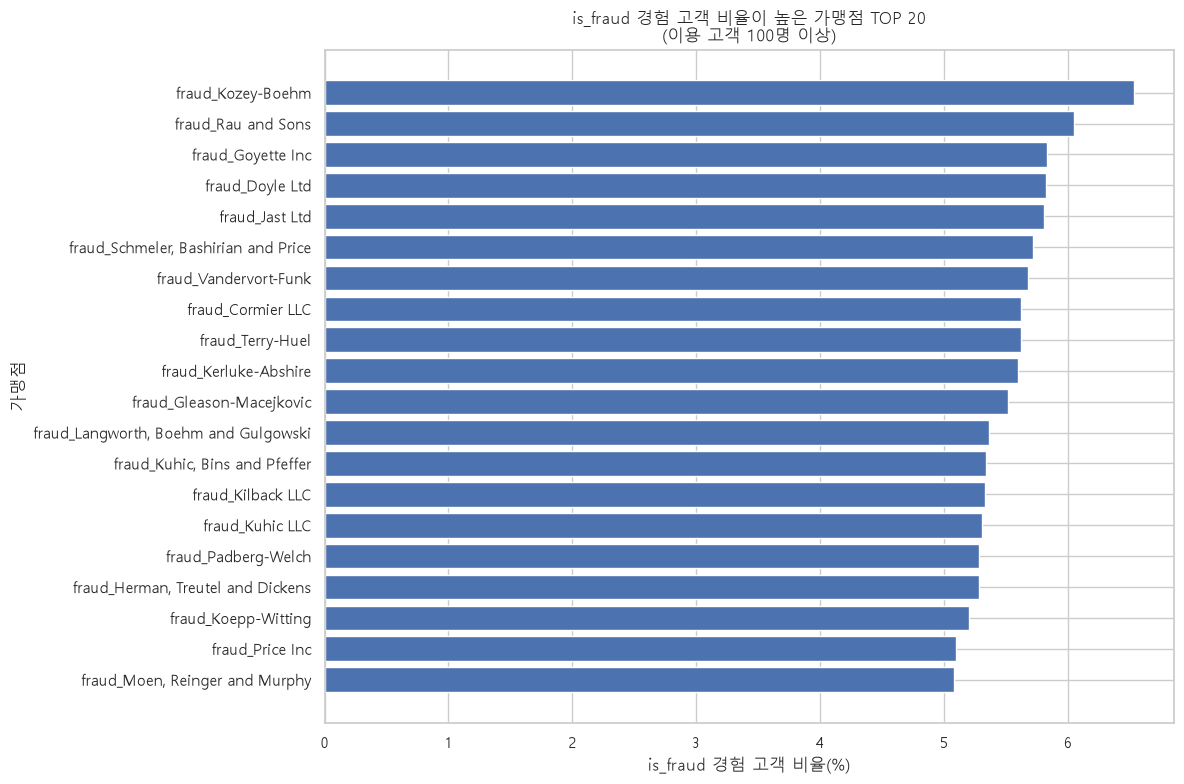

In [28]:
minimum_customers = 100

top_customer_rate = (
    merchant_viz.loc[
        merchant_viz["unique_customers"] >= minimum_customers
    ]
    .nlargest(20, "is_fraud_customer_rate_pct")
    .sort_values("is_fraud_customer_rate_pct")
)

plt.figure(figsize=(12, 8))

plt.barh(
    top_customer_rate["merchant"],
    top_customer_rate["is_fraud_customer_rate_pct"]
)

plt.title(
    f"is_fraud 경험 고객 비율이 높은 가맹점 TOP 20\n"
    f"(이용 고객 {minimum_customers:,}명 이상)"
)
plt.xlabel("is_fraud 경험 고객 비율(%)")
plt.ylabel("가맹점")
plt.tight_layout()
plt.show()

=> 가맹점 이용 고객 중, is_fraud=1 거래를 한 번이라도 경험한 고객의 비율.
이용 고객이 100명 이상인 가맹점 중 상위 20곳에서는 전체 고객의 약 5.1~6.6%가 is_fraud 거래를 경험함.

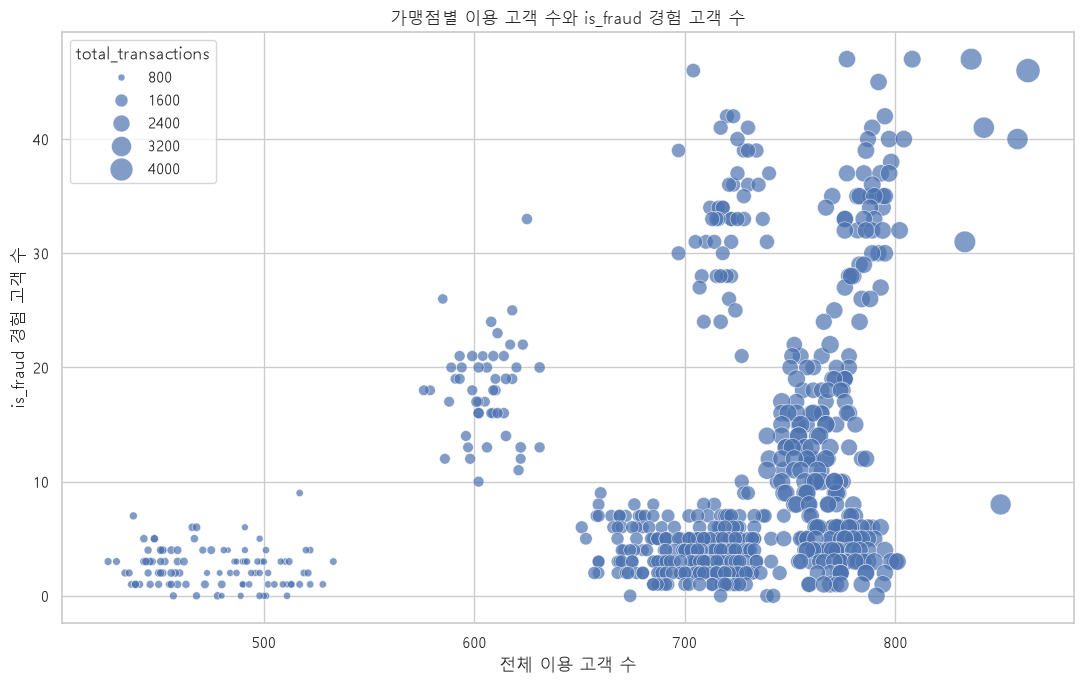

In [ ]:
## 가맹점 '이용' 고객 수와 'is_fraud 경험' 고객 수 관계
## -> 이용자가 많은 가맹점일수록 자연스럽게 is_fraud 경험 고객 수도 많은지.

plt.figure(figsize=(11, 7))

sns.scatterplot(
    data=merchant_viz,
    x="unique_customers",
    y="is_fraud_customers",
    size="total_transactions",
    sizes=(20, 300),
    alpha=0.7
)

plt.title("가맹점별 이용 고객 수와 is_fraud 경험 고객 수")
plt.xlabel("전체 이용 고객 수")
plt.ylabel("is_fraud 경험 고객 수")
plt.tight_layout()
plt.show()

=> 가맹점 이용 고객 수가 많을수록 is_fraud 경험 고객 수도 늘어나는 경향'은 있음.'
- 최우선 관리대상: 우측 상단 가맹점. 이용 고객도 700-820명으로 많고 is_fraud 경험고객도 25-45명으로 많음. 이상거래가 여러 고객에게 넓게 확산된 가맹점군.
- 중간 고객 수(600-700)인데 경험고객이 많은 가맹점도 주의.
- 우측 하단 가맹점: 고객 많지만 사기 거래 경험은 적음. 이상거래 확산 정도가 상대적으로 낮은 집단 

-> 각 군집별로 category부터 파악!

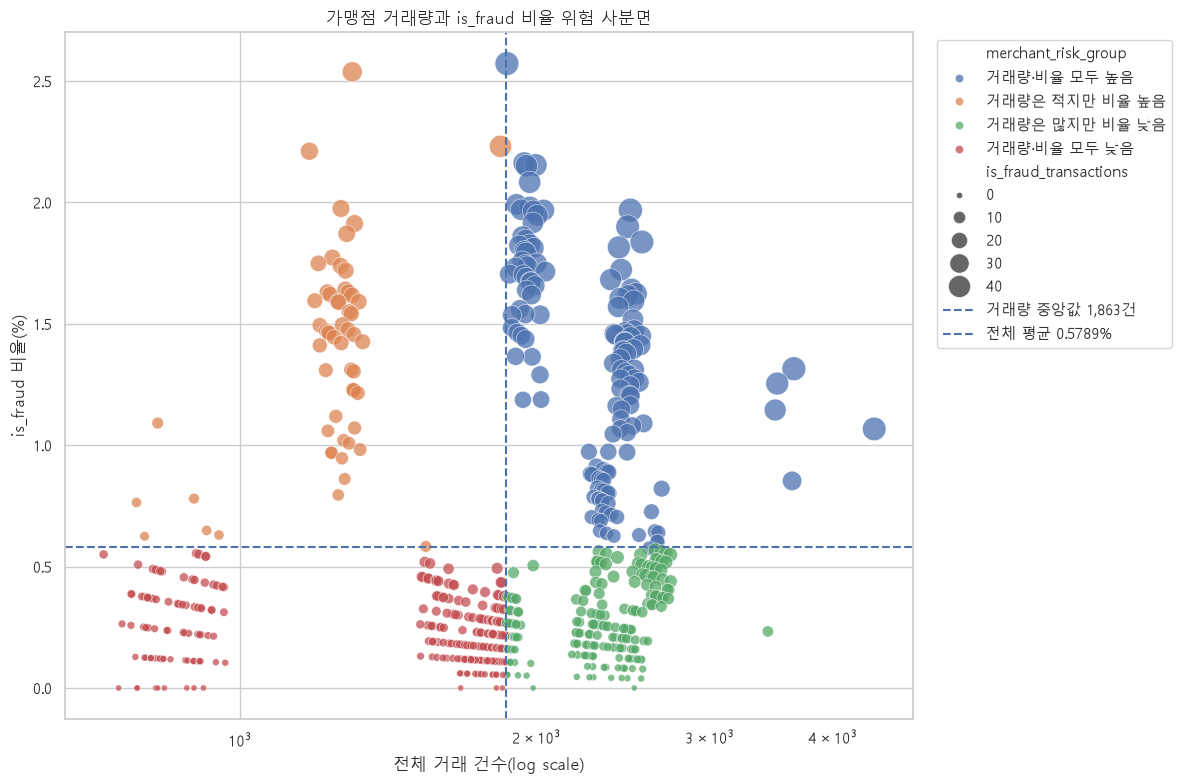

In [ ]:
## 거래량과 is_fraud 비율을 이용한 '위험 사분면'
plt.figure(figsize=(12, 8))

sns.scatterplot(
    data=merchant_viz,
    x="total_transactions",
    y="is_fraud_rate_pct",
    hue="merchant_risk_group",
    size="is_fraud_transactions",
    sizes=(20, 300),
    alpha=0.75
)

plt.axvline(
    transaction_median,
    linestyle="--",
    label=f"거래량 중앙값 {transaction_median:,.0f}건"
)

plt.axhline(
    overall_is_fraud_rate * 100,
    linestyle="--",
    label=f"전체 평균 {overall_is_fraud_rate * 100:.4f}%"
)

plt.xscale("log")

plt.title("가맹점 거래량과 is_fraud 비율 위험 사분면")
plt.xlabel("전체 거래 건수(log scale)")
plt.ylabel("is_fraud 비율(%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

우측 상단에 있는 가맹점들은 거래량도 많고 is_fraud 비율도 높은 우선 관리 대상.

but, 위 그래프의 한계점: 군집이 크게 7개의 유형으로 보이는데 4개로만 나눔.

In [39]:
# 기존 merchant_summary는 수정하지 않고 별도 복사
merchant_7group = merchant_summary.copy()

# 거래량 기준값
volume_q33 = merchant_7group["total_transactions"].quantile(0.33)
volume_q67 = merchant_7group["total_transactions"].quantile(0.67)
volume_q95 = merchant_7group["total_transactions"].quantile(0.95)

print(f"거래량 33% 기준: {volume_q33:,.0f}건")
print(f"거래량 67% 기준: {volume_q67:,.0f}건")
print(f"거래량 95% 기준: {volume_q95:,.0f}건")
print(f"전체 is_fraud 비율: {overall_is_fraud_rate * 100:.4f}%")

거래량 33% 기준: 1,736건
거래량 67% 기준: 2,265건
거래량 95% 기준: 2,625건
전체 is_fraud 비율: 0.5789%


In [ ]:
## 7개 집단 생성

conditions = [
    # 7번째 집단을 먼저 판정
    (merchant_7group["total_transactions"] >= volume_q95)
    & (merchant_7group["is_fraud_rate"] >= overall_is_fraud_rate),

    (merchant_7group["total_transactions"] < volume_q33)
    & (merchant_7group["is_fraud_rate"] < overall_is_fraud_rate),

    (merchant_7group["total_transactions"] < volume_q33)
    & (merchant_7group["is_fraud_rate"] >= overall_is_fraud_rate),

    (merchant_7group["total_transactions"] >= volume_q33)
    & (merchant_7group["total_transactions"] < volume_q67)
    & (merchant_7group["is_fraud_rate"] < overall_is_fraud_rate),

    (merchant_7group["total_transactions"] >= volume_q33)
    & (merchant_7group["total_transactions"] < volume_q67)
    & (merchant_7group["is_fraud_rate"] >= overall_is_fraud_rate),

    (merchant_7group["total_transactions"] >= volume_q67)
    & (merchant_7group["is_fraud_rate"] < overall_is_fraud_rate),

    (merchant_7group["total_transactions"] >= volume_q67)
    & (merchant_7group["total_transactions"] < volume_q95)
    & (merchant_7group["is_fraud_rate"] >= overall_is_fraud_rate)
]

group_names = [
    "초고거래량·고비율",
    "저거래량·저비율",
    "저거래량·고비율",
    "중거래량·저비율",
    "중거래량·고비율",
    "고거래량·저비율",
    "고거래량·고비율"
]

merchant_7group["merchant_risk_group_7"] = np.select(
    conditions,
    group_names,
    default="기타"
)

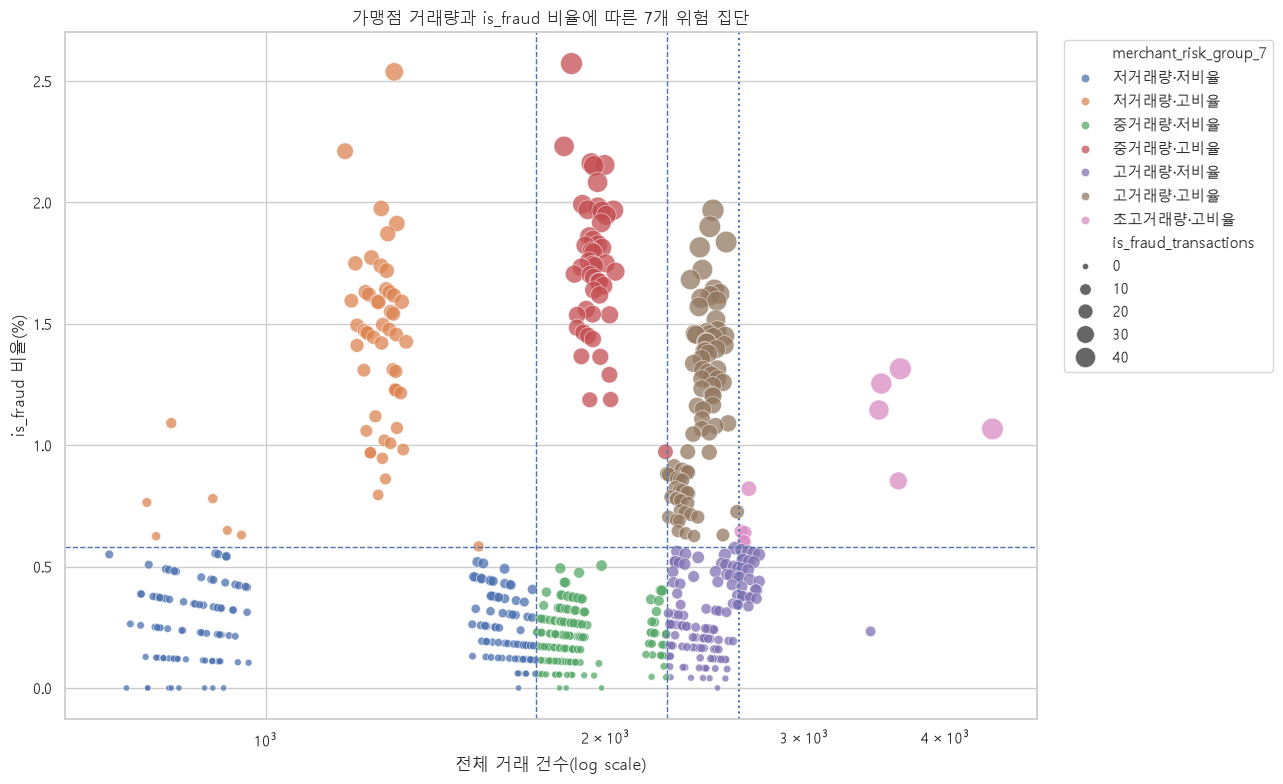

In [ ]:
## 7개 집단 시각화

group_order_7 = [
    "저거래량·저비율",
    "저거래량·고비율",
    "중거래량·저비율",
    "중거래량·고비율",
    "고거래량·저비율",
    "고거래량·고비율",
    "초고거래량·고비율"
]

plt.figure(figsize=(13, 8))

sns.scatterplot(
    data=merchant_7group,
    x="total_transactions",
    y="is_fraud_rate_pct",
    hue="merchant_risk_group_7",
    hue_order=group_order_7,
    size="is_fraud_transactions",
    sizes=(20, 250),
    alpha=0.75
)

plt.axvline(volume_q33, linestyle="--", linewidth=1)
plt.axvline(volume_q67, linestyle="--", linewidth=1)
plt.axvline(volume_q95, linestyle=":", linewidth=1.5)

plt.axhline(
    overall_is_fraud_rate * 100,
    linestyle="--",
    linewidth=1
)

plt.xscale("log")

plt.title("가맹점 거래량과 is_fraud 비율에 따른 7개 위험 집단")
plt.xlabel("전체 거래 건수(log scale)")
plt.ylabel("is_fraud 비율(%)")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

=> 사실 맨 위에서 하나의 색깔로 봤던 그래프랑 똑같은 그래프임. 집단을 7개로 나눴을뿐.

1. K-means(비지도학습 클러스터링)
기존에 만든 7개 집단을 보지 않고, 거래량이나 is_fraud 비율 등 숫자만 보고 비슷한 가맹점끼리 새롭게 묶음 -> K=7로 설정해도, 우리가 정한 7개 위험군과 동일하게 나뉜다는 보장은 없음
2. 이미 만든 7개 집단 학습시키는 경우(지도학습 분류)
입력: 거래량, is_fraud 비율, 이용 고객 수, 이상거래 고객 비율 등
정답: 저거래량·저비율, 고거래량·고비율 등 7개 집단
모델: random forest, decision tree
3. ☆ 혼합 방식(1단계에서 7개 위험군 유지, 2단계에서 각 위험군 내부 클러스터링)
ex: 예를 들어, 고거래량·고비율 가맹점만 따로 추출한 뒤, 평균 거래 금액, 심야 거래 비중 등의 변수로 K-means 실행 
=> 같은 고위험군 안에서도 다음처럼 더 구체적으로 나눌 수 있음.
- 여러 고객에게 넓게 발생한 고객 확산형
- 일부 고객에게 반복된 고객 집중형
- 심야 거래가 많은 시간대 이탈형
- 고액 거래가 많은 고액 위험형

=> 지도학습으로 기본적으로 해놓고, K-means clustering으로 군집 분석해서 이상치까지 파악. 위험 유형 나누기. 

In [ ]:
# 집단 순서
group_order_7 = [
    "저거래량·저비율",
    "저거래량·고비율",
    "중거래량·저비율",
    "중거래량·고비율",
    "고거래량·저비율",
    "고거래량·고비율",
    "초고거래량·고비율"
]

# 분석용 데이터 복사
merchant_7group_analysis = merchant_7group.copy()

# 전체 가맹점 수와 전체 is_fraud 거래 건수
total_merchants = merchant_7group_analysis["merchant"].nunique()
total_is_fraud_transactions = (
    merchant_7group_analysis["is_fraud_transactions"].sum()
)
total_transactions = (
    merchant_7group_analysis["total_transactions"].sum()
)

# 7개 집단별 수치 요약
merchant_7group_summary = (
    merchant_7group_analysis
    .groupby(
        "merchant_risk_group_7",
        observed=True
    )
    .agg(
        merchant_count=("merchant", "size"),

        total_transactions=("total_transactions", "sum"),
        mean_transactions=("total_transactions", "mean"),
        median_transactions=("total_transactions", "median"),
        min_transactions=("total_transactions", "min"),
        max_transactions=("total_transactions", "max"),

        total_is_fraud_transactions=(
            "is_fraud_transactions",
            "sum"
        ),
        mean_is_fraud_transactions=(
            "is_fraud_transactions",
            "mean"
        ),
        median_is_fraud_transactions=(
            "is_fraud_transactions",
            "median"
        ),

        mean_is_fraud_rate_pct=(
            "is_fraud_rate_pct",
            "mean"
        ),
        median_is_fraud_rate_pct=(
            "is_fraud_rate_pct",
            "median"
        ),
        min_is_fraud_rate_pct=(
            "is_fraud_rate_pct",
            "min"
        ),
        max_is_fraud_rate_pct=(
            "is_fraud_rate_pct",
            "max"
        ),

        mean_is_fraud_rate_lift=(
            "is_fraud_rate_lift",
            "mean"
        ),

        mean_unique_customers=(
            "unique_customers",
            "mean"
        ),
        mean_is_fraud_customers=(
            "is_fraud_customers",
            "mean"
        ),
        mean_is_fraud_customer_rate_pct=(
            "is_fraud_customer_rate_pct",
            "mean"
        )
    )
    .reindex(group_order_7)
)

# 집단별 가중 is_fraud 비율
merchant_7group_summary["weighted_is_fraud_rate_pct"] = (
    merchant_7group_summary["total_is_fraud_transactions"]
    / merchant_7group_summary["total_transactions"]
    * 100
)

# 전체 가맹점 중 해당 집단이 차지하는 비율
merchant_7group_summary["merchant_share_pct"] = (
    merchant_7group_summary["merchant_count"]
    / total_merchants
    * 100
)

# 전체 거래 중 해당 집단이 차지하는 비율
merchant_7group_summary["transaction_share_pct"] = (
    merchant_7group_summary["total_transactions"]
    / total_transactions
    * 100
)

# 전체 is_fraud 거래 중 해당 집단이 차지하는 비율
merchant_7group_summary["is_fraud_contribution_pct"] = (
    merchant_7group_summary["total_is_fraud_transactions"]
    / total_is_fraud_transactions
    * 100
)

merchant_7group_summary = (
    merchant_7group_summary
    .round(2)
    .reset_index()
)

display(merchant_7group_summary)

,merchant_risk_group_7,merchant_count,total_transactions,mean_transactions,median_transactions,min_transactions,max_transactions,total_is_fraud_transactions,mean_is_fraud_transactions,median_is_fraud_transactions,mean_is_fraud_rate_pct,median_is_fraud_rate_pct,min_is_fraud_rate_pct,max_is_fraud_rate_pct,mean_is_fraud_rate_lift,mean_unique_customers,mean_is_fraud_customers,mean_is_fraud_customer_rate_pct,weighted_is_fraud_rate_pct,merchant_share_pct,transaction_share_pct,is_fraud_contribution_pct
0,저거래량·저비율,173,210895,"1,219.0500",940.0000,727,1734,527,3.0500,3.0000,0.2500,0.2400,0.0000,0.5500,0.4400,570.8600,3.0300,0.5200,0.2500,24.9600,16.2600,7.0200
1,저거래량·고비율,56,68794,"1,228.4600","1,266.5000",785,1544,943,16.8400,18.0000,1.3500,1.4400,0.5800,2.5400,2.3400,593.2900,16.6800,2.7800,1.3700,8.0800,5.3100,12.5600
2,중거래량·저비율,187,352796,"1,886.6100","1,841.0000",1739,2263,745,3.9800,4.0000,0.2100,0.2100,0.0000,0.5000,0.3600,722.8900,3.9600,0.5500,0.2100,26.9800,27.2100,9.9300
3,중거래량·고비율,48,94020,"1,958.7500","1,951.5000",1838,2260,1623,33.8100,34.0000,1.7300,1.7400,0.9700,2.5700,2.9900,720.7500,33.0200,4.5800,1.7300,6.9300,7.2500,21.6200
4,고거래량·저비율,134,332442,"2,480.9100","2,475.0000",2266,3434,992,7.4000,6.0000,0.3000,0.2600,0.0000,0.5800,0.5100,769.7600,7.3300,0.9600,0.3000,19.3400,25.6400,13.2200
5,고거래량·고비율,85,205758,"2,420.6800","2,434.0000",2268,2616,2378,27.9800,28.0000,1.1500,1.1600,0.6300,1.9700,1.9800,778.2900,27.4500,3.5100,1.1600,12.2700,15.8700,31.6800
6,초고거래량·고비율,10,31970,"3,197.0000","3,086.0000",2637,4403,298,29.8000,26.5000,0.8900,0.8400,0.6000,1.3200,1.5400,801.0000,29.2000,3.5700,0.9300,1.4400,2.4700,3.9700


특히 중요한 열
- merchant_count: 해당 집단의 '가맹점 수'
- merchant_share_pct: 전체 가맹점 693개 중 '해당 집단에 속한 가맹점이 몇%인가'
- weighted_is_fraud_rate_pct: 해당 집단 전체 거래를 합쳐 계산한 실제 'is_fraud 비율' (거래량을 반영한 비율->집단 간 비교에는 가중 비율을 중심으로 보는게 정확함.)
- is_fraud_contribution_pct: 전체 이상거래 중 해당 집단에서 발생한 비중
- mean_is_fraud_rate_lift: 전체 평균보다 평균적으로 '몇 배 높은지'
- transaction_share_pct: 전체 거래 건수 중 해당 집단이 차지하는 거래 비중

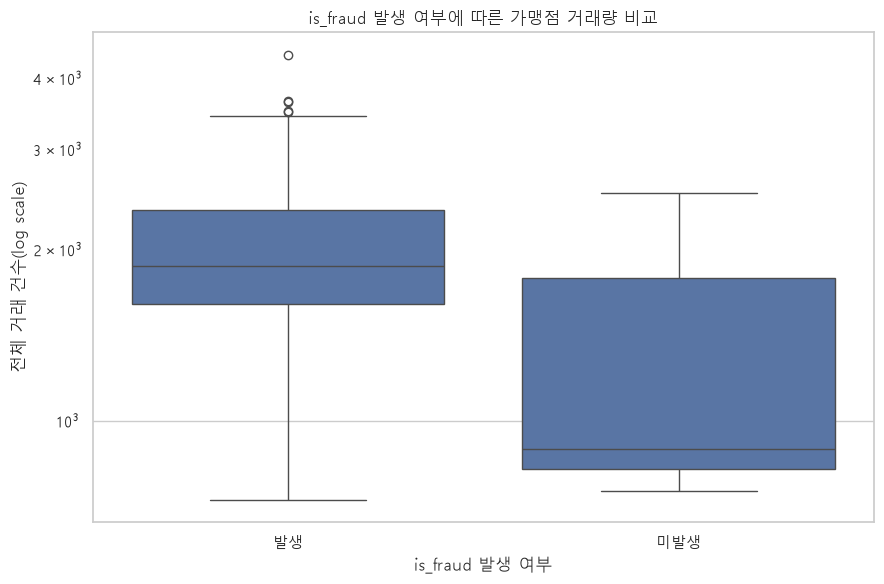

In [ ]:
## is_fraud=1 가 없었던 14개 가맹점이 단순히 거래량이 적었던 것인지 확인.
## -> 단순히 거래량이 적었던 게 맞음.

plt.figure(figsize=(9, 6))

sns.boxplot(
    data=merchant_viz,
    x="has_is_fraud",
    y="total_transactions"
)

plt.yscale("log")

plt.title("is_fraud 발생 여부에 따른 가맹점 거래량 비교")
plt.xlabel("is_fraud 발생 여부")
plt.ylabel("전체 거래 건수(log scale)")
plt.tight_layout()
plt.show()

In [35]:
# 이상거래 미발생 가맹점
no_is_fraud_merchants = merchant_summary.loc[
    merchant_summary["is_fraud_transactions"] == 0
].copy()

# 이상거래 발생 가맹점 전체
is_fraud_merchants_all = merchant_summary.loc[
    merchant_summary["is_fraud_transactions"] > 0
].copy()


# 거래 건수 요약 통계 함수
def transaction_statistics(data):
    return pd.Series({
        "가맹점 수": len(data),
        "25% 거래 건수": data["total_transactions"].quantile(0.25),
        "50% 거래 건수(중앙값)": data["total_transactions"].quantile(0.50),
        "75% 거래 건수": data["total_transactions"].quantile(0.75),
        "평균 거래 건수": data["total_transactions"].mean()
    })


# 미발생 14곳과 발생 전체 가맹점 비교
merchant_transaction_comparison = pd.DataFrame({
    "is_fraud 미발생 가맹점": transaction_statistics(
        no_is_fraud_merchants
    ),
    "is_fraud 발생 가맹점": transaction_statistics(
        is_fraud_merchants_all
    )
}).T.round(2)

display(merchant_transaction_comparison)

,가맹점 수,25% 거래 건수,50% 거래 건수(중앙값),75% 거래 건수,평균 거래 건수
is_fraud 미발생 가맹점,14.0000,822.0000,890.5000,"1,784.5000","1,239.1400"
is_fraud 발생 가맹점,679.0000,"1,607.5000","1,869.0000","2,351.5000","1,884.1300"


=> 이상거래가 발생한 가맹점은 미발생 가맹점보다 전반적으로 거래 건수가 더 많음.
중앙값: 약 2.1배
평균: 약 1.5배
따라서, 가맹점별 이상 거래 발생 여부가 가맹점 위험성뿐 아니라, '거래 노출량'의 영향을 받은 것으로 해석됨.

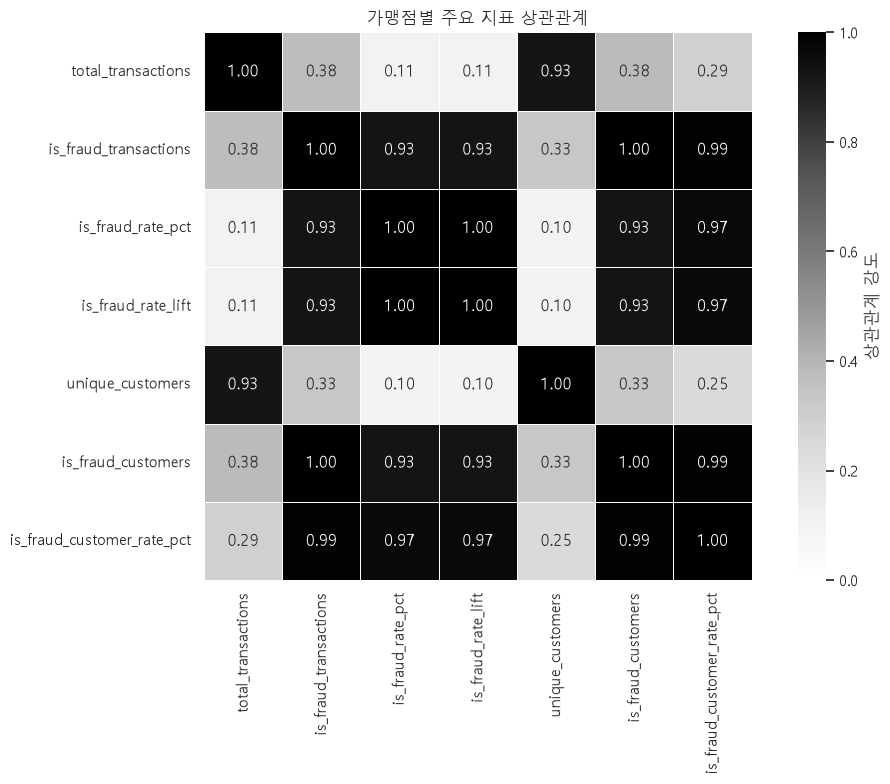

In [34]:
## 주요 지표 간 상관관계 heatmap
## -> 어떤 지표들이 서로 함께 증가하는지 확인.

correlation_columns = [
    "total_transactions",
    "is_fraud_transactions",
    "is_fraud_rate_pct",
    "is_fraud_rate_lift",
    "unique_customers",
    "is_fraud_customers",
    "is_fraud_customer_rate_pct"
]

# 상관계수 계산 후 절댓값 적용
correlation_matrix_abs = (
    merchant_viz[correlation_columns]
    .corr()
    .abs()
)

plt.figure(figsize=(11, 8))

sns.heatmap(
    correlation_matrix_abs,
    annot=True,
    fmt=".2f",
    cmap="Greys",       # 흰색 → 검은색
    vmin=0,             # 0은 흰색
    vmax=1,             # 1은 가장 어두운 색
    square=True,
    linewidths=0.5,
    linecolor="white",
    cbar_kws={"label": "상관관계 강도"}
)

plt.title("가맹점별 주요 지표 상관관계")
plt.tight_layout()
plt.show()

=> 우선, 상관계수의 절댓값을 적용했기 때문에, 방향은 제외하고 관계의 강도만 표시.

<의미 있어보이는 상관관계만 해석>
1. 전체 거래 건수와 is_fraud 거래 건수 : 0.38
거래량이 많으면 이상거래 건수가 다소 증가하지만 관계가 강하지 않음. 이상거래 건수는 단순히 거래량만으로 결정되지x
2. 전체 거래 건수와 is_fraud 비율 : 0.11
거래량과 이상거래 비율은 거의 관계없음. 거래 많은 가맹점이라고 해서 이상거래 비율이 높은 건 아님. '거래량과 위험도를 별도로 평가'.
3. 이용 고객 수와 is_fraud 비율 : 0.10
고객 많은 가맹점이라고 해서 이상거래 비율이 높은 것도 아님. 가맹점 위험도에는 거래량이나 고객수 외에 '업종, 결제금액, 시간대' 등의 요인이 영향을 줄 가능성 있음.
4. is_fraud 거래 건수와 경험 고객 수 : 1.00
is_fraud 거래가 많은 가맹점일수록, 이를 경험한 고객 수도 동일하게 증가함 => 이상거래가 특정 한두 고객에게만 반복되기보다, '여러 고객'에게 확산되는 형태일 가능성.
but, 상관관계만으로 확정할 순 없음.

In [47]:
# 고객 집중도 지표 계산
merchant_customer_concentration = merchant_summary[
    [
        "merchant",
        "is_fraud_transactions",
        "is_fraud_customers"
    ]
].copy()

merchant_customer_concentration[
    "is_fraud_transactions_per_customer"
] = (
    merchant_customer_concentration["is_fraud_transactions"]
    / merchant_customer_concentration["is_fraud_customers"].replace(0, np.nan)
).round(2)

# 고객 집중도가 높은 순으로 확인
merchant_customer_concentration = (
    merchant_customer_concentration
    .sort_values(
        "is_fraud_transactions_per_customer",
        ascending=False
    )
    .reset_index(drop=True)
)

display(merchant_customer_concentration.head(20))

,merchant,is_fraud_transactions,is_fraud_customers,is_fraud_transactions_per_customer
0,fraud_Hyatt-Blick,2,1,2.0000
1,fraud_Collier LLC,2,1,2.0000
2,fraud_Romaguera Ltd,2,1,2.0000
3,fraud_O'Hara-Wilderman,3,2,1.5000
4,fraud_Morissette-Schaefer,4,3,1.3300
5,fraud_Reilly and Sons,4,3,1.3300
6,"fraud_Hettinger, McCullough and Fay",4,3,1.3300
7,fraud_White and Sons,4,3,1.3300
8,fraud_Powlowski-Weimann,5,4,1.2500
9,fraud_Watsica LLC,6,5,1.2000


=> '이상거래 경험 고객 1명당 이상거래 건수'가 많은 가맹점 순서로 정렬함.

고객당 이상거래 건수가 가장 높은 가맹점은 2건이지만, 대부분 이상거래 고객 수가 1~3명으로 표본이 작았으며, 
*고객 수가 충분한 가맹점에서는 값이 1에 가까워 이상거래가 특정 고객에게 반복 집중되기보다 '여러 고객에게 분산된 경향'을 보임.

In [55]:
import matplotlib.pyplot as plt
import seaborn as sns

# 먼저 seaborn 테마 설정
sns.set_theme(style="whitegrid")

# 그다음 한글 폰트 설정
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

In [56]:
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib import font_manager

sns.set_theme(style="whitegrid")

font_path = r"C:\Windows\Fonts\malgun.ttf"
font_name = font_manager.FontProperties(
    fname=font_path
).get_name()

plt.rcParams["font.family"] = font_name
plt.rcParams["axes.unicode_minus"] = False

print("적용된 폰트:", font_name)

적용된 폰트: Malgun Gothic


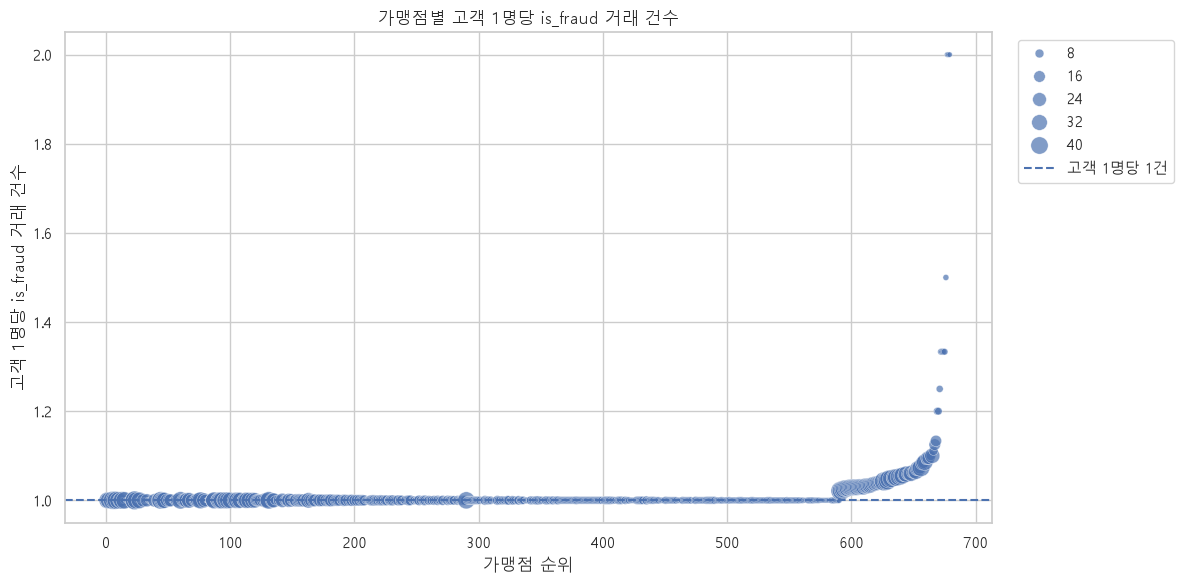

In [57]:
concentration_rank = (
    customer_concentration_viz
    .sort_values(
        "is_fraud_transactions_per_customer",
        ascending=True
    )
    .reset_index(drop=True)
)

concentration_rank["merchant_rank"] = (
    concentration_rank.index + 1
)

plt.figure(figsize=(12, 6))

sns.scatterplot(
    data=concentration_rank,
    x="merchant_rank",
    y="is_fraud_transactions_per_customer",
    size="is_fraud_customers",
    sizes=(15, 180),
    alpha=0.7
)

plt.axhline(
    1,
    linestyle="--",
    label="고객 1명당 1건"
)

plt.title("가맹점별 고객 1명당 is_fraud 거래 건수")
plt.xlabel("가맹점 순위")
plt.ylabel("고객 1명당 is_fraud 거래 건수")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

=> 대부분의 가맹점이 고객 1명당 is_fraud거래 약 1건에 몰려 있음.
이상거래는 여러 고객에게 한 번씩 분산되는 경향이 강함.

우측 끝 일부 가맹점은 1.2~2건까지 높게 나타나지만, 점 크기가 작으므로 이상거래 경험 고객 수 자체가 적음.

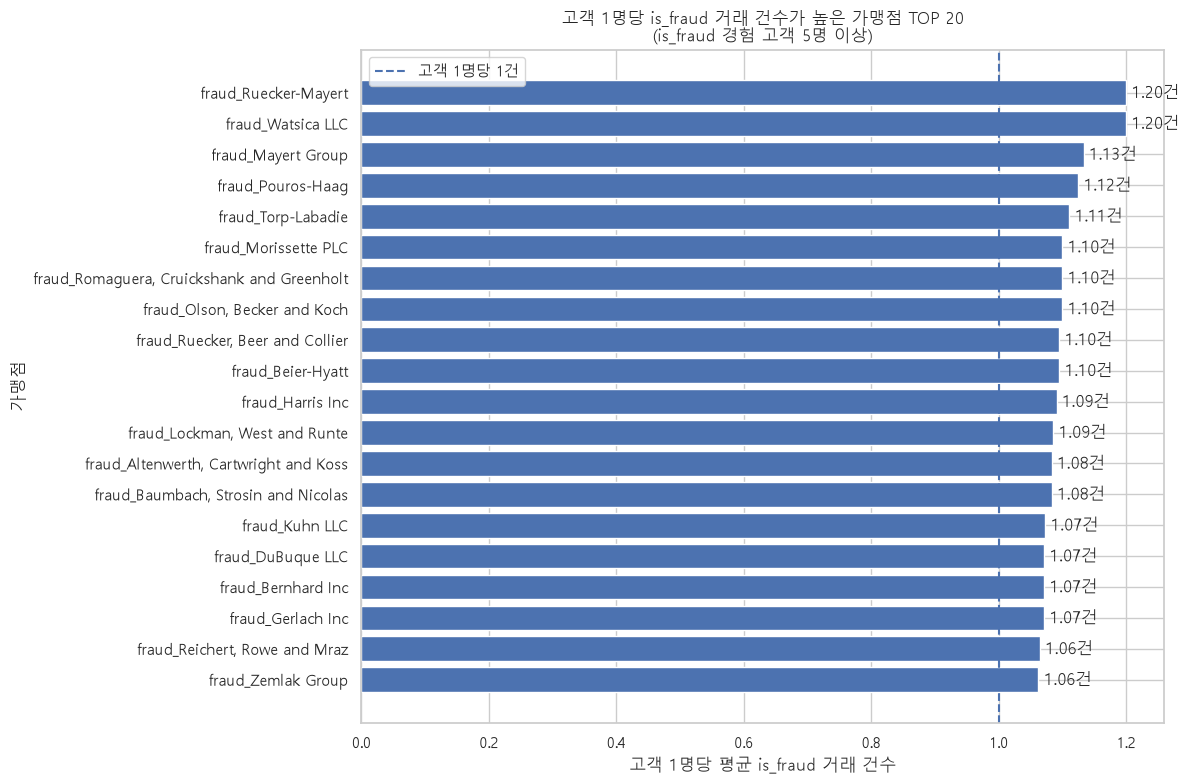

In [58]:
minimum_is_fraud_customers = 5

top_concentration_merchants = (
    customer_concentration_viz.loc[
        customer_concentration_viz["is_fraud_customers"]
        >= minimum_is_fraud_customers
    ]
    .sort_values(
        [
            "is_fraud_transactions_per_customer",
            "is_fraud_transactions"
        ],
        ascending=[False, False]
    )
    .head(20)
    .sort_values(
        "is_fraud_transactions_per_customer",
        ascending=True
    )
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_concentration_merchants["merchant"],
    top_concentration_merchants[
        "is_fraud_transactions_per_customer"
    ]
)

plt.axvline(
    1,
    linestyle="--",
    label="고객 1명당 1건"
)

plt.title(
    "고객 1명당 is_fraud 거래 건수가 높은 가맹점 TOP 20\n"
    f"(is_fraud 경험 고객 {minimum_is_fraud_customers}명 이상)"
)
plt.xlabel("고객 1명당 평균 is_fraud 거래 건수")
plt.ylabel("가맹점")
plt.legend()

for bar, value in zip(
    bars,
    top_concentration_merchants[
        "is_fraud_transactions_per_customer"
    ]
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {value:.2f}건",
        va="center"
    )

plt.tight_layout()
plt.show()

=> 경험 고객을 5명 이상으로 제한하니, '고객 1명당 이상거래 건수'의 최댓값이 1.20건으로 낮아짐. 결론은 위와같음.

In [ ]:
## 한 고객에게 발생한 최대 이상거래 건수는???? -> 시각화로 보기

import numpy as np
import pandas as pd

# 1. 가맹점-고객별 is_fraud 거래 건수
merchant_customer_is_fraud = (
    train.loc[train["is_fraud"] == 1]
    .groupby(["merchant", "cc_num"])
    .size()
    .rename("customer_is_fraud_transactions")
    .reset_index()
)

# 2. 가맹점별 최대 is_fraud 거래 건수를 가진 고객 행 추출
max_customer_index = (
    merchant_customer_is_fraud
    .groupby("merchant")["customer_is_fraud_transactions"]
    .idxmax()
)

merchant_max_customer = (
    merchant_customer_is_fraud
    .loc[max_customer_index]
    .rename(
        columns={
            "cc_num": "max_is_fraud_customer",
            "customer_is_fraud_transactions":
                "max_is_fraud_transactions_by_customer"
        }
    )
    .reset_index(drop=True)
)

# 3. 가맹점별 고객 반복 발생 관련 지표
merchant_repeat_summary = (
    merchant_customer_is_fraud
    .groupby("merchant", as_index=False)
    .agg(
        # is_fraud를 경험한 고객 수
        is_fraud_customers=("cc_num", "nunique"),

        # 전체 is_fraud 거래 건수
        is_fraud_transactions=(
            "customer_is_fraud_transactions",
            "sum"
        ),

        # is_fraud 2건 이상 발생 고객 수
        repeat_is_fraud_customers=(
            "customer_is_fraud_transactions",
            lambda x: (x >= 2).sum()
        )
    )
)

# 4. 고객 1명당 평균 is_fraud 거래 건수
merchant_repeat_summary[
    "is_fraud_transactions_per_customer"
] = (
    merchant_repeat_summary["is_fraud_transactions"]
    / merchant_repeat_summary["is_fraud_customers"]
).round(2)

# 5. 최대 발생 고객 정보 결합
merchant_repeat_summary = merchant_repeat_summary.merge(
    merchant_max_customer[
        [
            "merchant",
            "max_is_fraud_customer",
            "max_is_fraud_transactions_by_customer"
        ]
    ],
    on="merchant",
    how="left"
)

# 6. is_fraud 경험 고객 중 반복 고객 비율
merchant_repeat_summary[
    "repeat_is_fraud_customer_rate_pct"
] = (
    merchant_repeat_summary["repeat_is_fraud_customers"]
    / merchant_repeat_summary["is_fraud_customers"]
    * 100
).round(2)

# 7. 최대 건수가 높은 순으로 정렬
merchant_repeat_summary = (
    merchant_repeat_summary
    .sort_values(
        [
            "max_is_fraud_transactions_by_customer",
            "repeat_is_fraud_customers",
            "is_fraud_transactions"
        ],
        ascending=[False, False, False]
    )
    .reset_index(drop=True)
)

display(merchant_repeat_summary.head(20))

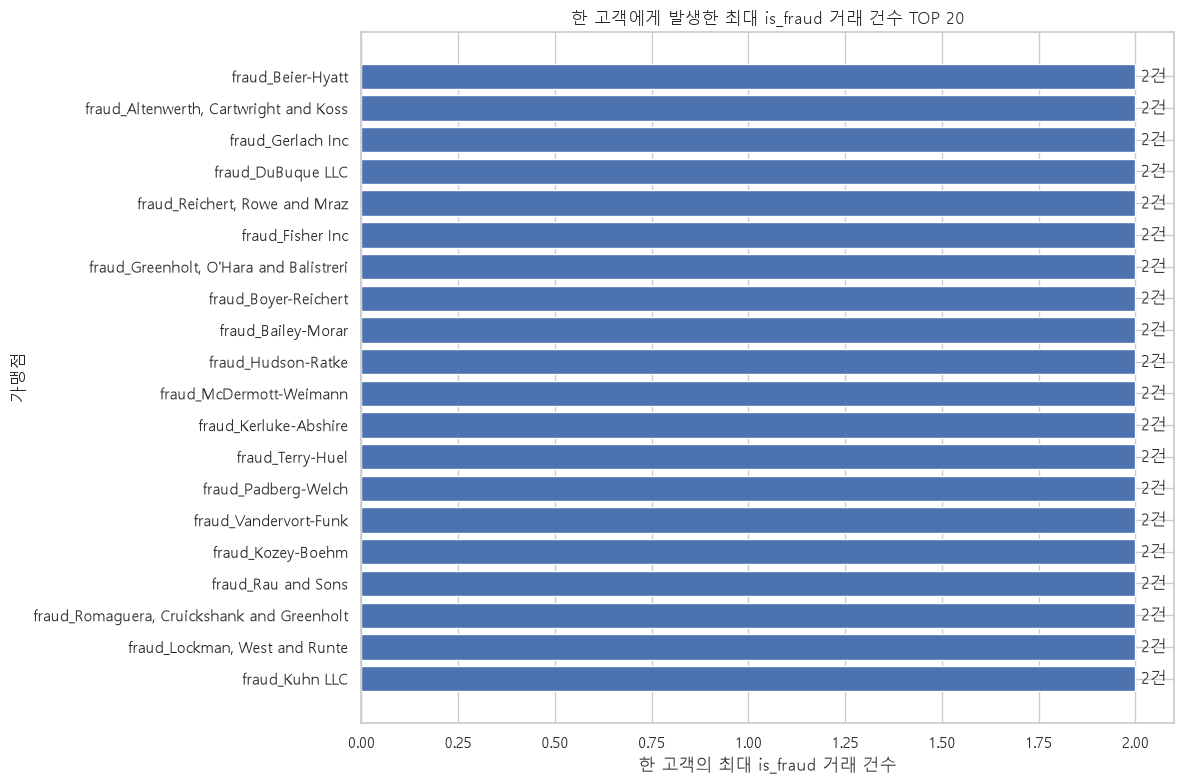

In [60]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

top_max_merchants = (
    merchant_repeat_summary
    .head(20)
    .sort_values(
        "max_is_fraud_transactions_by_customer",
        ascending=True
    )
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top_max_merchants["merchant"],
    top_max_merchants[
        "max_is_fraud_transactions_by_customer"
    ]
)

plt.title("한 고객에게 발생한 최대 is_fraud 거래 건수 TOP 20")
plt.xlabel("한 고객의 최대 is_fraud 거래 건수")
plt.ylabel("가맹점")

for bar, value in zip(
    bars,
    top_max_merchants[
        "max_is_fraud_transactions_by_customer"
    ]
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {int(value)}건",
        va="center"
    )

plt.tight_layout()
plt.show()

=> '가맹점별' 한 고객당 최대 이상거래 건수는 2건.

⇒ 한 고객이 한 가맹점에서 여러 번의 이상거래를 하진 않는구나.

-> 한 고객의 특성을 파악하기 보다, 그 집단의 특징을 전체적으로 파악해야겠구나.

,cc_num,total_transactions,is_fraud_transactions,is_fraud_rate_pct
0,4593569795412,19,19,100.0000
1,3520550088202337,989,19,1.9210
2,4260128500325,1466,18,1.2280
3,4874006077381178,516,16,3.1010
4,2227671554547514,545,16,2.9360
5,4629451965224809,1531,16,1.0450
6,3575540972310993,1542,16,1.0380
7,4400011257587661852,2030,16,0.7880
8,30074693890476,2057,16,0.7780
9,6011366578560244,2060,16,0.7770


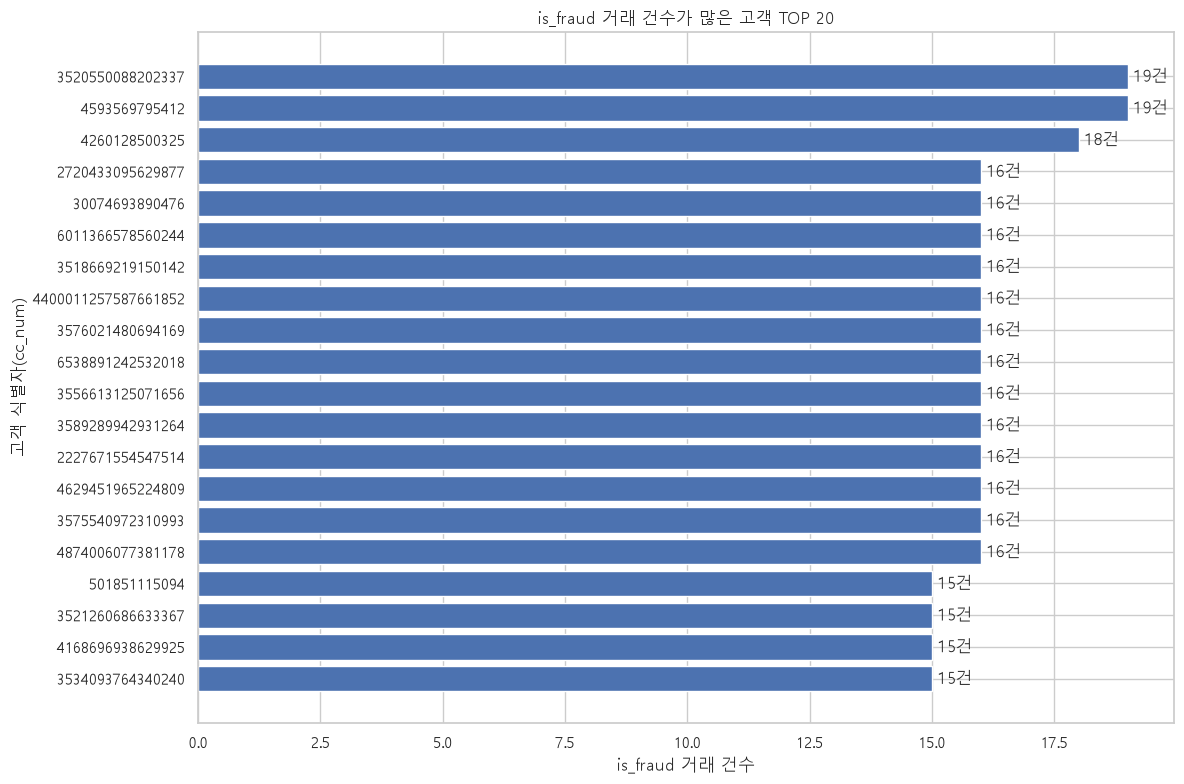

In [61]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 설정
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 1. 고객별 거래 현황 계산
customer_is_fraud_summary = (
    train.groupby("cc_num", as_index=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        is_fraud_rate=("is_fraud", "mean")
    )
)

# 백분율 파생변수
customer_is_fraud_summary["is_fraud_rate_pct"] = (
    customer_is_fraud_summary["is_fraud_rate"] * 100
).round(3)


# 2. is_fraud 거래 건수가 많은 고객 TOP 20
# 건수가 같으면 is_fraud 비율이 높은 고객을 먼저 배치
top20_customers = (
    customer_is_fraud_summary
    .sort_values(
        ["is_fraud_transactions", "is_fraud_rate"],
        ascending=[False, False]
    )
    .head(20)
    .copy()
)

# 카드번호를 그래프 표시용 문자열로 변환
top20_customers["customer_label"] = (
    top20_customers["cc_num"].astype(str)
)


# 3. 표 확인
display(
    top20_customers[
        [
            "cc_num",
            "total_transactions",
            "is_fraud_transactions",
            "is_fraud_rate_pct"
        ]
    ].reset_index(drop=True)
)


# 4. 가로 막대그래프를 위해 낮은 값부터 정렬
top20_plot = top20_customers.sort_values(
    "is_fraud_transactions",
    ascending=True
)

plt.figure(figsize=(12, 8))

bars = plt.barh(
    top20_plot["customer_label"],
    top20_plot["is_fraud_transactions"]
)

plt.title("is_fraud 거래 건수가 많은 고객 TOP 20")
plt.xlabel("is_fraud 거래 건수")
plt.ylabel("고객 식별자(cc_num)")

# 막대 끝에 거래 건수 표시
for bar, value in zip(
    bars,
    top20_plot["is_fraud_transactions"]
):
    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" {int(value)}건",
        va="center"
    )

plt.tight_layout()
plt.show()

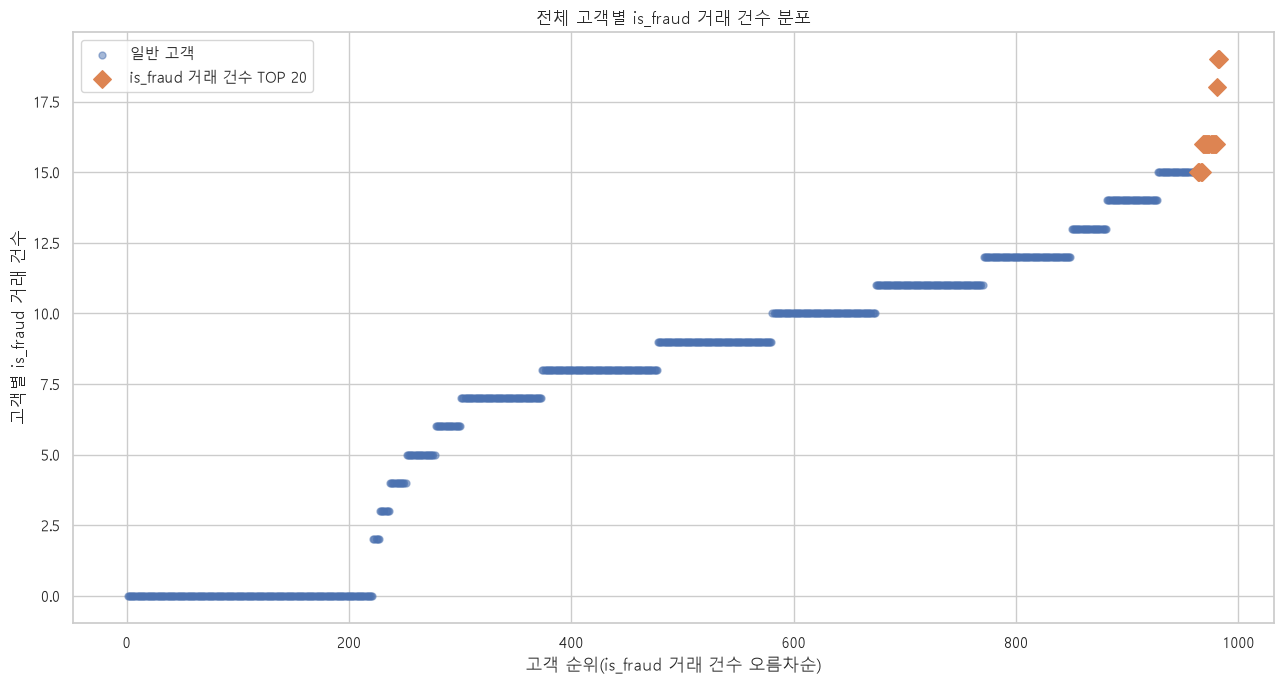

In [64]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn 설정 후 한글 폰트 적용
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 1. 고객별 거래 현황 계산
customer_is_fraud_summary = (
    train.groupby("cc_num", as_index=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        is_fraud_rate=("is_fraud", "mean")
    )
)

# 고객별 is_fraud 비율(%)
customer_is_fraud_summary["is_fraud_rate_pct"] = (
    customer_is_fraud_summary["is_fraud_rate"] * 100
).round(3)


# 2. is_fraud 거래 건수가 낮은 순으로 정렬
# x축을 실제 카드번호 대신 순위로 사용
customer_scatter = (
    customer_is_fraud_summary
    .sort_values(
        ["is_fraud_transactions", "is_fraud_rate"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

customer_scatter["customer_rank"] = (
    customer_scatter.index + 1
)


# 3. is_fraud 거래 건수 상위 20명 표시
top20_index = (
    customer_is_fraud_summary
    .nlargest(
        20,
        ["is_fraud_transactions", "is_fraud_rate"]
    )
    .index
)

customer_is_fraud_summary["is_top20"] = (
    customer_is_fraud_summary.index.isin(top20_index)
)

# 정렬 데이터에 TOP 20 여부 결합
customer_scatter = customer_scatter.merge(
    customer_is_fraud_summary[
        ["cc_num", "is_top20"]
    ],
    on="cc_num",
    how="left"
)


# 4. 전체 고객 산점도
plt.figure(figsize=(13, 7))

# 일반 고객
normal_customers = customer_scatter.loc[
    ~customer_scatter["is_top20"]
]

plt.scatter(
    normal_customers["customer_rank"],
    normal_customers["is_fraud_transactions"],
    s=25,
    alpha=0.5,
    label="일반 고객"
)

# 상위 20명
top20_customers = customer_scatter.loc[
    customer_scatter["is_top20"]
]

plt.scatter(
    top20_customers["customer_rank"],
    top20_customers["is_fraud_transactions"],
    s=80,
    marker="D",
    label="is_fraud 거래 건수 TOP 20"
)

plt.title("전체 고객별 is_fraud 거래 건수 분포")
plt.xlabel("고객 순위(is_fraud 거래 건수 오름차순)")
plt.ylabel("고객별 is_fraud 거래 건수")
plt.legend()
plt.tight_layout()
plt.show()

=> 순서대로 정렬했다보니 당연히, 19건에서부터 0건까지 순서대로 그려짐.(오름차순 주의)

but, 이상거래 '건수' 말고도, 이상거래'율' 확인 필요.

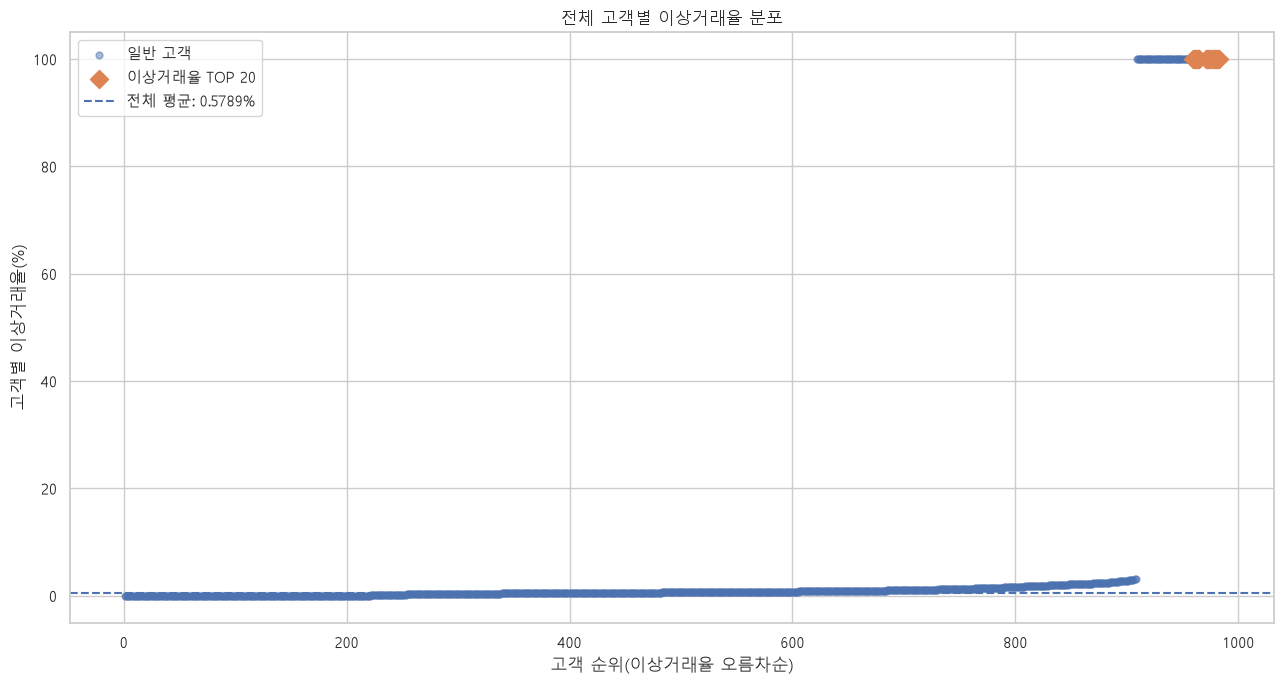

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# seaborn 설정 후 한글 폰트 적용
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 1. 고객별 거래 현황 계산
customer_rate_summary = (
    train.groupby("cc_num", as_index=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        is_fraud_rate=("is_fraud", "mean")
    )
)

# 고객별 이상거래율을 백분율로 변환
customer_rate_summary["is_fraud_rate_pct"] = (
    customer_rate_summary["is_fraud_rate"] * 100
)


# 2. 이상거래율이 낮은 순으로 고객 정렬
customer_rate_scatter = (
    customer_rate_summary
    .sort_values(
        ["is_fraud_rate_pct", "is_fraud_transactions"],
        ascending=[True, True]
    )
    .reset_index(drop=True)
)

# x축에 사용할 고객 순위
customer_rate_scatter["customer_rank"] = (
    customer_rate_scatter.index + 1
)


# 3. 이상거래율 상위 20명 표시
top20_customer_ids = (
    customer_rate_summary
    .sort_values(
        ["is_fraud_rate_pct", "is_fraud_transactions"],
        ascending=[False, False]
    )
    .head(20)["cc_num"]
)

customer_rate_scatter["is_top20"] = (
    customer_rate_scatter["cc_num"].isin(top20_customer_ids)
)


# 4. 일반 고객과 상위 20명 분리
normal_customers = customer_rate_scatter.loc[
    ~customer_rate_scatter["is_top20"]
]

top20_customers = customer_rate_scatter.loc[
    customer_rate_scatter["is_top20"]
]


# 5. 전체 고객 이상거래율 산점도
plt.figure(figsize=(13, 7))

# 일반 고객
plt.scatter(
    normal_customers["customer_rank"],
    normal_customers["is_fraud_rate_pct"],
    s=25,
    alpha=0.5,
    label="일반 고객"
)

# 이상거래율 상위 20명
plt.scatter(
    top20_customers["customer_rank"],
    top20_customers["is_fraud_rate_pct"],
    s=85,
    marker="D",
    label="이상거래율 TOP 20"
)

# 전체 평균 이상거래율
overall_is_fraud_rate_pct = train["is_fraud"].mean() * 100

plt.axhline(
    overall_is_fraud_rate_pct,
    linestyle="--",
    linewidth=1.5,
    label=f"전체 평균: {overall_is_fraud_rate_pct:.4f}%"
)

plt.title("전체 고객별 이상거래율 분포")
plt.xlabel("고객 순위(이상거래율 오름차순)")
plt.ylabel("고객별 이상거래율(%)")
plt.legend()
plt.tight_layout()
plt.show()

=> 고객 983명을 고객별 이상거래율이 낮은 순서대로 정렬한 것.
대부분의 고객은 이상거래율 0%, 오른쪽 끝 일부 고객은 100%로 나타나면서 나머지값들이 아래쪽에 눌려 보임.

-> 이상거래율 100% 고객: 그 고객의 거래가 전부 이상거래. but, 전체 거래 건수를 같이 확인해야 함. 전체 거래 1건, 이상거래 1건인지 / 전체 거래 19건, 이상거래 19건인지


In [67]:
import numpy as np

# 이상거래율이 100%인 고객
hundred_pct_customers = customer_rate_summary.loc[
    np.isclose(customer_rate_summary["is_fraud_rate_pct"], 100)
].copy()

# 고객 수 및 전체 고객 대비 비율
hundred_pct_customer_count = len(hundred_pct_customers)
total_customer_count = customer_rate_summary["cc_num"].nunique()

hundred_pct_customer_share = (
    hundred_pct_customer_count
    / total_customer_count
    * 100
)

print(f"전체 고객 수: {total_customer_count:,}명")
print(f"이상거래율 100% 고객 수: {hundred_pct_customer_count:,}명")
print(f"전체 고객 대비 비율: {hundred_pct_customer_share:.2f}%")

전체 고객 수: 983명
이상거래율 100% 고객 수: 75명
전체 고객 대비 비율: 7.63%


=> 전체 고객의 7.63% 인 75명이 only 사기거래만 하고 있구나!!!

In [66]:
hundred_pct_customers = (
    customer_rate_summary.loc[
        customer_rate_summary["is_fraud_rate_pct"] == 100,
        [
            "cc_num",
            "total_transactions",
            "is_fraud_transactions",
            "is_fraud_rate_pct"
        ]
    ]
    .sort_values(
        ["total_transactions", "is_fraud_transactions"],
        ascending=False
    )
    .reset_index(drop=True)
)

display(hundred_pct_customers)

,cc_num,total_transactions,is_fraud_transactions,is_fraud_rate_pct
0,4593569795412,19,19,100.0000
1,501851115094,15,15,100.0000
2,3521260686633367,15,15,100.0000
3,4168696938629925,15,15,100.0000
4,3562793934111141,13,13,100.0000
...,...,...,...,...
70,4225628813173670,7,7,100.0000
71,4734310647841293,7,7,100.0000
72,6011732631674654,7,7,100.0000
73,6577777028615915,7,7,100.0000


=> 그 75명의 전체 거래 수(이상 거래 수)를 확인함.
75개의 데이터 모두가 유의미해보임. 
-> 혹시 아까 7개의 집단 중 하나이려나?
-> 이 사람들은 어떤 특징을 가지고 있는지 무조건 분석 필요!!

# !!! 민정 3차 EDA !!!

## 22~04시라는 공통 위험 시간대를 고려한 뒤에도, 개인의 평소 거래시간 이탈이 추가 위험을 설명하는가? <⇒ 정상적인 소비패턴을 기준으로 이상거래가 이탈했는지 확인.

# 주 활동 시간대 80% 의 의미

고객의 정상 거래를 시간대별로 나눈 뒤, 그 고객의 정상 거래 중 누적 80% 가 발생한 시간들을 '주 활동 시간대'로 정의.

고객이 자주 거래한 시간부터 모아서 전체 거래의 '80%'를 설명하는 시간대를 찾음.

# Lift 의미
( 특정 집단의 이상거래율 / 전체 이상거래율 )
=> 특정 집단의 이상거래율이 전체 평균 이상거래율보다 몇 배 높은지 나타내는 값.

### 1단계: 고객별 거래 건수 분포 확인

In [ ]:
# 데이터 불러오기
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 그래프 설정
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 현재 작업 위치에 따라 fraudTrain.csv 경로 탐색
candidate_paths = [
    Path("data/raw/fraudTrain.csv"),
    Path("../data/raw/fraudTrain.csv"),
    Path("../../data/raw/fraudTrain.csv"),
    Path(
        r"C:\Users\splen\OneDrive\Desktop\BDAI\BOOSTMAP"
        r"\Fraud-FDS-Project\data\raw\fraudTrain.csv"
    )
]

train_path = next(
    (path for path in candidate_paths if path.exists()),
    None
)

if train_path is None:
    print("현재 작업 폴더:", Path.cwd())
    raise FileNotFoundError(
        "fraudTrain.csv 파일을 찾지 못했습니다. "
        "파일 경로를 확인해 주세요."
    )

# 원본 학습 데이터 불러오기
train = pd.read_csv(train_path)

print("불러온 파일:", train_path.resolve())
print(f"데이터 크기: {train.shape[0]:,}행 × {train.shape[1]}열")
print(f"고객 수: {train['cc_num'].nunique():,}명")

display(train.head())

In [6]:
# 고객별 전체 거래 건수 계산
customer_tx_count = (
    train.groupby("cc_num")
    .size()
    .rename("total_transactions")
    .reset_index()
)

print(f"전체 고객 수: {len(customer_tx_count):,}명")

display(
    customer_tx_count["total_transactions"]
    .describe(
        percentiles=[
            0.01, 0.05, 0.10,
            0.25, 0.50, 0.75,
            0.90, 0.95, 0.99
        ]
    )
    .to_frame("고객별 거래 건수")
)

전체 고객 수: 983명


,고객별 거래 건수
count,983.000000
mean,1319.099695
std,812.235900
min,7.000000
1%,7.820000
5%,10.100000
10%,497.200000
25%,525.000000
50%,1054.000000
75%,2025.000000


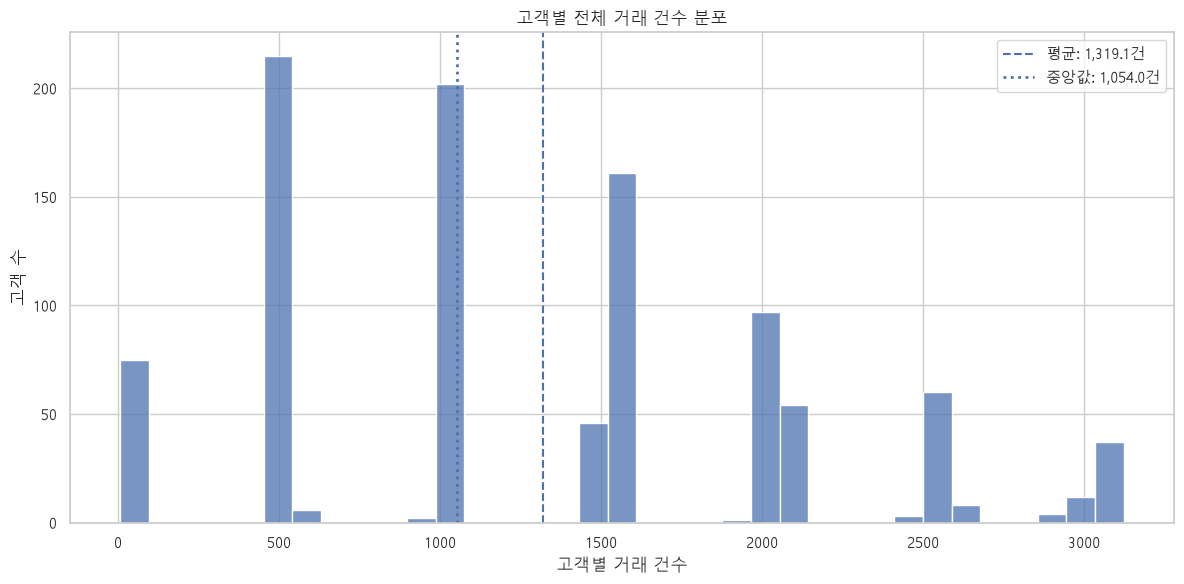

In [7]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=customer_tx_count,
    x="total_transactions",
    bins=35
)

mean_tx = customer_tx_count["total_transactions"].mean()
median_tx = customer_tx_count["total_transactions"].median()

plt.axvline(
    mean_tx,
    linestyle="--",
    linewidth=1.5,
    label=f"평균: {mean_tx:,.1f}건"
)

plt.axvline(
    median_tx,
    linestyle=":",
    linewidth=2,
    label=f"중앙값: {median_tx:,.1f}건"
)

plt.title("고객별 전체 거래 건수 분포")
plt.xlabel("고객별 거래 건수")
plt.ylabel("고객 수")
plt.legend()
plt.tight_layout()
plt.show()

In [10]:
threshold_check = []

for threshold in [20, 50, 100, 200, 300, 500, 1000]:
    below_count = (
        customer_tx_count["total_transactions"] < threshold
    ).sum()

    threshold_check.append({
        "기준 거래 건수": threshold,
        "기준 미만 고객 수": below_count,
        "기준 미만 고객 비율(%)": (
            below_count / len(customer_tx_count) * 100
        )
    })

threshold_check = pd.DataFrame(threshold_check)
threshold_check["기준 미만 고객 비율(%)"] = (
    threshold_check["기준 미만 고객 비율(%)"].round(2)
)

display(threshold_check)

,기준 거래 건수,기준 미만 고객 수,기준 미만 고객 비율(%)
0,20,75,7.63
1,50,75,7.63
2,100,75,7.63
3,200,75,7.63
4,300,75,7.63
5,500,103,10.48
6,1000,307,31.23


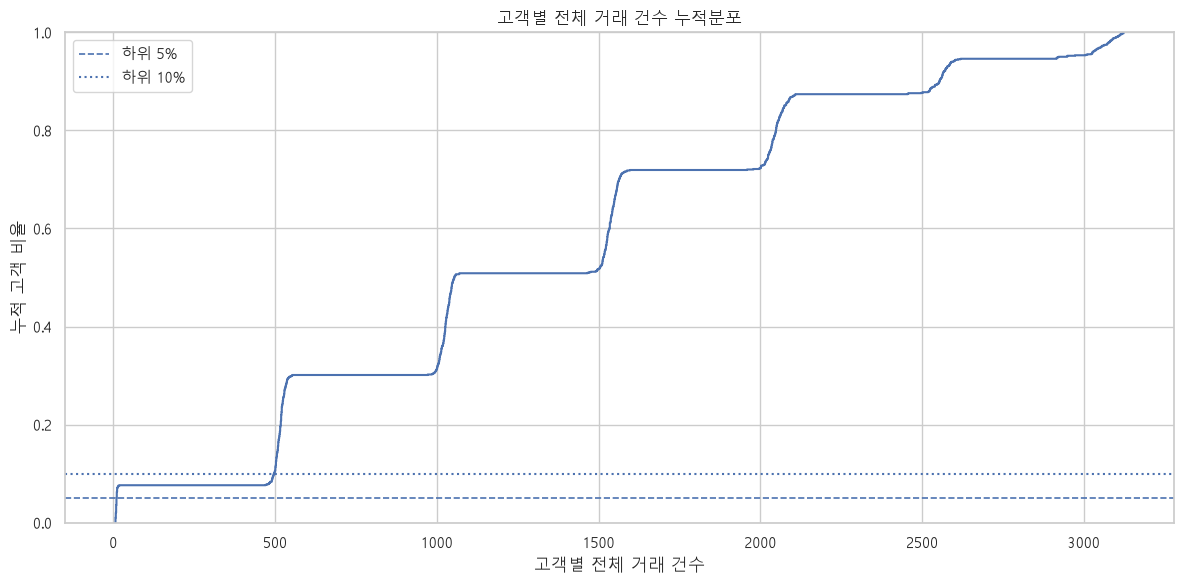

In [11]:
plt.figure(figsize=(12, 6))

sns.ecdfplot(
    data=customer_tx_count,
    x="total_transactions"
)

plt.axhline(
    0.05,
    linestyle="--",
    linewidth=1.2,
    label="하위 5%"
)

plt.axhline(
    0.10,
    linestyle=":",
    linewidth=1.5,
    label="하위 10%"
)

plt.title("고객별 전체 거래 건수 누적분포")
plt.xlabel("고객별 전체 거래 건수")
plt.ylabel("누적 고객 비율")
plt.legend()
plt.tight_layout()
plt.show()

=> '최소 거래 건수' 기준을 20건으로 지정 => 전체 고객 983명 중 75명(7.6%)만 제외.
why 20건? -> 나머지 고객들은 거래 건수가 모두 300건 이상.
20건 이하 거래 건수로는 고객의 시간대 패턴을 계산하기에 충분하지 않음.

### 2단계: 고객별 주 활동 시간대 80% 계산

In [14]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 분석용 데이터 복사
# 원본 train은 변경하지 않음
time_analysis = train_eligible_20.copy()


# 거래 시각 열 생성
# trans_hour가 이미 있으면 새로 만들지 않음
if "trans_hour" not in time_analysis.columns:
    time_analysis["trans_hour"] = pd.to_datetime(
        time_analysis["trans_date_trans_time"],
        errors="coerce"
    ).dt.hour


# 시간 변환이 실패한 거래 확인
print(
    "시간 변환 실패 거래 수:",
    time_analysis["trans_hour"].isna().sum()
)

시간 변환 실패 거래 수: 0


고객별 정상 거래의 시간대별 비율 계산

In [18]:
# 정상 거래만 사용하여 고객별 시간대 패턴 계산
normal_hour_profile = (
    time_analysis.loc[time_analysis["is_fraud"] == 0]
    .groupby(["cc_num", "trans_hour"])
    .size()
    .rename("normal_hour_transactions")
    .reset_index()
)


# 고객별 전체 정상 거래 건수
normal_hour_profile["total_normal_transactions"] = (
    normal_hour_profile
    .groupby("cc_num")["normal_hour_transactions"]
    .transform("sum")
)


# 각 시간대가 고객의 정상 거래에서 차지하는 비율
normal_hour_profile["hour_share"] = (
    normal_hour_profile["normal_hour_transactions"]
    / normal_hour_profile["total_normal_transactions"]
)


# 고객별로 거래가 많은 시간부터 정렬
normal_hour_profile = (
    normal_hour_profile
    .sort_values(
        ["cc_num", "normal_hour_transactions", "trans_hour"],
        ascending=[True, False, True]
    )
    .reset_index(drop=True)
)


# 누적 비율 계산
normal_hour_profile["cumulative_hour_share"] = (
    normal_hour_profile
    .groupby("cc_num")["hour_share"]
    .cumsum()
)


# 현재 시간대를 더하기 전 누적 비율
normal_hour_profile["cumulative_share_before"] = (
    normal_hour_profile["cumulative_hour_share"]
    - normal_hour_profile["hour_share"]
)


# 누적 정상 거래의 80%를 구성하는 시간대
normal_hour_profile["is_active_hour_80"] = (
    normal_hour_profile["cumulative_share_before"] < 0.80
).astype(int)


display(normal_hour_profile.head(10))

,cc_num,trans_hour,normal_hour_transactions,total_normal_transactions,hour_share,cumulative_hour_share,cumulative_share_before,is_active_hour_80
0,60416207185,13,107,1509,0.070908,0.070908,0.000000,1
1,60416207185,12,105,1509,0.069583,0.140490,0.070908,1
2,60416207185,19,98,1509,0.064944,0.205434,0.140490,1
3,60416207185,17,95,1509,0.062956,0.268390,0.205434,1
4,60416207185,21,94,1509,0.062293,0.330683,0.268390,1
5,60416207185,18,83,1509,0.055003,0.385686,0.330683,1
6,60416207185,15,82,1509,0.054341,0.440027,0.385686,1
7,60416207185,14,79,1509,0.052353,0.492379,0.440027,1
8,60416207185,16,78,1509,0.051690,0.544069,0.492379,1
9,60416207185,23,78,1509,0.051690,0.595759,0.544069,1


In [ ]:
print(normal_hour_profile.shape)
## 908명이 총 21792건의 정상거래를 함.
## head(10)의 cc_num이 같은 이유: cc_num오름차순-> 같은 고객 안에서 거래 건수 내림차순-> 거래건수 같으면 시간 오름차순

(21792, 8)


[변수설명]
- trans_hour : 거래가 발생한 시각. 00~01시 거래발생 => 1, 22~23시 거래발생 => 22
- normal_hour_transactions : 해당 고객이 해당 시간대에 한 정상 거래 건수
- total_normal_transactions : 해당 고객의 전체 정상 거래 건수(같은 고객은 모든 행이 같음)
- hour_share : 해당 시간대의 정상 거래가 고객 전체 정상 거래에서 차지하는 비율
- cumulative_hour_share : 거래가 많은 시간부터 비율을 누적한 값(80%까지 주 활동 시간대)
- cumulative_share_before : 현재 시간대를 포함하기 전까지의 누적 비율(80%를 처음 넘어서는 시간도 포함시킴)
- is_active_hour_80 : 해당 시간이 고객의 주 활동 시간대에 포함되는지를 나타냄(1: 주 활동 시간대 80%에 포함됨, 0: 포함안됨)

전체 거래에 활동시간 안팎 표시

In [24]:
# 원본 train은 변경하지 않고 분석용 데이터를 다시 생성
time_analysis = train_eligible_20.copy()


# 거래 시각에서 시간대(0~23시) 추출
if "trans_hour" not in time_analysis.columns:
    time_analysis["trans_hour"] = pd.to_datetime(
        time_analysis["trans_date_trans_time"],
        errors="coerce"
    ).dt.hour


# 고객별 주 활동 시간대만 추출
active_hour_80 = (
    normal_hour_profile.loc[
        normal_hour_profile["is_active_hour_80"] == 1,
        ["cc_num", "trans_hour", "is_active_hour_80"]
    ]
    .drop_duplicates(
        subset=["cc_num", "trans_hour"]
    )
    .copy()
)


# 전체 거래에 고객별 주 활동 시간대 여부 연결
time_analysis = time_analysis.merge(
    active_hour_80,
    on=["cc_num", "trans_hour"],
    how="left",
    validate="many_to_one"
)


# 주 활동 시간대 목록에 없으면 0
time_analysis["is_active_hour_80"] = (
    time_analysis["is_active_hour_80"]
    .fillna(0)
    .astype(int)
)


# 활동시간 밖 여부 생성
time_analysis["outside_active_hours_80"] = (
    1 - time_analysis["is_active_hour_80"]
)


# 결과 확인
display(
    time_analysis[
        [
            "cc_num",
            "trans_hour",
            "is_fraud",
            "is_active_hour_80",
            "outside_active_hours_80"
        ]
    ].head(10)
)

,cc_num,trans_hour,is_fraud,is_active_hour_80,outside_active_hours_80
0,2703186189652095,0,0,0,1
1,630423337322,0,0,1,0
2,38859492057661,0,0,1,0
3,3534093764340240,0,0,1,0
4,375534208663984,0,0,1,0
5,4767265376804500,0,0,0,1
6,30074693890476,0,0,0,1
7,6011360759745864,0,0,1,0
8,4922710831011201,0,0,1,0
9,2720830304681674,0,0,0,1


[변수설명]
is_active_hour_80 : 해당 거래 시간이 그 고객의 주 활동 시간대인가? 맞으면 1
outside_active_hours_80 : 주 활동 시간대 밖인지 나타내는 변수(is_active_hour_80과 반대 관계)
-> 사실 두 변수는 정반대 개념이므로 변수 하나(outside~)만 써도 됨.

In [26]:
display(
    pd.crosstab(
        time_analysis["is_active_hour_80"],
        time_analysis["outside_active_hours_80"],
        margins=True
    )
)

outside_active_hours_80,0,1,All
is_active_hour_80,,,
0,0,238387,238387
1,1057547,0,1057547
All,1057547,238387,1295934


전체 분석 대상 거래 건수(=908명의 거래건수)는 1,295,934건.

활동시간 안: 약 81.61%
활동시간 밖: 약 18.39% -> 전체 거래 중 개인의 평소 시간대를 벗어난 거래 비율은 약 18%이다.

In [ ]:
# 주 활동 시간대 70%/80%/90% 비교 코드

import numpy as np
import pandas as pd

thresholds = [0.70, 0.80, 0.90]
comparison_results = []

# 분석 대상 전체 거래
time_base = train_eligible_20.copy()

if "trans_hour" not in time_base.columns:
    time_base["trans_hour"] = pd.to_datetime(
        time_base["trans_date_trans_time"],
        errors="coerce"
    ).dt.hour


for threshold in thresholds:

    # 해당 누적 기준에 포함되는 고객별 활동시간
    active_hour_keys = (
        normal_hour_profile.loc[
            normal_hour_profile["cumulative_share_before"] < threshold,
            ["cc_num", "trans_hour"]
        ]
        .drop_duplicates()
        .copy()
    )

    active_hour_keys["outside_active_hours"] = 0

    # 거래별 활동시간 안팎 표시
    temp = time_base.merge(
        active_hour_keys,
        on=["cc_num", "trans_hour"],
        how="left",
        validate="many_to_one"
    )

    temp["outside_active_hours"] = (
        temp["outside_active_hours"]
        .fillna(1)
        .astype(int)
    )

    # 활동시간 안팎별 거래 수와 이상거래율
    group_summary = (
        temp.groupby("outside_active_hours")["is_fraud"]
        .agg(["sum", "count", "mean"])
    )

    inside_rate = group_summary.loc[0, "mean"]
    outside_rate = group_summary.loc[1, "mean"]

    outside_count = group_summary.loc[1, "count"]
    outside_fraud_count = group_summary.loc[1, "sum"]

    total_count = len(temp)
    total_fraud_count = temp["is_fraud"].sum()

    comparison_results.append({
        "active_time_threshold": int(threshold * 100),

        "outside_transactions": outside_count,

        "outside_transaction_share_pct": (
            outside_count / total_count * 100
        ),

        "inside_fraud_rate_pct": (
            inside_rate * 100
        ),

        "outside_fraud_rate_pct": (
            outside_rate * 100
        ),

        "outside_vs_inside_risk_ratio": (
            outside_rate / inside_rate
            if inside_rate > 0 else np.nan
        ),

        "fraud_capture_outside_pct": (
            outside_fraud_count / total_fraud_count * 100
            if total_fraud_count > 0 else np.nan
        )
    })


threshold_comparison = pd.DataFrame(comparison_results)

numeric_columns = [
    "outside_transaction_share_pct",
    "inside_fraud_rate_pct",
    "outside_fraud_rate_pct",
    "outside_vs_inside_risk_ratio",
    "fraud_capture_outside_pct"
]

threshold_comparison[numeric_columns] = (
    threshold_comparison[numeric_columns].round(4)
)

display(threshold_comparison)

,active_time_threshold,outside_transactions,outside_transaction_share_pct,inside_fraud_rate_pct,outside_fraud_rate_pct,outside_vs_inside_risk_ratio,fraud_capture_outside_pct
0,70,365621,28.2129,0.4067,0.8153,2.0045,44.0650
1,80,238387,18.3950,0.4334,0.9153,2.1121,32.2542
2,90,110731,8.5445,0.4815,0.9555,1.9843,15.6393


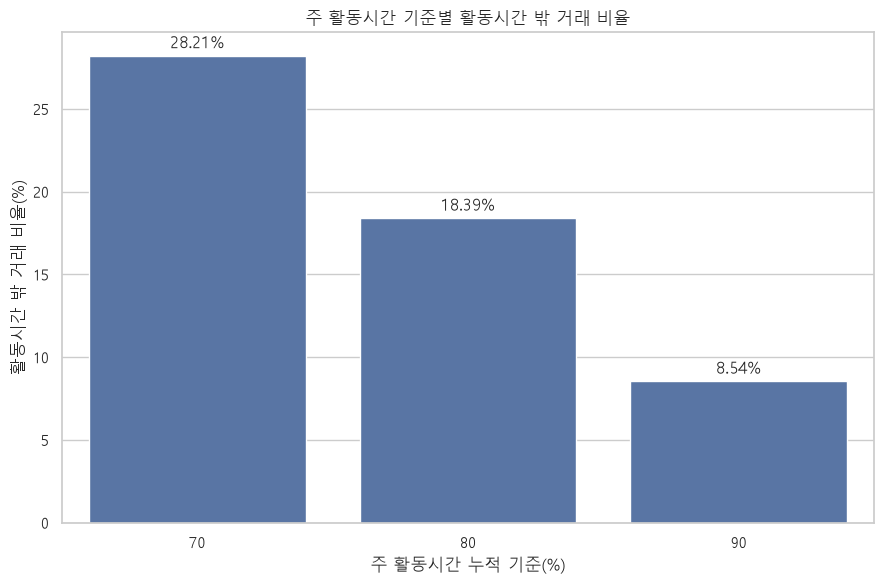

In [28]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=threshold_comparison,
    x="active_time_threshold",
    y="outside_transaction_share_pct"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.title("주 활동시간 기준별 활동시간 밖 거래 비율")
plt.xlabel("주 활동시간 누적 기준(%)")
plt.ylabel("활동시간 밖 거래 비율(%)")
plt.tight_layout()
plt.show()

이 시각화는 딱히 의미 없음. 당연한 결과.

70% -> 약 30%

80% -> 약 20%

90% -> 약 10%

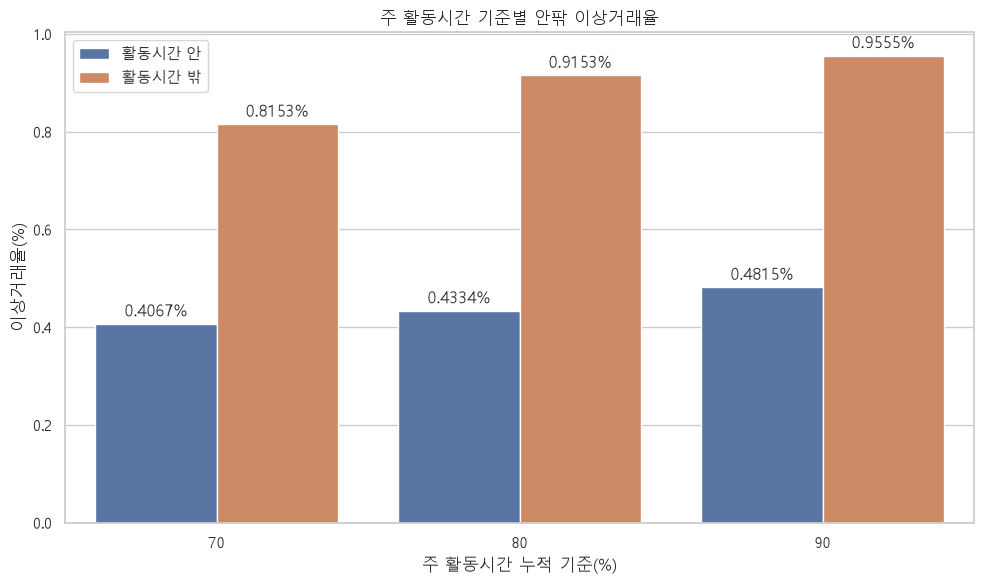

In [30]:
fraud_rate_plot = threshold_comparison.melt(
    id_vars="active_time_threshold",
    value_vars=[
        "inside_fraud_rate_pct",
        "outside_fraud_rate_pct"
    ],
    var_name="time_group",
    value_name="fraud_rate_pct"
)

fraud_rate_plot["time_group"] = (
    fraud_rate_plot["time_group"]
    .replace({
        "inside_fraud_rate_pct": "활동시간 안",
        "outside_fraud_rate_pct": "활동시간 밖"
    })
)

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=fraud_rate_plot,
    x="active_time_threshold",
    y="fraud_rate_pct",
    hue="time_group"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f%%",
        padding=3
    )

plt.title("주 활동시간 기준별 안팎 이상거래율")
plt.xlabel("주 활동시간 누적 기준(%)")
plt.ylabel("이상거래율(%)")
plt.legend(title="")
plt.tight_layout()
plt.show()

모든 기준에서 활동시간 밖의 이상거래율이 약 2배 높음.

(70% 약 2.00배, 80% 약 2.11배, 90% 약 1.98배)

활동시간 밖과 안의 '이상거래율 차이'를 계산하면,

- 70%: 0.4086%

- 80%: 0.4819% => 활동시간 안팎을 가장 뚜렷하게 구분하는 기준, 결정.

- 90%: 0.4740%



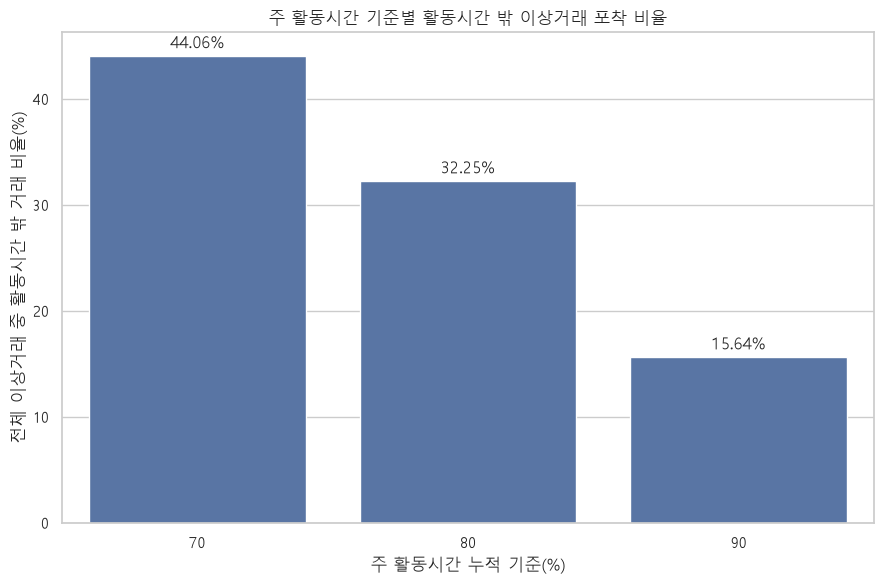

In [31]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=threshold_comparison,
    x="active_time_threshold",
    y="fraud_capture_outside_pct"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f%%",
        padding=3
    )

plt.title("주 활동시간 기준별 활동시간 밖 이상거래 포착 비율")
plt.xlabel("주 활동시간 누적 기준(%)")
plt.ylabel("전체 이상거래 중 활동시간 밖 거래 비율(%)")
plt.tight_layout()
plt.show()

90%는 전체 이상거래 중 15.64%만 활동시간 밖으로 잡음. 나머지 84%는 활동시간 안에 포함되는 셈. 즉, 90% 기준은 너무 넓어서 많은 이상거래까지 평소 활동시간 안으로 분류해버림.

70%는 전체 이상거래의 44.06%를 포착해 80%보다 많이 잡지만, 활동시간 밖으로 분류되는 정상 거래도 더 많아질 가능성이 큼. 따라서 실제 경보량이 많아질 수 있음.

-> 80%가 균형이 가장 좋은 기준임을 재확인.

### 3단계: 활동시간 안팎 이상거래율과 Lift 비교

In [32]:
import numpy as np
import pandas as pd

# 필요한 컬럼이 있는지 확인
required_columns = {
    "is_fraud",
    "outside_active_hours_80"
}

missing_columns = required_columns - set(time_analysis.columns)

if missing_columns:
    raise KeyError(
        f"다음 컬럼이 없습니다: {missing_columns}"
    )


# 현재 분석 대상 데이터의 전체 이상거래율
overall_is_fraud_rate = time_analysis["is_fraud"].mean()


# 활동시간 안팎별 요약
time_risk_summary = (
    time_analysis
    .groupby("outside_active_hours_80", as_index=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        is_fraud_rate=("is_fraud", "mean")
    )
)


# 정상 거래 건수
time_risk_summary["normal_transactions"] = (
    time_risk_summary["total_transactions"]
    - time_risk_summary["is_fraud_transactions"]
)


# 보기 쉬운 집단명
time_risk_summary["time_group"] = (
    time_risk_summary["outside_active_hours_80"]
    .map({
        0: "활동시간 안",
        1: "활동시간 밖"
    })
)


# 거래 비중
time_risk_summary["transaction_share_pct"] = (
    time_risk_summary["total_transactions"]
    / time_risk_summary["total_transactions"].sum()
    * 100
)


# 이상거래율을 백분율로 변환
time_risk_summary["is_fraud_rate_pct"] = (
    time_risk_summary["is_fraud_rate"] * 100
)


# 전체 이상거래율 대비 Lift
time_risk_summary["is_fraud_rate_lift"] = (
    time_risk_summary["is_fraud_rate"]
    / overall_is_fraud_rate
)


# 소수점 정리
time_risk_summary[
    [
        "transaction_share_pct",
        "is_fraud_rate_pct",
        "is_fraud_rate_lift"
    ]
] = time_risk_summary[
    [
        "transaction_share_pct",
        "is_fraud_rate_pct",
        "is_fraud_rate_lift"
    ]
].round(4)


display(
    time_risk_summary[
        [
            "time_group",
            "total_transactions",
            "normal_transactions",
            "is_fraud_transactions",
            "transaction_share_pct",
            "is_fraud_rate_pct",
            "is_fraud_rate_lift"
        ]
    ]
)

,time_group,total_transactions,normal_transactions,is_fraud_transactions,transaction_share_pct,is_fraud_rate_pct,is_fraud_rate_lift
0,활동시간 안,1057547,1052964,4583,81.605,0.4334,0.8302
1,활동시간 밖,238387,236205,2182,18.395,0.9153,1.7534


In [33]:
inside_rate = time_risk_summary.loc[
    time_risk_summary["outside_active_hours_80"] == 0,
    "is_fraud_rate"
].iloc[0]

outside_rate = time_risk_summary.loc[
    time_risk_summary["outside_active_hours_80"] == 1,
    "is_fraud_rate"
].iloc[0]


# 활동시간 밖 / 활동시간 안 위험비
outside_vs_inside_risk_ratio = (
    outside_rate / inside_rate
)


# 이상거래율 차이: 퍼센트포인트
fraud_rate_difference_pp = (
    outside_rate - inside_rate
) * 100


print(
    f"전체 이상거래율: "
    f"{overall_is_fraud_rate * 100:.4f}%"
)

print(
    f"활동시간 안 이상거래율: "
    f"{inside_rate * 100:.4f}%"
)

print(
    f"활동시간 밖 이상거래율: "
    f"{outside_rate * 100:.4f}%"
)

print(
    f"활동시간 밖은 안보다 "
    f"{outside_vs_inside_risk_ratio:.2f}배 높은 이상거래율"
)

print(
    f"안팎 이상거래율 차이: "
    f"{fraud_rate_difference_pp:.4f}%p"
)

전체 이상거래율: 0.5220%
활동시간 안 이상거래율: 0.4334%
활동시간 밖 이상거래율: 0.9153%
활동시간 밖은 안보다 2.11배 높은 이상거래율
안팎 이상거래율 차이: 0.4820%p


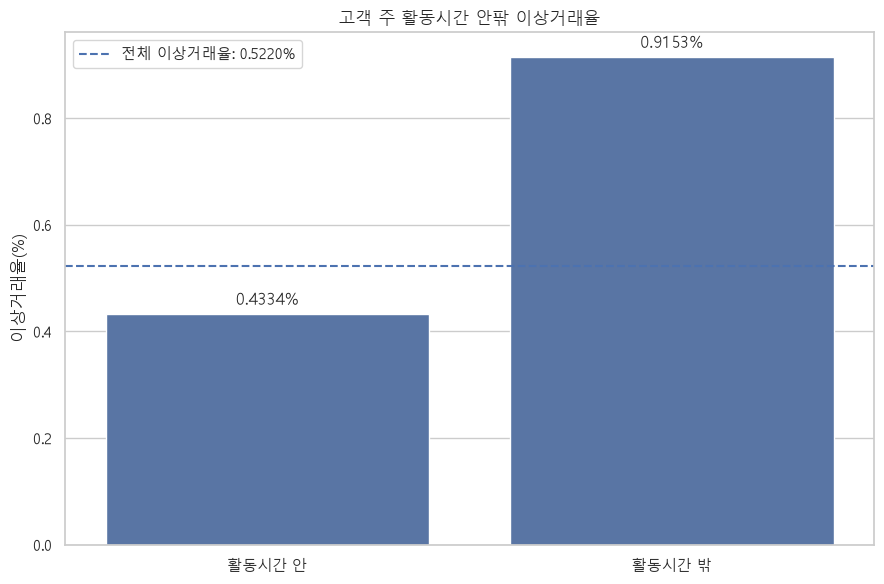

In [34]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=time_risk_summary,
    x="time_group",
    y="is_fraud_rate_pct"
)


# 막대 위 값 표시
for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.4f%%",
        padding=4
    )


# 전체 평균 이상거래율
plt.axhline(
    overall_is_fraud_rate * 100,
    linestyle="--",
    linewidth=1.5,
    label=(
        "전체 이상거래율: "
        f"{overall_is_fraud_rate * 100:.4f}%"
    )
)

plt.title("고객 주 활동시간 안팎 이상거래율")
plt.xlabel("")
plt.ylabel("이상거래율(%)")
plt.legend()
plt.tight_layout()
plt.show()

전체 평균과 비교한 Lift 시각화를 보면,

- 활동시간 안 거래는 전체 평균의 약 0.83배
- 활동시간 밖 거래는 전체 평균의 약 1.75배

유의미한 분석 결과임.

다만, 활동시간 밖 이상거래율이 0.9153%라는 것은 반대로 말하면 '활동시간 밖 거래의 약 99.08%도 정상 거래'라는 뜻. 따라서 다른 위험요인과 결합해야 함.

## 평소 소액 결제를 하던 고객에게 발생한 고액 거래는 전체 고액 거래보다 더 위험한가?

#### 1단계: 정상 거래 기준으로 고객별 평소 결제금액 계산

In [37]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 분석에 필요한 정상 거래만 별도로 추출
# 원본 train은 변경하지 않음
normal_amount_data = train.loc[
    train["is_fraud"] == 0,
    ["cc_num", "amt"]
].copy()


# 고객별 정상 거래금액 특성 계산
customer_amount_profile = (
    normal_amount_data
    .groupby("cc_num", as_index=False)
    .agg(
        normal_transaction_count=("amt", "size"),
        normal_median_amt=("amt", "median"),
        normal_mean_amt=("amt", "mean"),
        normal_q75_amt=("amt", lambda x: x.quantile(0.75))
    )
)


# 정상 거래가 20건 이상인 고객만 사용
customer_amount_profile = (
    customer_amount_profile.loc[
        customer_amount_profile["normal_transaction_count"] >= 20
    ]
    .copy()
)


print(
    f"정상 거래 20건 이상 고객 수: "
    f"{customer_amount_profile['cc_num'].nunique():,}명"
)

display(customer_amount_profile.head())

정상 거래 20건 이상 고객 수: 908명


,cc_num,normal_transaction_count,normal_median_amt,normal_mean_amt,normal_q75_amt
0,60416207185,1509,36.66,55.098569,71.2700
1,60422928733,1519,52.15,64.608308,87.6250
2,60423098130,500,34.68,108.151100,71.4575
3,60427851591,514,76.36,96.272023,98.4625
4,60487002085,496,35.64,50.726028,69.3925


In [ ]:
# 전체 정상 거래금액 분위수
transaction_amount_percentiles = (
    normal_amount_data["amt"]
    .quantile([
        0.25, 0.50, 0.75,
        0.90, 0.95, 0.99
    ])
    .rename("transaction_amt")
    .reset_index()
    .rename(columns={"index": "percentile"})
)

transaction_amount_percentiles["percentile"] = (
    transaction_amount_percentiles["percentile"] * 100
).astype(int)


# 고객별 정상 거래금액 중앙값 분위수
customer_median_percentiles = (
    customer_amount_profile["normal_median_amt"]
    .quantile([
        0.10, 0.25, 0.33,
        0.50, 0.75, 0.90
    ])
    .rename("customer_normal_median_amt")
    .reset_index()
    .rename(columns={"index": "percentile"})
)

customer_median_percentiles["percentile"] = (
    customer_median_percentiles["percentile"] * 100
).astype(int)


print("전체 정상 거래금액 분위수")
display(transaction_amount_percentiles)

print("고객별 정상 거래금액 중앙값 분위수")
display(customer_median_percentiles)

전체 정상 거래금액 분위수


,percentile,transaction_amt
0,25,9.6100
1,50,47.2800
2,75,82.5400
3,90,134.2100
4,95,189.9000
5,99,486.3032


고객별 정상 거래금액 중앙값 분위수


,percentile,customer_normal_median_amt
0,10,33.78400
1,25,36.90250
2,33,38.19310
3,50,41.38500
4,75,52.01125
5,90,75.26950


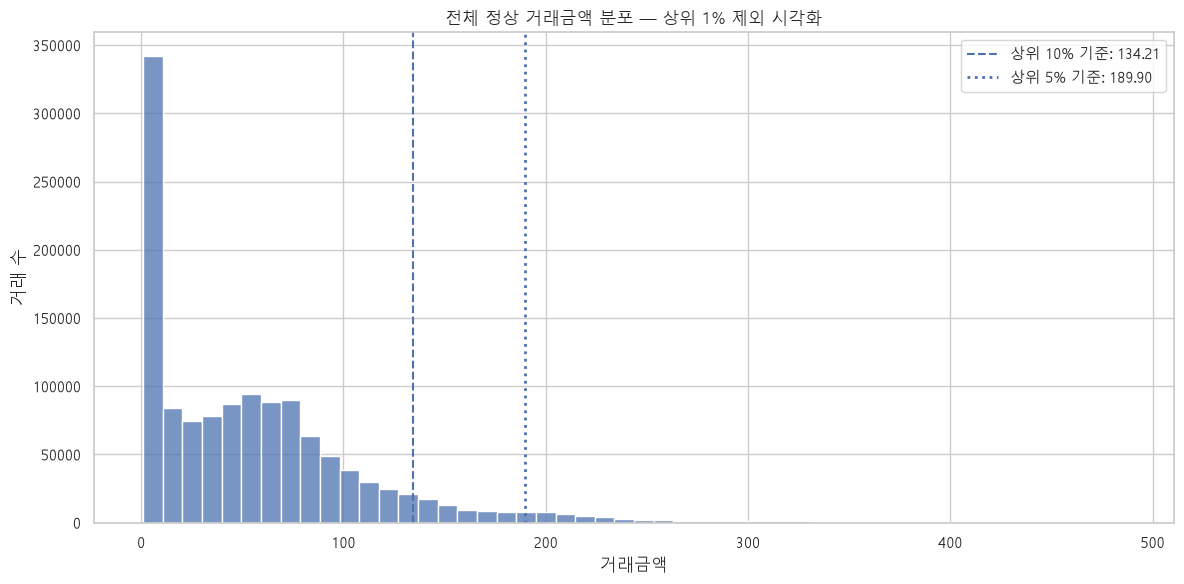

In [39]:
amount_p99 = normal_amount_data["amt"].quantile(0.99)
amount_p90 = normal_amount_data["amt"].quantile(0.90)
amount_p95 = normal_amount_data["amt"].quantile(0.95)


plt.figure(figsize=(12, 6))

sns.histplot(
    data=normal_amount_data.loc[
        normal_amount_data["amt"] <= amount_p99
    ],
    x="amt",
    bins=50
)

plt.axvline(
    amount_p90,
    linestyle="--",
    linewidth=1.5,
    label=f"상위 10% 기준: {amount_p90:,.2f}"
)

plt.axvline(
    amount_p95,
    linestyle=":",
    linewidth=2,
    label=f"상위 5% 기준: {amount_p95:,.2f}"
)

plt.title("전체 정상 거래금액 분포 — 상위 1% 제외 시각화")
plt.xlabel("거래금액")
plt.ylabel("거래 수")
plt.legend()
plt.tight_layout()
plt.show()

위의 표 결과와 비교해보면, 상위 5%의 거래금액 약 $189, 상위 1%가 약 $486.

상위 4~2% 거래금액도 확인해서 어느 구간에서 금액이 확 뛰는지 확인.

In [47]:
import numpy as np
import pandas as pd

# 상위 10%부터 상위 1%까지 분위수
percentile_values = np.arange(0.90, 1.00, 0.01)

upper_amount_thresholds = (
    normal_amount_data["amt"]
    .quantile(percentile_values)
    .rename("amount_threshold")
    .reset_index()
    .rename(columns={"index": "percentile"})
)

# 분위수와 상위 비율 표시
upper_amount_thresholds["percentile_pct"] = (
    upper_amount_thresholds["percentile"] * 100
).round().astype(int)

upper_amount_thresholds["top_pct"] = (
    100 - upper_amount_thresholds["percentile_pct"]
)

# 이전 분위수 대비 금액 증가량
upper_amount_thresholds["amount_increase"] = (
    upper_amount_thresholds["amount_threshold"].diff()
)

# 이전 분위수 대비 증가율
upper_amount_thresholds["increase_rate_pct"] = (
    upper_amount_thresholds["amount_threshold"]
    .pct_change() * 100
)

# 이전 분위수 대비 금액 배수
upper_amount_thresholds["amount_ratio"] = (
    upper_amount_thresholds["amount_threshold"]
    / upper_amount_thresholds["amount_threshold"].shift(1)
)

display(
    upper_amount_thresholds[
        [
            "percentile_pct",
            "top_pct",
            "amount_threshold",
            "amount_increase",
            "increase_rate_pct",
            "amount_ratio"
        ]
    ].round(2)
)

,percentile_pct,top_pct,amount_threshold,amount_increase,increase_rate_pct,amount_ratio
0,90,10,134.21,NaN,NaN,NaN
1,91,9,140.79,6.58,4.90,1.05
2,92,8,148.84,8.05,5.72,1.06
3,93,7,159.78,10.94,7.35,1.07
4,94,6,174.28,14.50,9.07,1.09
5,95,5,189.90,15.62,8.96,1.09
6,96,4,206.17,16.27,8.57,1.09
7,97,3,229.77,23.60,11.45,1.11
8,98,2,296.65,66.88,29.11,1.29
9,99,1,486.30,189.65,63.93,1.64


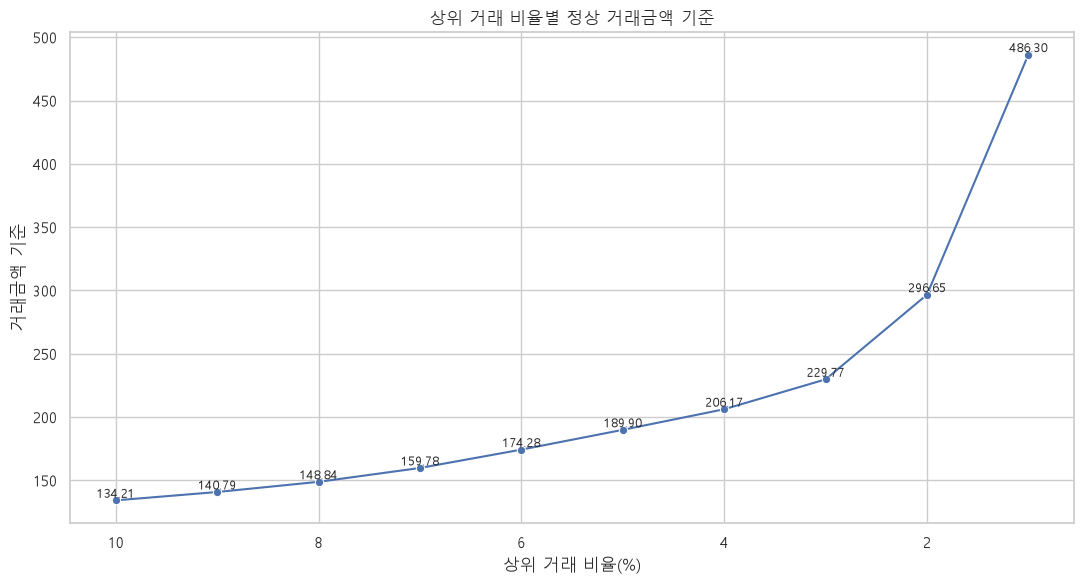

In [48]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

plt.figure(figsize=(11, 6))

sns.lineplot(
    data=upper_amount_thresholds,
    x="top_pct",
    y="amount_threshold",
    marker="o"
)

for _, row in upper_amount_thresholds.iterrows():
    plt.text(
        row["top_pct"],
        row["amount_threshold"],
        f"{row['amount_threshold']:.2f}",
        ha="center",
        va="bottom",
        fontsize=9
    )

plt.gca().invert_xaxis()

plt.title("상위 거래 비율별 정상 거래금액 기준")
plt.xlabel("상위 거래 비율(%)")
plt.ylabel("거래금액 기준")
plt.tight_layout()
plt.show()

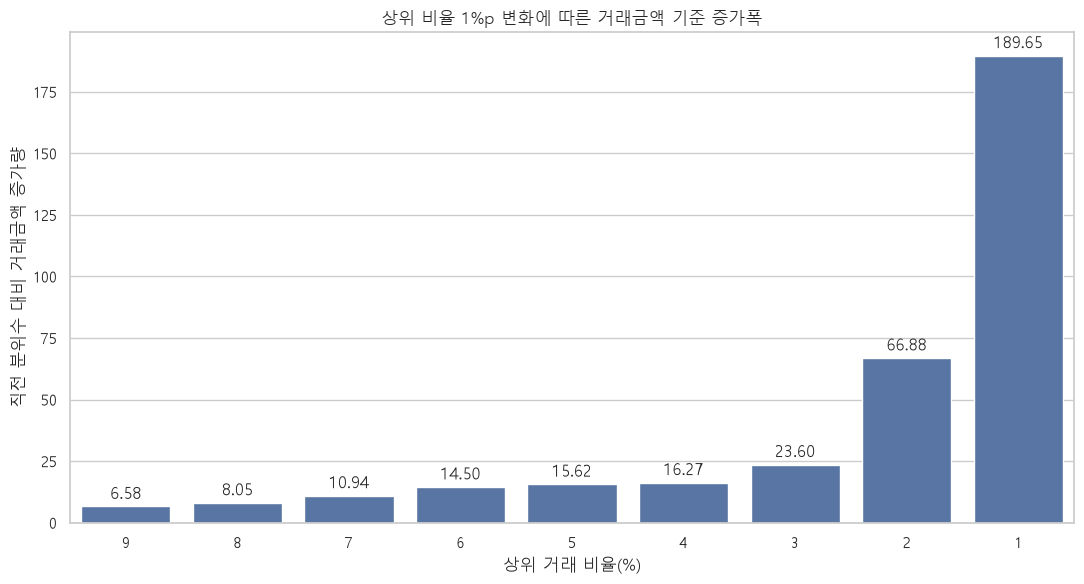

In [49]:
increase_plot_data = upper_amount_thresholds.dropna(
    subset=["amount_increase"]
).copy()

plt.figure(figsize=(11, 6))

ax = sns.barplot(
    data=increase_plot_data,
    x="top_pct",
    y="amount_increase"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.gca().invert_xaxis()

plt.title("상위 비율 1%p 변화에 따른 거래금액 기준 증가폭")
plt.xlabel("상위 거래 비율(%)")
plt.ylabel("직전 분위수 대비 거래금액 증가량")
plt.tight_layout()
plt.show()

상위 2%부터 증가폭이 커지고, 상위 1%에서 매우 급격히 증가.

In [41]:
# 정상 거래금액 기준값
amount_p90 = normal_amount_data["amt"].quantile(0.90)
amount_p95 = normal_amount_data["amt"].quantile(0.95)
amount_p99 = normal_amount_data["amt"].quantile(0.99)
amount_p995 = normal_amount_data["amt"].quantile(0.995)

# 상위 10% 거래만 추출
high_amount_data = normal_amount_data.loc[
    normal_amount_data["amt"] >= amount_p90
].copy()

print(f"90분위수: {amount_p90:,.2f}")
print(f"95분위수: {amount_p95:,.2f}")
print(f"99분위수: {amount_p99:,.2f}")
print(f"99.5분위수: {amount_p995:,.2f}")
print(f"상위 10% 정상 거래 수: {len(high_amount_data):,}건")

90분위수: 134.21
95분위수: 189.90
99분위수: 486.30
99.5분위수: 654.18
상위 10% 정상 거래 수: 128,938건


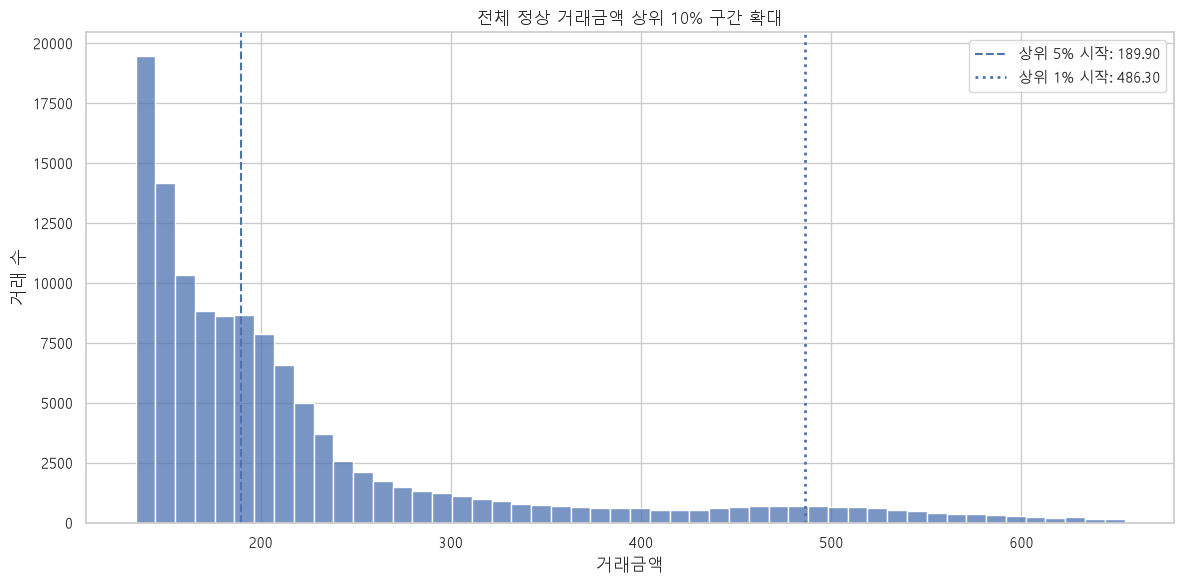

In [42]:
plt.figure(figsize=(12, 6))

sns.histplot(
    data=high_amount_data.loc[
        high_amount_data["amt"] <= amount_p995
    ],
    x="amt",
    bins=50
)

plt.axvline(
    amount_p95,
    linestyle="--",
    linewidth=1.5,
    label=f"상위 5% 시작: {amount_p95:,.2f}"
)

plt.axvline(
    amount_p99,
    linestyle=":",
    linewidth=2,
    label=f"상위 1% 시작: {amount_p99:,.2f}"
)

plt.title("전체 정상 거래금액 상위 10% 구간 확대")
plt.xlabel("거래금액")
plt.ylabel("거래 수")
plt.legend()
plt.tight_layout()
plt.show()

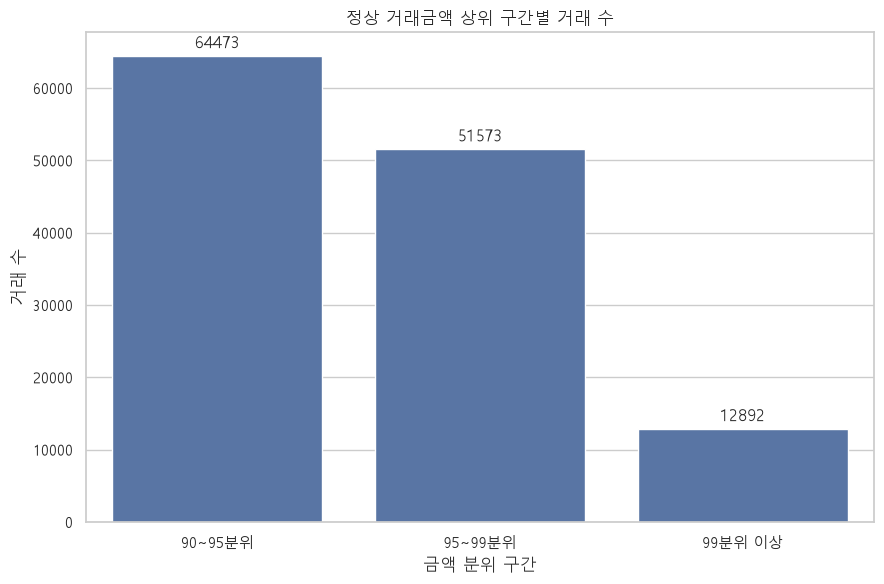

In [ ]:
plt.figure(figsize=(9, 6))

ax = sns.barplot(
    data=high_amount_band_summary,
    x="amount_band",
    y="transaction_count"a
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%d",
        padding=3
    )

plt.title("정상 거래금액 상위 구간별 거래 수")
plt.xlabel("금액 분위 구간")
plt.ylabel("거래 수")
plt.tight_layout()
plt.show()

[다양한 그래프 분석 내용]


정상 거래금액 '상위 10%'는 134.21 이상으로 나타났으나, 
해당 구간 안에서도 189.90 이상의 '상위 5%'와 486.30 이상의 '상위 1%'는 거래 규모가 크게 달랐다. 따라서 모든 고액 거래를 하나의 집단으로 처리하기보다 '상위 10%, 5%, 1%로 세분화'하여 평소 소액 고객에게 발생한 고액 거래의 위험도를 비교할 필요가 있다. 특히 '상위 1% 거래도 약 1.3만 건으로 충분한 분석 표본'을 확보하고 있다.

그리고 '기준' 선택에 따른 '결과 변화'를 확인하기 위해,

- 상위 5%: 일반 고액 거래
- 상위 2%: 초고액 진입 구간
- 상위 1%: 극단적 초고액 거래

세 기준을 비교하기.

예) " 고객별 '정상 거래금액 중앙값'이 낮은 소액 고객에게 상위 1% 초고액 거래가 발생했을 때, 그 외 고객의 상위 1% 거래보다 이상거래율이 높은가? 몇 배 높은가?"

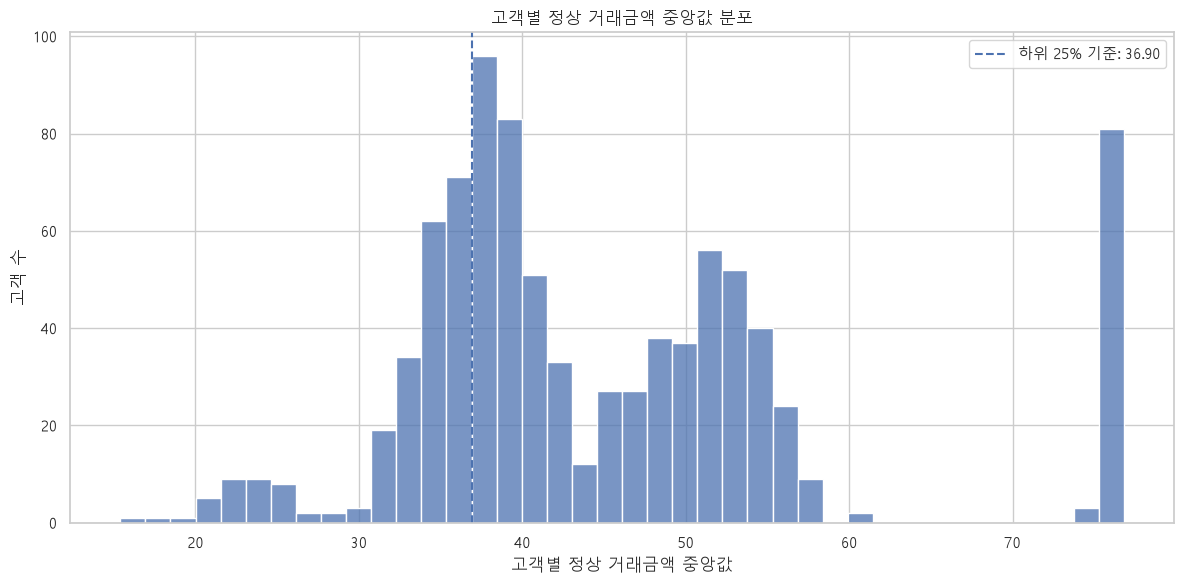

In [40]:
low_customer_q25 = (
    customer_amount_profile["normal_median_amt"]
    .quantile(0.25)
)

customer_median_p99 = (
    customer_amount_profile["normal_median_amt"]
    .quantile(0.99)
)


plt.figure(figsize=(12, 6))

sns.histplot(
    data=customer_amount_profile.loc[
        customer_amount_profile["normal_median_amt"]
        <= customer_median_p99
    ],
    x="normal_median_amt",
    bins=40
)

plt.axvline(
    low_customer_q25,
    linestyle="--",
    linewidth=1.5,
    label=f"하위 25% 기준: {low_customer_q25:,.2f}"
)

plt.title("고객별 정상 거래금액 중앙값 분포")
plt.xlabel("고객별 정상 거래금액 중앙값")
plt.ylabel("고객 수")
plt.legend()
plt.tight_layout()
plt.show()

고객별 정상 거래금액 중앙값은 크게 4개의 집단으로 나뉘어 보임.

분포 기반 정의 -> 큰 봉우리 2개 사이의 골짜기(약 $44) 이하 = 소액 고객

## 이상거래율이 높은 상위 20개 가맹점

In [58]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 1. 가맹점별 이상거래율 계산
merchant_fraud_summary = (
    train.groupby("merchant", as_index=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        unique_customers=("cc_num", "nunique")
    )
)

merchant_fraud_summary["is_fraud_rate_pct"] = (
    merchant_fraud_summary["is_fraud_transactions"]
    / merchant_fraud_summary["total_transactions"]
    * 100
)


# 2. 이상거래율 내림차순 TOP 20
# 이상거래율이 같으면 이상거래 건수가 많은 순으로 정렬
merchant_top20 = (
    merchant_fraud_summary
    .sort_values(
        [
            "is_fraud_rate_pct",
            "is_fraud_transactions",
            "total_transactions"
        ],
        ascending=[False, False, False]
    )
    .head(20)
    .reset_index(drop=True)
)

merchant_top20.index = merchant_top20.index + 1
merchant_top20.index.name = "rank"

display(
    merchant_top20[
        [
            "merchant",
            "total_transactions",
            "is_fraud_transactions",
            "is_fraud_rate_pct",
            "unique_customers"
        ]
    ].round(4)
)

,merchant,total_transactions,is_fraud_transactions,is_fraud_rate_pct,unique_customers
rank,,,,,
1,fraud_Kozey-Boehm,1866,48,2.5723,704
2,"fraud_Herman, Treutel and Dickens",1300,33,2.5385,625
3,fraud_Kerluke-Abshire,1838,41,2.2307,697
4,fraud_Brown PLC,1176,26,2.2109,585
5,fraud_Goyette Inc,1943,42,2.1616,720
6,fraud_Terry-Huel,1996,43,2.1543,730
7,fraud_Jast Ltd,1953,42,2.1505,723
8,"fraud_Schmeler, Bashirian and Price",1968,41,2.0833,717
9,fraud_Boyer-Reichert,1908,38,1.9916,723


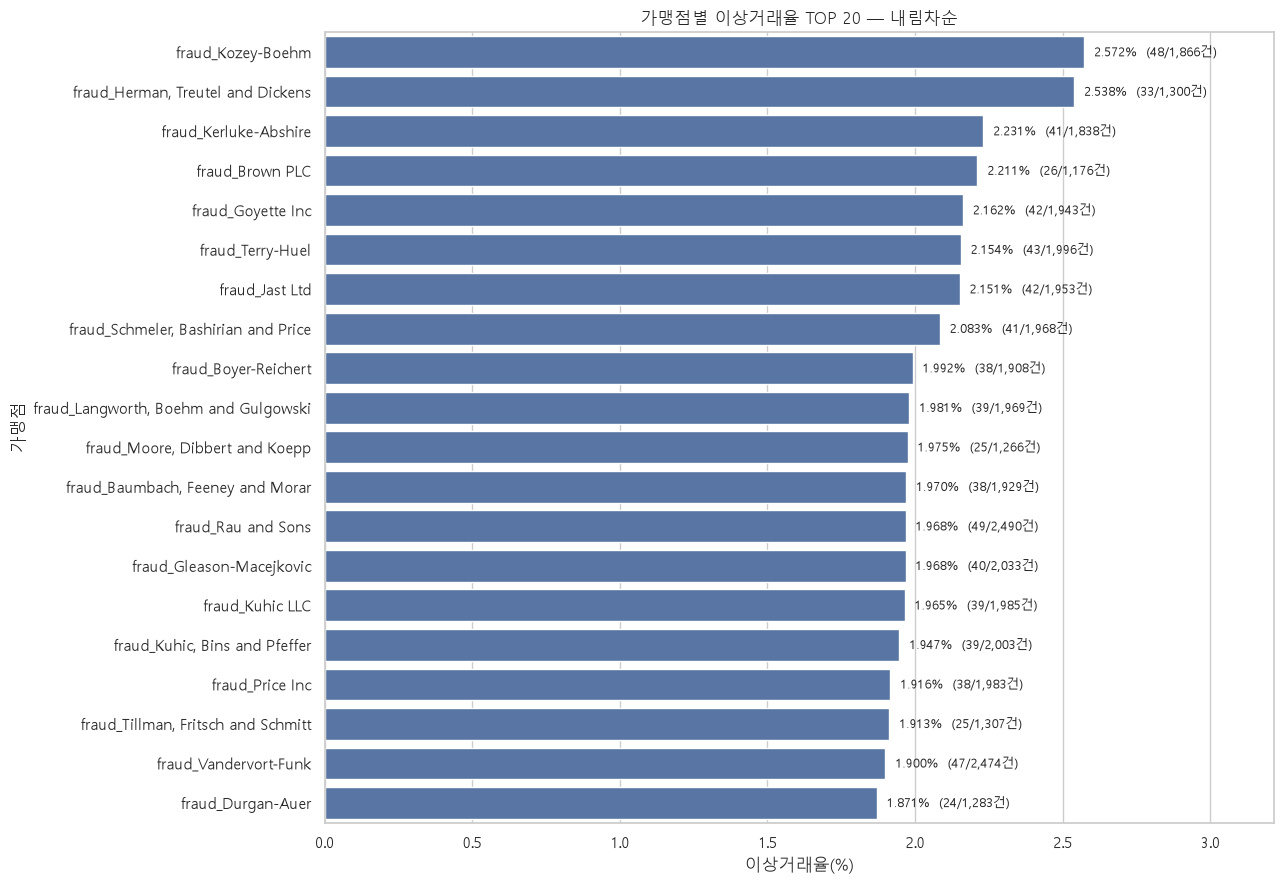

In [59]:
# seaborn의 y축 순서를 명시적으로 내림차순 지정
merchant_order = merchant_top20["merchant"].tolist()

plt.figure(figsize=(13, 9))

ax = sns.barplot(
    data=merchant_top20,
    x="is_fraud_rate_pct",
    y="merchant",
    order=merchant_order
)

# 막대 끝에 이상거래율과 이상거래 건수 표시
for patch, (_, row) in zip(
    ax.patches,
    merchant_top20.iterrows()
):
    ax.text(
        patch.get_width(),
        patch.get_y() + patch.get_height() / 2,
        (
            f"  {row['is_fraud_rate_pct']:.3f}%"
            f"  ({int(row['is_fraud_transactions']):,}"
            f"/{int(row['total_transactions']):,}건)"
        ),
        va="center",
        fontsize=9
    )

plt.title("가맹점별 이상거래율 TOP 20 — 내림차순")
plt.xlabel("이상거래율(%)")
plt.ylabel("가맹점")
plt.xlim(
    0,
    merchant_top20["is_fraud_rate_pct"].max() * 1.25
)
plt.tight_layout()
plt.show()

## 온/오프라인 쇼핑 vs. 온/오프라인 기타 쇼핑

In [60]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


target_categories = [
    "shopping_net",
    "shopping_pos",
    "misc_net",
    "misc_pos"
]


shopping_misc_data = train.loc[
    train["category"].isin(target_categories),
    [
        "category",
        "merchant",
        "cc_num",
        "amt",
        "is_fraud"
    ]
].copy()


# 가맹점 이름 앞의 fraud_ 제거
# 원본 merchant는 그대로 유지
shopping_misc_data["merchant_name"] = (
    shopping_misc_data["merchant"]
    .str.replace(r"^fraud_", "", regex=True)
)


category_label_map = {
    "shopping_net": "온라인 일반 쇼핑",
    "shopping_pos": "오프라인 일반 쇼핑",
    "misc_net": "온라인 기타 거래",
    "misc_pos": "오프라인 기타 거래"
}

shopping_misc_data["category_label"] = (
    shopping_misc_data["category"]
    .map(category_label_map)
)

print(f"분석 대상 거래 수: {len(shopping_misc_data):,}건")
print(f"분석 대상 가맹점 수: {shopping_misc_data['merchant'].nunique():,}개")

분석 대상 거래 수: 357,157건
분석 대상 가맹점 수: 198개


- shopping_net: 온라인 쇼핑
- shopping_pos: 오프라인 쇼핑
- misc_net: 온라인 기타 쇼핑
- misc_pos: 오프라인 기타 쇼핑

이 4가지 가맹점 수 합계: 198

In [61]:
category_summary = (
    shopping_misc_data
    .groupby(
        ["category", "category_label"],
        as_index=False
    )
    .agg(
        total_transactions=("is_fraud", "size"),
        merchant_count=("merchant", "nunique"),
        unique_customers=("cc_num", "nunique"),
        is_fraud_transactions=("is_fraud", "sum"),
        mean_amt=("amt", "mean"),
        median_amt=("amt", "median"),
        q75_amt=("amt", lambda x: x.quantile(0.75)),
        max_amt=("amt", "max")
    )
)


category_summary["is_fraud_rate_pct"] = (
    category_summary["is_fraud_transactions"]
    / category_summary["total_transactions"]
    * 100
)


category_summary = category_summary.sort_values(
    "is_fraud_rate_pct",
    ascending=False
).reset_index(drop=True)


display(category_summary.round(3))

,category,category_label,total_transactions,merchant_count,unique_customers,is_fraud_transactions,mean_amt,median_amt,q75_amt,max_amt,is_fraud_rate_pct
0,shopping_net,온라인 일반 쇼핑,97543,50,977,1713,88.424,8.44,82.775,9555.26,1.756
1,misc_net,온라인 기타 거래,63287,50,968,915,80.865,9.84,87.855,4084.34,1.446
2,shopping_pos,오프라인 일반 쇼핑,116672,50,961,843,79.779,7.76,67.208,9754.72,0.723
3,misc_pos,오프라인 기타 거래,79655,50,921,250,62.891,13.92,51.180,2703.62,0.314


이 표에서 비교할 것은:

- 업종별 가맹점 수가 다른지
- 특정 업종에 거래가 몰리는지
- 온라인과 오프라인의 금액 수준이 다른지
- misc와 shopping 중 어디의 이상거래율이 높은지

'기타'와 '일반'쇼핑의 차이가 '온라인', '오프라인'에서 꽤 다르게 나타남.

1. 이상거래율(마지막 컬럼 is_fraud_rate_pct)은 온라인이 확실히 높음.
- 온라인 일반쇼핑은 오프라인 일반쇼핑보다 약 2.4배
- 온라인 기타쇼핑은 오프라인 기타쇼핑보다 약 4.6배
=> 따라서 이 표로는, misc냐 shopping이냐보다, 온라인 거래인지가 더 큰 구분 요인으로 보임.

2. 가맹점 수는 4가지 category(업종) 모두 정확히 50개. 균등함.

3. 고객 대부분이 4가지 업종을 모두 이용함.
총 고객 983명 중,
shopping_net: 977명
misc_net: 968명
shopping_pos: 961명
misc_pos: 921명
=> 즉, 이 4가지 업종은 대부분 고객이 이용하는 일반적인 범주. 따라서, 같은 고객이 평소 이용하더 misc 또는 shopping 가맹점과 다른 새로운 가맹점에서 이상거래가 발생했는지를 보면 좋음.

#### 각 업종의 50개 가맹점 전부 펼쳐서 확인.

In [65]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")


# 분석할 4개 업종
target_categories = [
    "shopping_net",
    "misc_net",
    "shopping_pos",
    "misc_pos"
]

category_label_map = {
    "shopping_net": "온라인 일반 쇼핑",
    "misc_net": "온라인 기타 거래",
    "shopping_pos": "오프라인 일반 쇼핑",
    "misc_pos": "오프라인 기타 거래"
}


# 1. 원본 train에서 4개 업종만 별도 추출
shopping_misc_data = train.loc[
    train["category"].isin(target_categories),
    [
        "category",
        "merchant",
        "cc_num",
        "amt",
        "is_fraud"
    ]
].copy()


# 표시용 가맹점명 생성
shopping_misc_data["merchant_name"] = (
    shopping_misc_data["merchant"]
    .astype(str)
    .str.replace(r"^fraud_", "", regex=True)
)

shopping_misc_data["category_label"] = (
    shopping_misc_data["category"]
    .map(category_label_map)
)


# 2. 업종·가맹점별 상세 요약표 생성
merchant_category_detail = (
    shopping_misc_data
    .groupby(
        [
            "category",
            "category_label",
            "merchant",
            "merchant_name"
        ],
        as_index=False
    )
    .agg(
        total_transactions=("is_fraud", "size"),
        normal_transactions=(
            "is_fraud",
            lambda x: (x == 0).sum()
        ),
        is_fraud_transactions=("is_fraud", "sum"),
        unique_customers=("cc_num", "nunique"),
        mean_amt=("amt", "mean"),
        median_amt=("amt", "median"),
        q75_amt=("amt", lambda x: x.quantile(0.75)),
        max_amt=("amt", "max")
    )
)


# 가맹점별 이상거래율
merchant_category_detail["is_fraud_rate_pct"] = (
    merchant_category_detail["is_fraud_transactions"]
    / merchant_category_detail["total_transactions"]
    * 100
)


print(
    f"분석 대상 거래 수: "
    f"{len(shopping_misc_data):,}건"
)

print(
    f"고유 가맹점 수: "
    f"{merchant_category_detail['merchant'].nunique():,}개"
)

분석 대상 거래 수: 357,157건
고유 가맹점 수: 198개


In [ ]:
for category in target_categories:

    result = (
        merchant_category_detail.loc[
            merchant_category_detail["category"] == category,
            [
                "merchant_name",
                "total_transactions",
                "normal_transactions",
                "is_fraud_transactions",
                "is_fraud_rate_pct",
                "unique_customers",
                "mean_amt",
                "median_amt",
                "q75_amt",
                "max_amt"
            ]
        ]
        .sort_values(
            [
                "is_fraud_rate_pct",
                "is_fraud_transactions",
                "total_transactions"
            ],
            ascending=[False, False, False]
        )
        .reset_index(drop=True)
    )

    result.index = result.index + 1
    result.index.name = "순위"

    print()
    print("=" * 100)
    print(
        f"{category} — "
        f"{category_label_map[category]}"
    )
    print(
        f"가맹점 수: {len(result):,}개"
    )
    print("=" * 100)

    display(
        result.round({
            "is_fraud_rate_pct": 4,
            "mean_amt": 2,
            "median_amt": 2,
            "q75_amt": 2,
            "max_amt": 2
        })
    )

In [68]:
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns

# seaborn 스타일을 먼저 설정
sns.set_theme(style="whitegrid")

# Windows 맑은 고딕 직접 등록
font_path = r"C:\Windows\Fonts\malgun.ttf"

fm.fontManager.addfont(font_path)
font_name = fm.FontProperties(fname=font_path).get_name()

# 한글 폰트 적용
plt.rcParams["font.family"] = font_name
plt.rcParams["font.sans-serif"] = [font_name]
plt.rcParams["axes.unicode_minus"] = False

print("적용된 폰트:", font_name)

적용된 폰트: Malgun Gothic


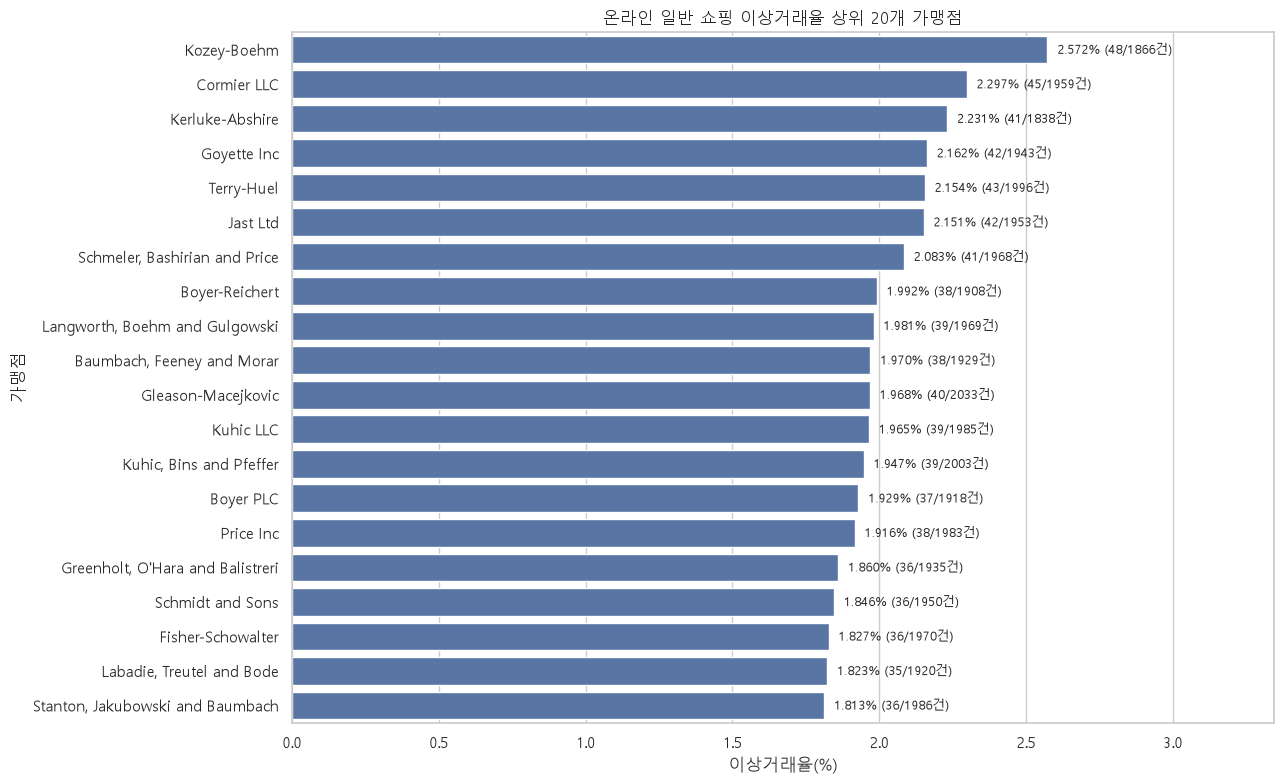

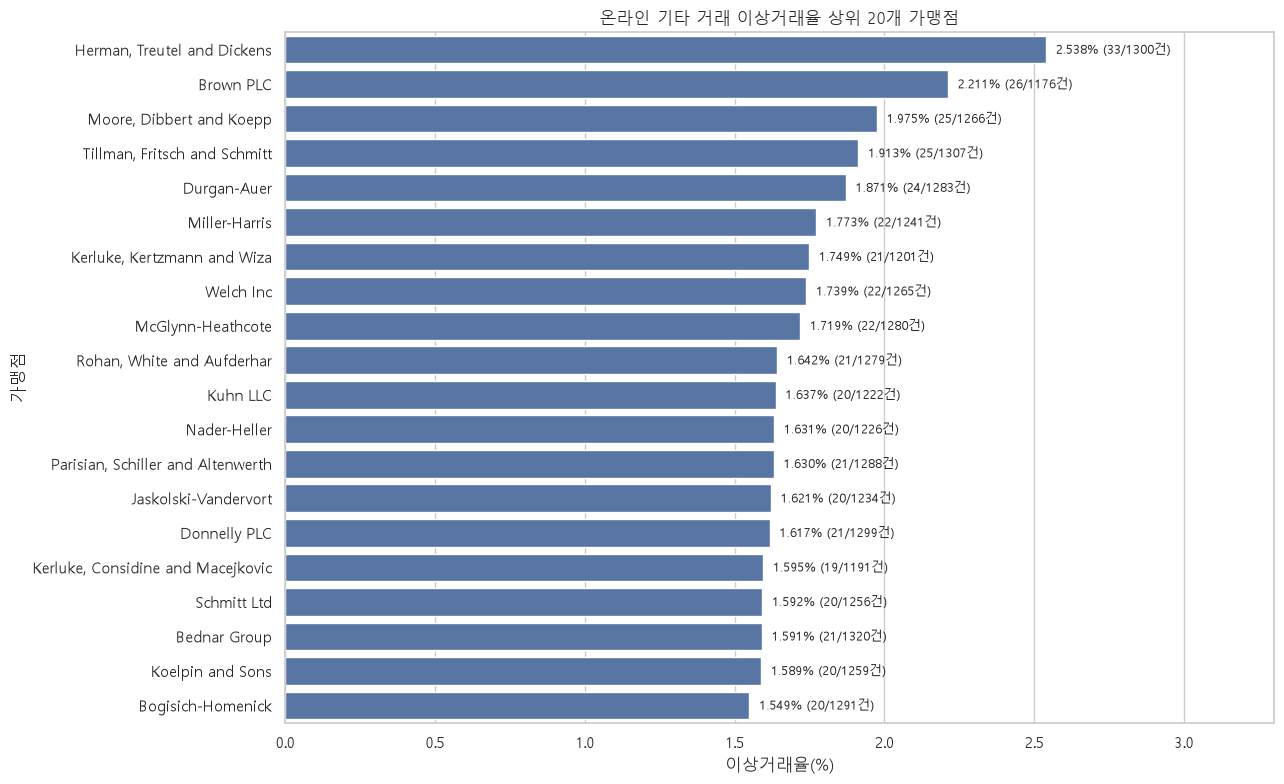

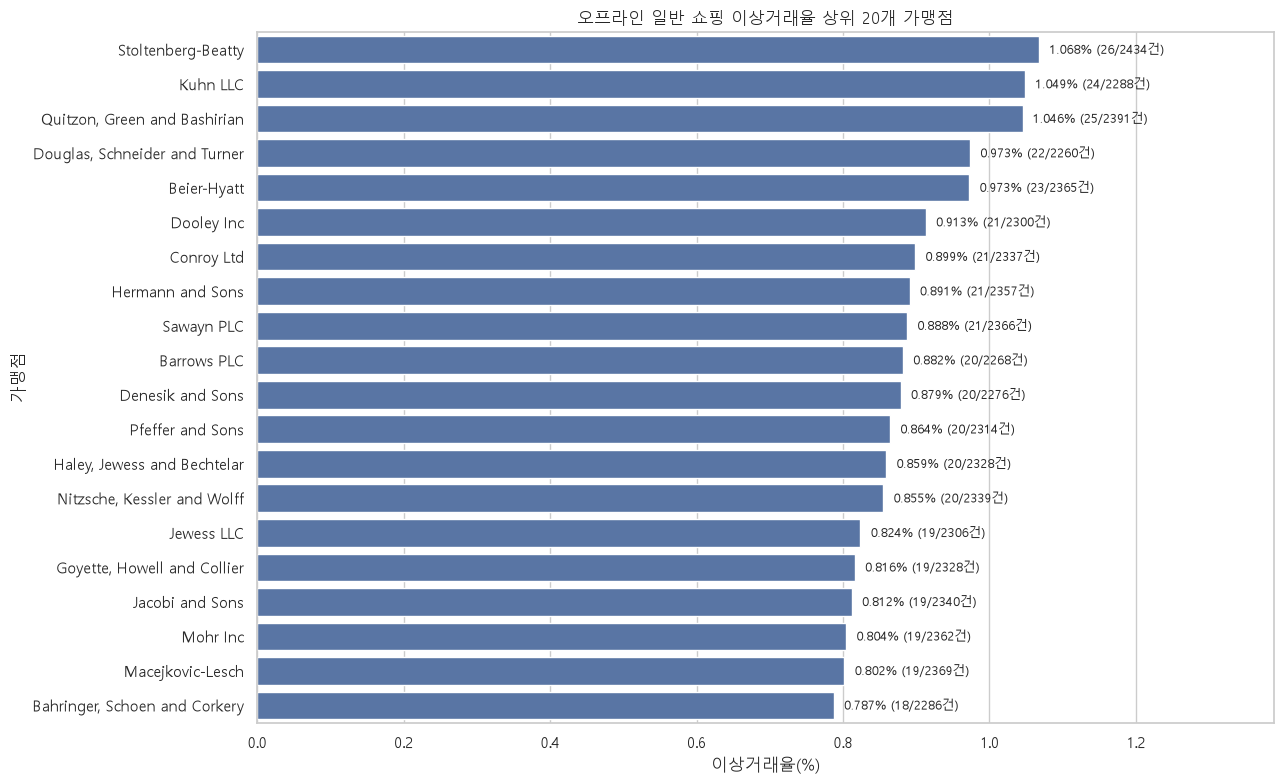

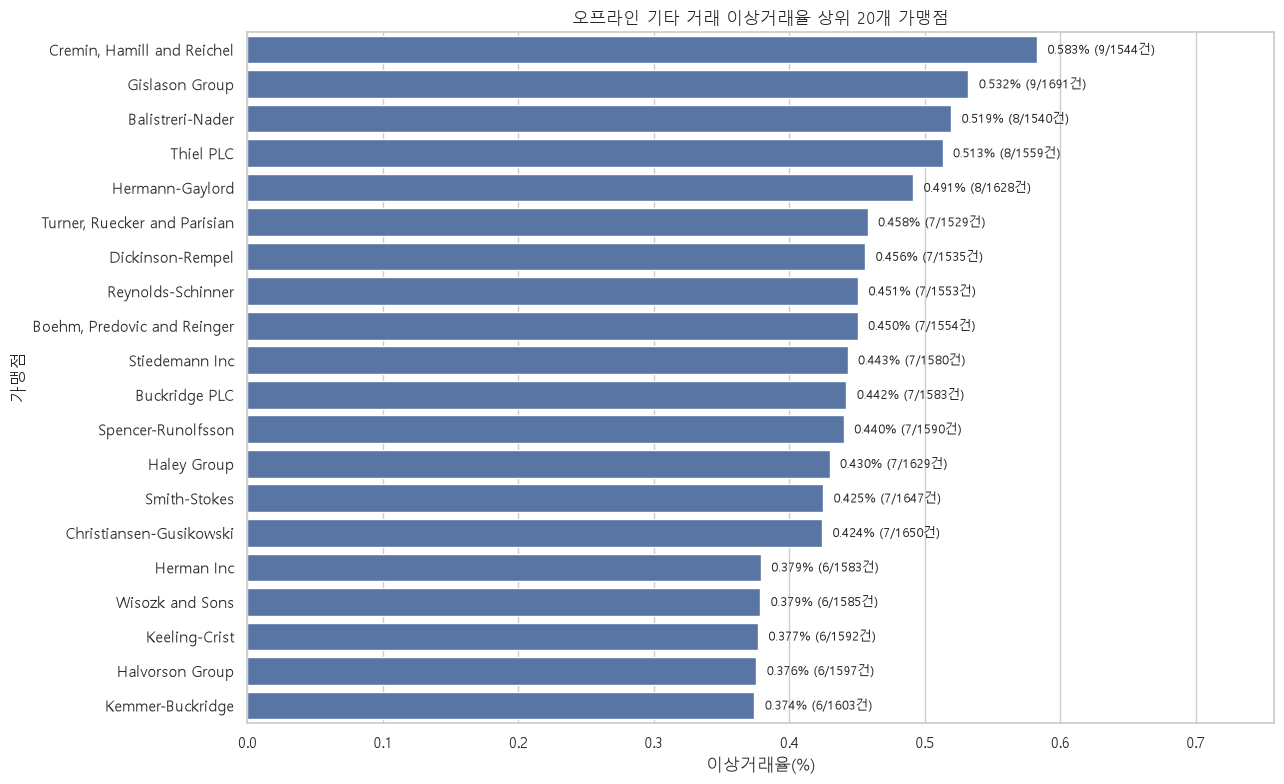

In [69]:
for category in target_categories:

    top20 = (
        merchant_category_detail.loc[
            merchant_category_detail["category"] == category
        ]
        .sort_values(
            [
                "is_fraud_rate_pct",
                "is_fraud_transactions",
                "total_transactions"
            ],
            ascending=[False, False, False]
        )
        .head(20)
        .copy()
    )

    merchant_order = top20["merchant_name"].tolist()

    plt.figure(figsize=(13, 8))

    ax = sns.barplot(
        data=top20,
        x="is_fraud_rate_pct",
        y="merchant_name",
        order=merchant_order
    )

    for patch, (_, row) in zip(
        ax.patches,
        top20.iterrows()
    ):
        ax.text(
            patch.get_width(),
            patch.get_y() + patch.get_height() / 2,
            (
                f"  {row['is_fraud_rate_pct']:.3f}%"
                f" ({int(row['is_fraud_transactions'])}"
                f"/{int(row['total_transactions'])}건)"
            ),
            va="center",
            fontsize=9
        )

    plt.title(
        f"{category_label_map[category]} "
        f"이상거래율 상위 20개 가맹점"
    )
    plt.xlabel("이상거래율(%)")
    plt.ylabel("가맹점")

    if not top20.empty:
        plt.xlim(
            0,
            top20["is_fraud_rate_pct"].max() * 1.3
        )

    plt.tight_layout()
    plt.show()

가장 큰 차이는 shopping vs misc보다 온라인 vs 오프라인.

- shopping_net TOP 20 평균은 shopping_pos의 약 2.3배
- misc_net TOP 20 평균은 misc_pos의 약 3.9배 -> 특히 온라인 기타 거래는 오프라인 기타 거래보다 훨씬 높은 이상거래율을 나타냈다.

아쉬운 점은 '어떤 물건을 파는 가맹점인가'는 알 수 없음. 

## city_pop 과 job

##### 1단계: 고객 단위 분석 데이터 만들기

In [ ]:
## city_pop은 고객 특성이므로, 129만 건 거래를 비교하기 보다,
## 고객 983명 단위로 요약.

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display


# 스타일 설정
sns.set_theme(style="whitegrid")

# Windows 한글 폰트 설정
font_path = r"C:\Windows\Fonts\malgun.ttf"

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()

    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.sans-serif"] = [font_name]

plt.rcParams["axes.unicode_minus"] = False


# 필요한 열 확인
required_columns = [
    "cc_num",
    "city_pop",
    "job",
    "is_fraud"
]

missing_columns = [
    col for col in required_columns
    if col not in train.columns
]

if missing_columns:
    raise KeyError(
        f"train에 없는 열: {missing_columns}"
    )

In [73]:
customer_attribute_check = (
    train.groupby("cc_num", as_index=False)
    .agg(
        city_pop_count=("city_pop", "nunique"),
        job_count=("job", "nunique")
    )
)

print(
    "여러 city_pop 값이 있는 고객:",
    (
        customer_attribute_check["city_pop_count"] > 1
    ).sum()
)

print(
    "여러 job 값이 있는 고객:",
    (
        customer_attribute_check["job_count"] > 1
    ).sum()
)

여러 city_pop 값이 있는 고객: 0
여러 job 값이 있는 고객: 0


In [74]:
# 고객별 이상거래 정보
customer_fraud_profile = (
    train.groupby("cc_num", as_index=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum"),
        customer_fraud_rate=("is_fraud", "mean")
    )
)

customer_fraud_profile["customer_fraud_rate_pct"] = (
    customer_fraud_profile["customer_fraud_rate"] * 100
)

customer_fraud_profile["fraud_experience_flag"] = (
    customer_fraud_profile["is_fraud_transactions"] > 0
).astype(int)


# 고객별 도시 인구와 직업
customer_attributes = (
    train.groupby("cc_num", as_index=False)
    .agg(
        city_pop=("city_pop", "first"),
        job=("job", "first")
    )
)


# 고객 단위 분석 데이터
customer_context_analysis = (
    customer_fraud_profile
    .merge(
        customer_attributes,
        on="cc_num",
        how="left",
        validate="one_to_one"
    )
)

print(
    f"고객 수: "
    f"{customer_context_analysis['cc_num'].nunique():,}명"
)

display(customer_context_analysis.head())

고객 수: 983명


,cc_num,total_transactions,is_fraud_transactions,customer_fraud_rate,customer_fraud_rate_pct,fraud_experience_flag,city_pop,job
0,60416207185,1518,9,0.005929,0.592885,1,1645,Information systems manager
1,60422928733,1531,12,0.007838,0.783801,1,46944,Secondary school teacher
2,60423098130,510,10,0.019608,1.960784,1,83,Barrister's clerk
3,60427851591,528,14,0.026515,2.651515,1,2142,Politician's assistant
4,60487002085,496,0,0.000000,0.000000,0,233060,"Horticulturist, commercial"


##### 2단계: 직업별 이상거래율

In [80]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
from IPython.display import display

sns.set_theme(style="whitegrid")

# 한글 폰트 설정
font_path = r"C:\Windows\Fonts\malgun.ttf"

if os.path.exists(font_path):
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
    plt.rcParams["font.family"] = font_name
    plt.rcParams["font.sans-serif"] = [font_name]

plt.rcParams["axes.unicode_minus"] = False


# 직업별 고객 수·거래 건수·이상거래 건수
job_transaction_summary = (
    train.dropna(subset=["job"])
    .groupby("job", as_index=False)
    .agg(
        customer_count=("cc_num", "nunique"),
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum")
    )
)

# 고객 1명당 평균 거래 건수
job_transaction_summary["transactions_per_customer"] = (
    job_transaction_summary["total_transactions"]
    / job_transaction_summary["customer_count"]
)

# 이상거래율
job_transaction_summary["is_fraud_rate_pct"] = (
    job_transaction_summary["is_fraud_transactions"]
    / job_transaction_summary["total_transactions"]
    * 100
)

print(
    f"전체 직업 종류: "
    f"{job_transaction_summary['job'].nunique():,}개"
)

display(
    job_transaction_summary
    .sort_values(
        ["total_transactions", "customer_count"],
        ascending=False
    )
    .reset_index(drop=True)
    .round({
        "transactions_per_customer": 1,
        "is_fraud_rate_pct": 4
    })
)

전체 직업 종류: 494개


,job,customer_count,total_transactions,is_fraud_transactions,transactions_per_customer,is_fraud_rate_pct
0,Film/video editor,5,9779,44,1955.8,0.4499
1,Exhibition designer,5,9199,51,1839.8,0.5544
2,Naval architect,6,8684,53,1447.3,0.6103
3,"Surveyor, land/geomatics",5,8680,50,1736.0,0.5760
4,Materials engineer,6,8270,62,1378.3,0.7497
...,...,...,...,...,...,...
489,Information officer,1,8,8,8.0,100.0000
490,Veterinary surgeon,1,8,8,8.0,100.0000
491,Contracting civil engineer,1,7,7,7.0,100.0000
492,Ship broker,1,7,7,7.0,100.0000


In [81]:
job_summary_customer3 = (
    job_transaction_summary.loc[
        job_transaction_summary["customer_count"] >= 3
    ]
    .sort_values(
        ["total_transactions", "customer_count"],
        ascending=False
    )
    .reset_index(drop=True)
)

print(
    f"고객 3명 이상인 직업 수: "
    f"{len(job_summary_customer3):,}개"
)

display(
    job_summary_customer3.round({
        "transactions_per_customer": 1,
        "is_fraud_rate_pct": 4
    })
)

고객 3명 이상인 직업 수: 129개


,job,customer_count,total_transactions,is_fraud_transactions,transactions_per_customer,is_fraud_rate_pct
0,Film/video editor,5,9779,44,1955.8,0.4499
1,Exhibition designer,5,9199,51,1839.8,0.5544
2,Naval architect,6,8684,53,1447.3,0.6103
3,"Surveyor, land/geomatics",5,8680,50,1736.0,0.5760
4,Materials engineer,6,8270,62,1378.3,0.7497
...,...,...,...,...,...,...
124,"Therapist, horticultural",3,2528,18,842.7,0.7120
125,Transport planner,3,2098,24,699.3,1.1439
126,Chief Marketing Officer,3,2092,23,697.3,1.0994
127,"Pharmacist, hospital",3,1059,24,353.0,2.2663


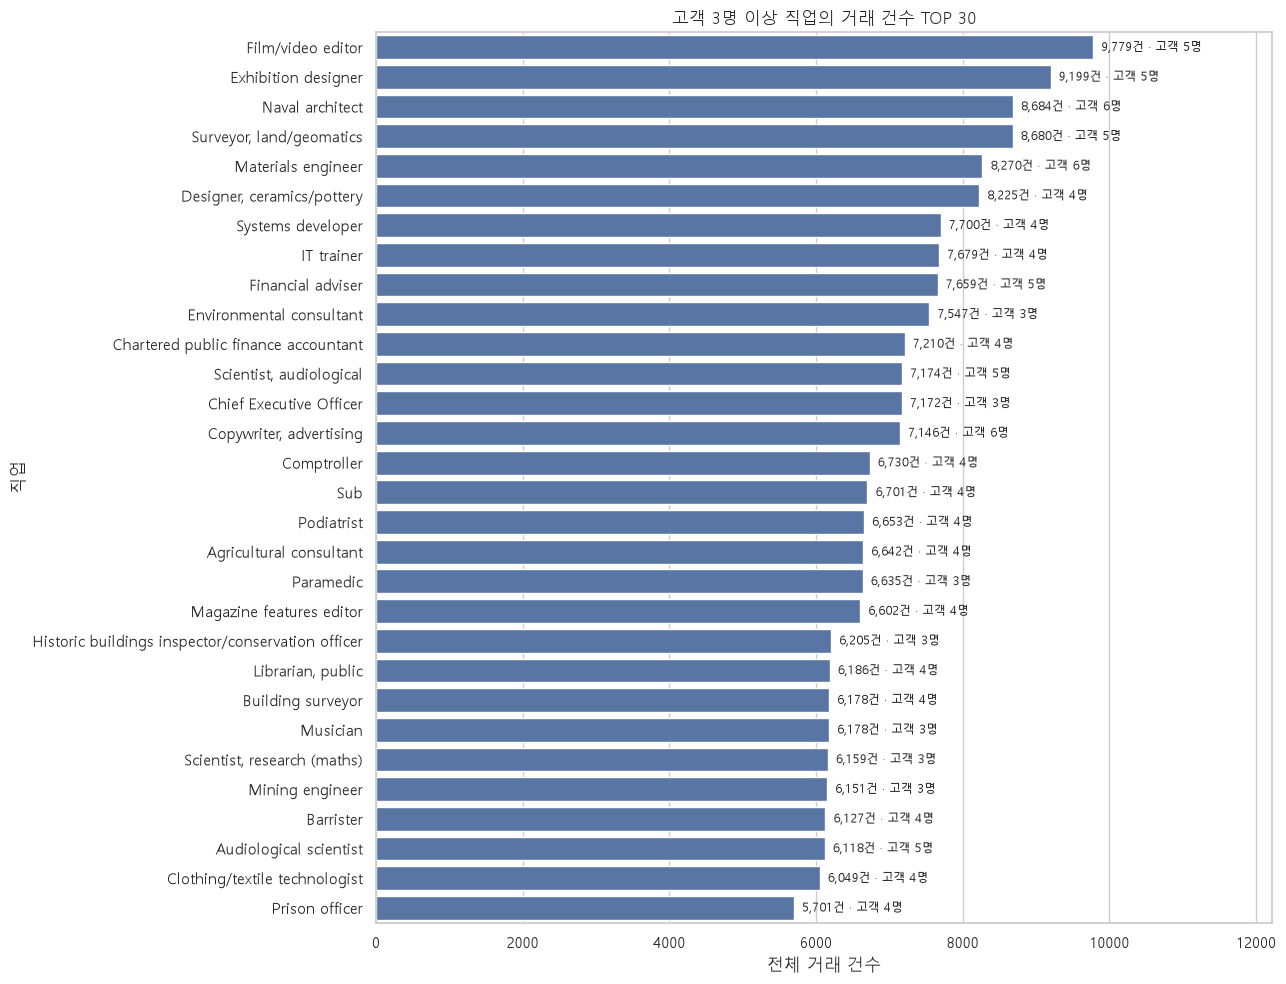

In [84]:
job_top30_transactions = (
    job_summary_customer3
    .sort_values(
        "total_transactions",
        ascending=False
    )
    .head(30)
    .copy()
)

plt.figure(figsize=(13, 10))

ax = sns.barplot(
    data=job_top30_transactions,
    x="total_transactions",
    y="job",
    order=job_top30_transactions["job"]
)

for patch, (_, row) in zip(
    ax.patches,
    job_top30_transactions.iterrows()
):
    ax.text(
        patch.get_width(),
        patch.get_y() + patch.get_height() / 2,
        (
            f"  {int(row['total_transactions']):,}건"
            f" · 고객 {int(row['customer_count'])}명"
        ),
        va="center",
        fontsize=8.5
    )

plt.title("고객 3명 이상 직업의 거래 건수 TOP 30")
plt.xlabel("전체 거래 건수")
plt.ylabel("직업")
plt.xlim(
    0,
    job_top30_transactions["total_transactions"].max() * 1.25
)
plt.tight_layout()
plt.show()

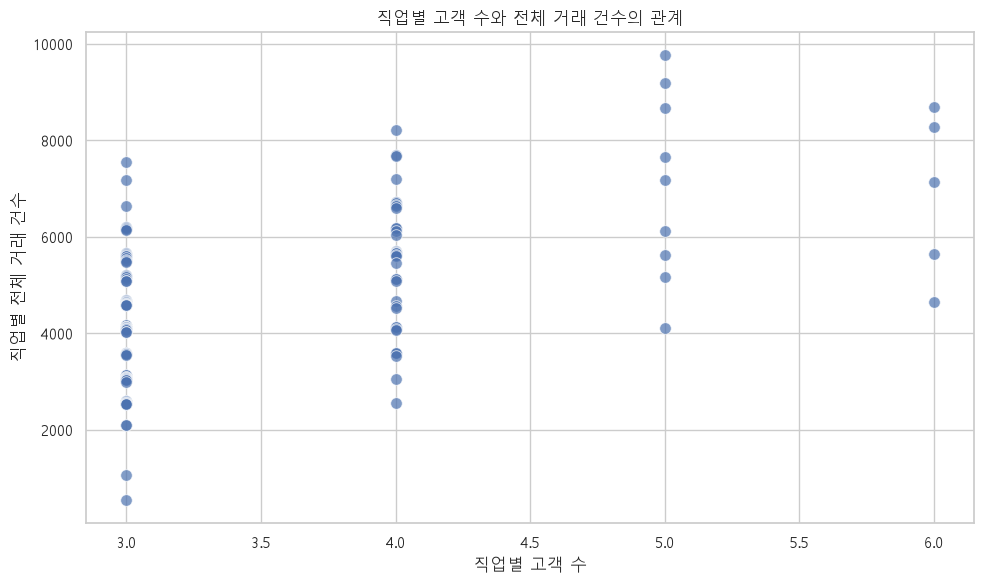

In [85]:
plt.figure(figsize=(10, 6))

sns.scatterplot(
    data=job_summary_customer3,
    x="customer_count",
    y="total_transactions",
    s=70,
    alpha=0.7
)

plt.title("직업별 고객 수와 전체 거래 건수의 관계")
plt.xlabel("직업별 고객 수")
plt.ylabel("직업별 전체 거래 건수")
plt.tight_layout()
plt.show()

#### 결론: job 은 의미있는 변수가 x.

전체 직업 종류: 494

고객 3명 이상인 직업 종류: 129

'고객 3명 이상인 직업의 거래 건수 TOP 30'에도 고객이 3-6명뿐.

=> 직업 종류가 많다보니, 고객 수가 1-6명이어서 job으로 위험 요인을 판단할 수 없음.

# 가설 검정 하기 전, 추가 필요EDA 진행

##### 이상거래만 한 고객 75명의 거래 금액 중앙값과 평균은?

In [6]:
## 이상거래율 100% 고객 75명 추출

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 시각화 설정
sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 고객별 전체 거래 건수와 이상거래 건수 계산
fraud_only_customer_summary = (
    train.groupby("cc_num", as_index=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum")
    )
)

# 전체 거래가 모두 이상거래인 고객만 추출
fraud_only_customer_summary = fraud_only_customer_summary.loc[
    (fraud_only_customer_summary["total_transactions"] > 0)
    & (
        fraud_only_customer_summary["total_transactions"]
        == fraud_only_customer_summary["is_fraud_transactions"]
    )
].copy()

# 이상거래율 계산
fraud_only_customer_summary["is_fraud_rate_pct"] = (
    fraud_only_customer_summary["is_fraud_transactions"]
    / fraud_only_customer_summary["total_transactions"]
    * 100
)

# 75명의 고객번호
fraud_only_customer_ids = fraud_only_customer_summary["cc_num"]

print("전체 거래가 모두 이상거래인 고객 수:",
      fraud_only_customer_ids.nunique())

display(
    fraud_only_customer_summary
    .sort_values("total_transactions", ascending=False)
)

전체 거래가 모두 이상거래인 고객 수: 75


,cc_num,total_transactions,is_fraud_transactions,is_fraud_rate_pct
118,4593569795412,19,19,100.0000
11,501851115094,15,15,100.0000
484,3521260686633367,15,15,100.0000
658,4168696938629925,15,15,100.0000
566,3562793934111141,13,13,100.0000
...,...,...,...,...
668,4225628813173670,7,7,100.0000
751,4734310647841293,7,7,100.0000
844,6011732631674654,7,7,100.0000
882,6577777028615915,7,7,100.0000


In [7]:
# 해당 75명의 모든 거래 추출
fraud_only_transactions_75 = train.loc[
    train["cc_num"].isin(fraud_only_customer_ids)
].copy()

print("75명의 전체 거래 건수:",
      len(fraud_only_transactions_75))

print("정상거래 건수:",
      (fraud_only_transactions_75["is_fraud"] == 0).sum())

print("이상거래 건수:",
      (fraud_only_transactions_75["is_fraud"] == 1).sum())

75명의 전체 거래 건수: 741
정상거래 건수: 0
이상거래 건수: 741


In [9]:
## 75명 전체 거래금액의 중앙값과 평균값

fraud_only_amount_summary = pd.DataFrame({
    "고객 수": [
        fraud_only_transactions_75["cc_num"].nunique()
    ],
    "전체 거래 건수": [
        len(fraud_only_transactions_75)
    ],
    "거래금액 평균": [
        fraud_only_transactions_75["amt"].mean()
    ],
    "거래금액 중앙값": [
        fraud_only_transactions_75["amt"].median()
    ],
    "거래금액 표준편차": [
        fraud_only_transactions_75["amt"].std()
    ],
    "최솟값": [
        fraud_only_transactions_75["amt"].min()
    ],
    "제1사분위수": [
        fraud_only_transactions_75["amt"].quantile(0.25)
    ],
    "제3사분위수": [
        fraud_only_transactions_75["amt"].quantile(0.75)
    ],
    "최댓값": [
        fraud_only_transactions_75["amt"].max()
    ]
})

display(
    fraud_only_amount_summary.round(2)
)

,고객 수,전체 거래 건수,거래금액 평균,거래금액 중앙값,거래금액 표준편차,최솟값,제1사분위수,제3사분위수,최댓값
0,75,741,597.0600,754.9900,398.3000,6.2300,283.2600,956.7000,"1,376.0400"


대상 고객 수: 75
전체 거래 건수: 741
거래금액 평균: 597.06
거래금액 중앙값: 754.99


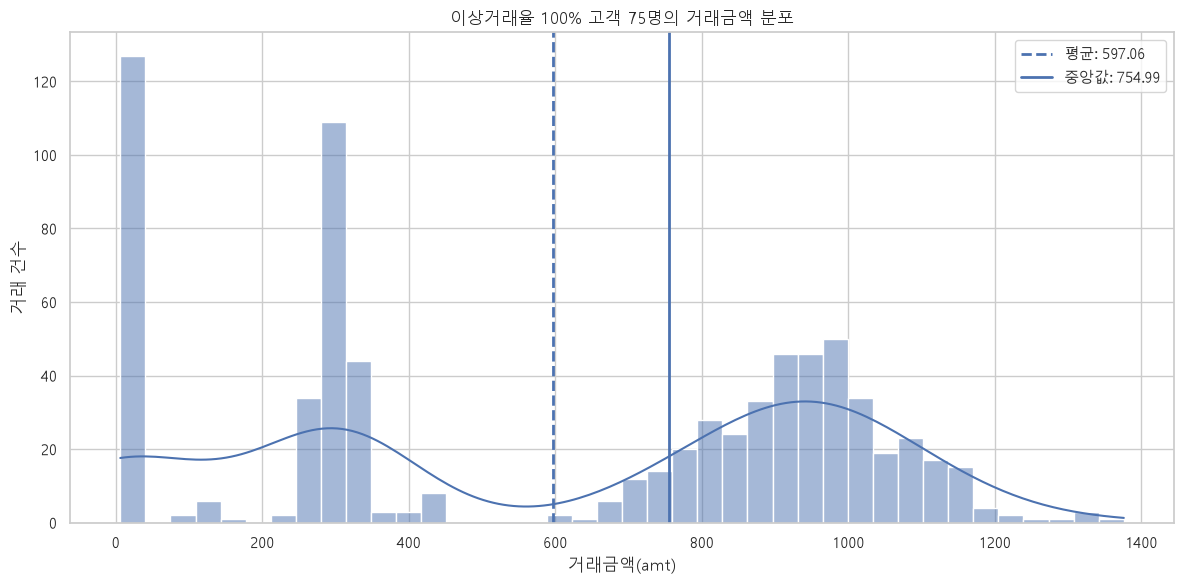

In [ ]:
## 거래금액 분포 시각화

import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

# 고객별 거래 요약
fraud_only_customer_summary = (
    train.groupby("cc_num", as_index=False)
    .agg(
        total_transactions=("is_fraud", "size"),
        is_fraud_transactions=("is_fraud", "sum")
    )
)

# 모든 거래가 이상거래인 고객 추출
fraud_only_customer_summary = fraud_only_customer_summary.loc[
    fraud_only_customer_summary["total_transactions"]
    == fraud_only_customer_summary["is_fraud_transactions"]
].copy()

fraud_only_customer_ids = fraud_only_customer_summary["cc_num"]

# 해당 75명의 전체 거래 추출
fraud_only_transactions_75 = train.loc[
    train["cc_num"].isin(fraud_only_customer_ids)
].copy()

# 전체 거래금액 평균과 중앙값
fraud_only_amt_mean = fraud_only_transactions_75["amt"].mean()
fraud_only_amt_median = fraud_only_transactions_75["amt"].median()

print("대상 고객 수:",
      fraud_only_transactions_75["cc_num"].nunique())
print("전체 거래 건수:",
      len(fraud_only_transactions_75))
print(f"거래금액 평균: {fraud_only_amt_mean:,.2f}")
print(f"거래금액 중앙값: {fraud_only_amt_median:,.2f}")


# 거래금액 분포 시각화
plt.figure(figsize=(12, 6))

sns.histplot(
    data=fraud_only_transactions_75,
    x="amt",
    bins=40,
    kde=True
)

plt.axvline(
    fraud_only_amt_mean,
    linestyle="--",
    linewidth=2,
    label=f"평균: {fraud_only_amt_mean:,.2f}"
)

plt.axvline(
    fraud_only_amt_median,
    linestyle="-",
    linewidth=2,
    label=f"중앙값: {fraud_only_amt_median:,.2f}"
)

plt.title("이상거래율 100% 고객 75명의 거래금액 분포")
plt.xlabel("거래금액(amt)")
plt.ylabel("거래 건수")
plt.legend()
plt.tight_layout()
plt.show()

##### 3개의 군집별로 (이상)거래 금액의 중앙값, 평균을 수치적으로 확인해보자

In [ ]:
import numpy as np
import pandas as pd

# 원본을 보존하기 위해 복사본 생성
amount_cluster_data_75 = fraud_only_transactions_75.copy()

# 그래프상 군집 사이의 빈 구간을 기준으로 3개 군집 정의
amount_cluster_data_75["amount_cluster"] = pd.cut(
    amount_cluster_data_75["amt"],
    bins=[-np.inf, 200, 500, np.inf],
    labels=[
        "군집 1: 200 미만",
        "군집 2: 200 이상 500 미만",
        "군집 3: 500 이상"
    ],
    right=False
)

# 군집별 거래금액 요약
amount_cluster_summary = (
    amount_cluster_data_75
    .groupby("amount_cluster", observed=True)
    .agg(
        transaction_count=("amt", "size"),
        customer_count=("cc_num", "nunique"),
        mean_amt=("amt", "mean"),
        median_amt=("amt", "median"),
        min_amt=("amt", "min"),
        q1_amt=("amt", lambda x: x.quantile(0.25)),
        q3_amt=("amt", lambda x: x.quantile(0.75)),
        max_amt=("amt", "max")
    )
    .reset_index()
)

display(amount_cluster_summary.round(2))

,amount_cluster,transaction_count,customer_count,mean_amt,median_amt,min_amt,q1_amt,q3_amt,max_amt
0,군집 1: 200 미만,136,63,18.6700,10.0600,6.2300,8.7700,12.8700,143.5400
1,군집 2: 200 이상 500 미만,203,72,304.7600,299.4900,221.7800,283.4200,315.4600,440.9200
2,군집 3: 500 이상,402,73,940.3300,941.2700,609.5800,854.8800,"1,016.2500","1,376.0400"


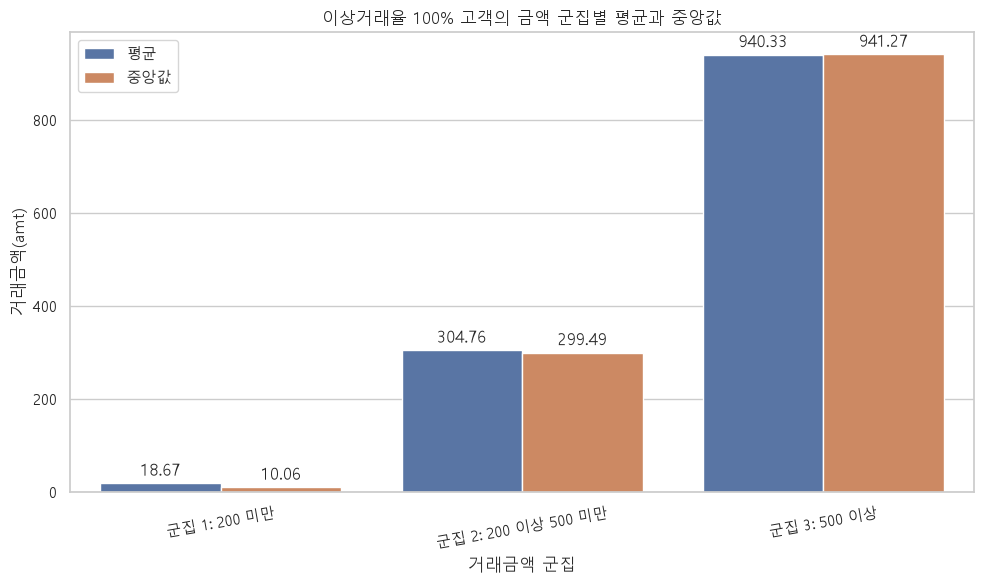

In [16]:
## 군집별 평균, 중앙값 시각화

import matplotlib.pyplot as plt
import seaborn as sns

amount_cluster_plot = amount_cluster_summary.melt(
    id_vars="amount_cluster",
    value_vars=["mean_amt", "median_amt"],
    var_name="statistic",
    value_name="amt"
)

amount_cluster_plot["statistic"] = amount_cluster_plot["statistic"].replace({
    "mean_amt": "평균",
    "median_amt": "중앙값"
})

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=amount_cluster_plot,
    x="amount_cluster",
    y="amt",
    hue="statistic"
)

for container in ax.containers:
    ax.bar_label(
        container,
        fmt="%.2f",
        padding=3
    )

plt.title("이상거래율 100% 고객의 금액 군집별 평균과 중앙값")
plt.xlabel("거래금액 군집")
plt.ylabel("거래금액(amt)")
plt.xticks(rotation=10)
plt.legend(title="")
plt.tight_layout()
plt.show()

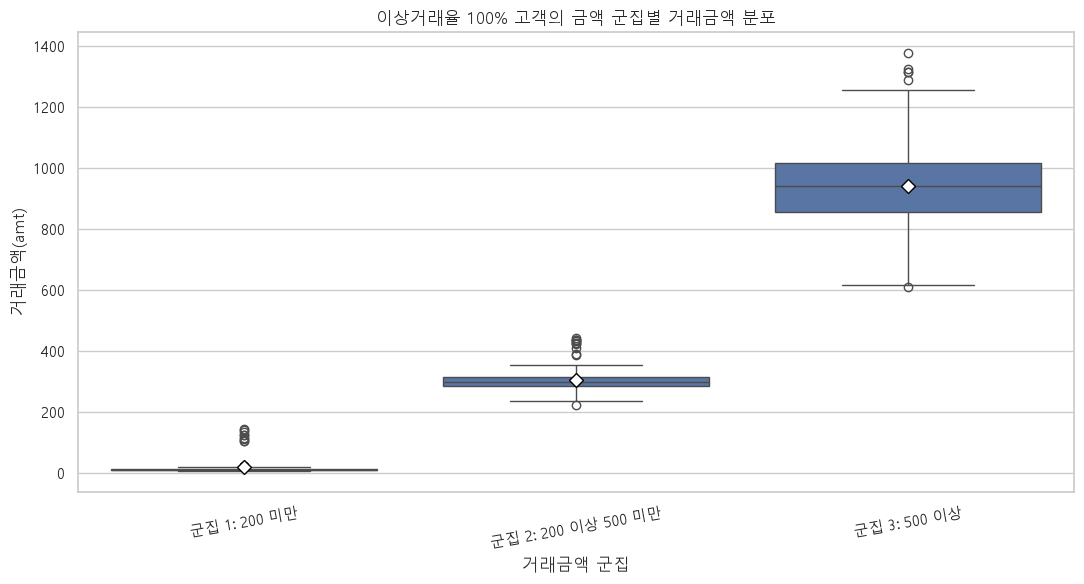

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(11, 6))

ax = sns.boxplot(
    data=amount_cluster_data_75,
    x="amount_cluster",
    y="amt",
    showmeans=True,
    meanprops={
        "marker": "D",
        "markerfacecolor": "white",
        "markeredgecolor": "black",
        "markersize": 7
    }
)

plt.title("이상거래율 100% 고객의 금액 군집별 거래금액 분포")
plt.xlabel("거래금액 군집")
plt.ylabel("거래금액(amt)")
plt.xticks(rotation=10)
plt.tight_layout()
plt.show()

In [ ]:
# 정상거래만 사용해 고객별 정상거래 수 계산
customer_normal_tx_count = (
    train.loc[train["is_fraud"].eq(0)]
    .groupby("cc_num")
    .size()
    .rename("normal_transactions")
    .reset_index()
)

# 정상거래가 20건 이상인 고객
eligible_customers_20 = customer_normal_tx_count.loc[
    customer_normal_tx_count["normal_transactions"] >= 20,
    "cc_num"
]

# 선정된 고객의 정상거래와 이상거래를 모두 추출
train_eligible_20 = train.loc[
    train["cc_num"].isin(eligible_customers_20)
].copy()

# 08/01 EDA 3가지 추가 (연령대, 성별)

### 1. 연령대별 이상거래 건수

In [4]:
## 연령대별 이상거래 건수

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False


# 연령대 분석용 데이터 복사
# 원본 train은 변경하지 않음
age_analysis = train.copy()


# 거래일시와 생년월일을 날짜 형식으로 변환
age_analysis["trans_datetime"] = pd.to_datetime(
    age_analysis["trans_date_trans_time"],
    errors="coerce"
)

age_analysis["birth_date"] = pd.to_datetime(
    age_analysis["dob"],
    errors="coerce"
)


# 거래 당시 만 나이 계산
age_analysis["age"] = (
    age_analysis["trans_datetime"].dt.year
    - age_analysis["birth_date"].dt.year
    - (
        (
            age_analysis["trans_datetime"].dt.month
            < age_analysis["birth_date"].dt.month
        )
        |
        (
            (
                age_analysis["trans_datetime"].dt.month
                == age_analysis["birth_date"].dt.month
            )
            &
            (
                age_analysis["trans_datetime"].dt.day
                < age_analysis["birth_date"].dt.day
            )
        )
    ).astype(int)
)


# 연령대 구간 설정
age_labels = [
    "20세 미만",
    "20대",
    "30대",
    "40대",
    "50대",
    "60세 이상"
]

age_analysis["age_group"] = pd.cut(
    age_analysis["age"],
    bins=[-np.inf, 20, 30, 40, 50, 60, np.inf],
    labels=age_labels,
    right=False
)


# 이상거래만 추출
fraud_age_data = age_analysis.loc[
    (age_analysis["is_fraud"] == 1)
    & age_analysis["age_group"].notna()
].copy()


# 연령대별 이상거래 건수 집계
age_fraud_count = (
    fraud_age_data
    .groupby("age_group", observed=False)
    .size()
    .rename("fraud_transaction_count")
    .reset_index()
)

display(age_fraud_count)

,age_group,fraud_transaction_count
0,20세 미만,223
1,20대,1223
2,30대,1286
3,40대,1385
4,50대,1388
5,60세 이상,2001


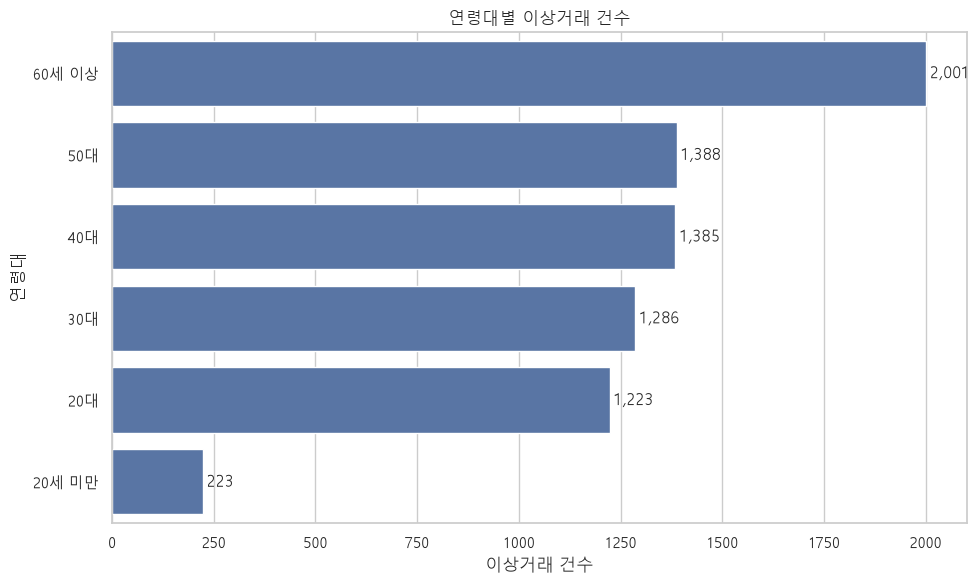

In [5]:
## 시각화

# 이미지처럼 고연령층이 위에 나오도록 순서를 반대로 설정
plot_order = age_labels[::-1]

plt.figure(figsize=(10, 6))

ax = sns.barplot(
    data=age_fraud_count,
    y="age_group",
    x="fraud_transaction_count",
    order=plot_order
)

# 막대 끝에 건수 표시
for container in ax.containers:
    ax.bar_label(
        container,
        labels=[
            f"{int(value):,}"
            for value in container.datavalues
        ],
        padding=3
    )

plt.title("연령대별 이상거래 건수")
plt.xlabel("이상거래 건수")
plt.ylabel("연령대")
plt.tight_layout()
plt.show()

이 그래프는 고객의 연령이 높을수록 사기 거래 피해 발생 건수가 많아진다는 사실을 보여준다. 60세 이상 고객층은 약 2,000건의 사기 피해를 입었는데, 이는 20세 미만 고객층보다 8배나 많은 수치이다. 한편, 20세에서 60세 사이의 고객들은 연령대별로 약 1,250건의 사기 거래를 경험했다.

### 2. 이상 거래 금액(amt)과 연령대별 관계

In [6]:
## 분석 데이터 및 요약표

# 연령대별 이상거래 금액 분석용 데이터
# 원본 train과 age_analysis는 변경하지 않음
fraud_age_amount = age_analysis.loc[
    (age_analysis["is_fraud"] == 1)
    & age_analysis["age_group"].notna()
    & age_analysis["amt"].notna(),
    ["cc_num", "age", "age_group", "amt"]
].copy()

print(f"분석 대상 이상거래 수: {len(fraud_age_amount):,}건")

# 연령대별 이상거래 금액 요약
age_amount_summary = (
    fraud_age_amount
    .groupby("age_group", observed=False)["amt"]
    .agg(
        transaction_count="count",
        mean_amount="mean",
        median_amount="median",
        min_amount="min",
        max_amount="max",
        q1_amount=lambda x: x.quantile(0.25),
        q3_amount=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

# 보기 좋게 반올림
amount_columns = [
    "mean_amount",
    "median_amount",
    "min_amount",
    "max_amount",
    "q1_amount",
    "q3_amount"
]

age_amount_summary[amount_columns] = (
    age_amount_summary[amount_columns].round(2)
)

display(age_amount_summary)

분석 대상 이상거래 수: 7,506건


,age_group,transaction_count,mean_amount,median_amount,min_amount,max_amount,q1_amount,q3_amount
0,20세 미만,223,590.6100,736.1800,6.3300,"1,292.2100",269.8000,962.6800
1,20대,1223,527.7500,424.3800,5.9700,"1,376.0400",157.4300,902.8800
2,30대,1286,496.0100,353.2100,6.6900,"1,258.3800",111.7200,860.4800
3,40대,1385,471.4200,332.1300,2.4500,"1,294.8300",25.5400,857.4900
4,50대,1388,560.4900,667.3600,1.1800,"1,281.5100",283.7100,916.5900
5,60세 이상,2001,570.8100,686.7400,1.0600,"1,286.2700",291.8800,921.4600


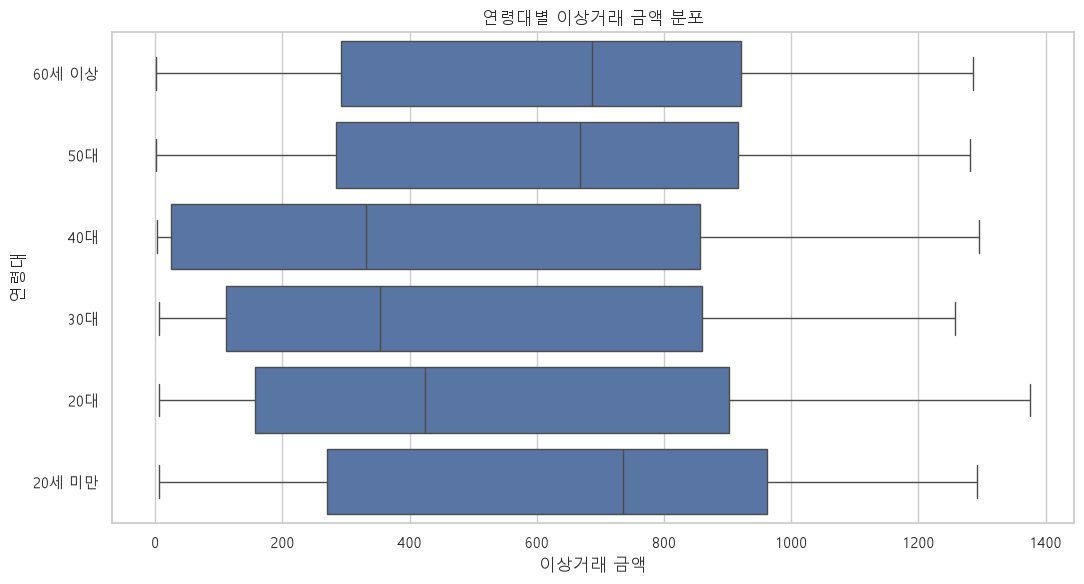

In [7]:
## 박스플롯 시각화

# 60세 이상부터 20세 미만 순서로 표시
plot_order = [
    "60세 이상",
    "50대",
    "40대",
    "30대",
    "20대",
    "20세 미만"
]

plt.figure(figsize=(11, 6))

sns.boxplot(
    data=fraud_age_amount,
    y="age_group",
    x="amt",
    order=plot_order,
    showfliers=False
)

plt.title("연령대별 이상거래 금액 분포")
plt.xlabel("이상거래 금액")
plt.ylabel("연령대")
plt.tight_layout()
plt.show()

이전 그래프에서 '20세 미만' 고객의 사기 거래 건수가 가장 적다는 것을 알 수 있었다. 그러나 이 그림에서 볼 수 있듯이, 가장 어린 고객들이 사기 피해를 입었을 때 가장 큰 금액의 손실을 입었으며, 그 중간값은 700달러가 넘었다. '50~60세'와 '60세 이상' 그룹 역시 약 700달러의 손실을 경험했다. 20세에서 50세 사이의 나머지 세 그룹은 중간값이 약 400달러였다.

### 3. 거래 금액(amt) vs 연령대 vs 성별

: 연령대 및 성별에 따른 이상거래 금액 분포

In [8]:
## 분석 데이터 생성 및 요약

# 연령대·성별 이상거래 금액 분석용 데이터
# 원본 train과 age_analysis는 변경하지 않음
fraud_age_gender_amount = age_analysis.loc[
    (age_analysis["is_fraud"] == 1)
    & age_analysis["age_group"].notna()
    & age_analysis["gender"].notna()
    & age_analysis["amt"].notna(),
    ["cc_num", "age", "age_group", "gender", "amt"]
].copy()


# 성별 표시명을 한글로 변환
# 원본 gender 열은 변경하지 않음
fraud_age_gender_amount["gender_label"] = (
    fraud_age_gender_amount["gender"]
    .map({
        "M": "남성",
        "F": "여성"
    })
    .fillna(fraud_age_gender_amount["gender"])
)


print(
    f"분석 대상 이상거래 수: "
    f"{len(fraud_age_gender_amount):,}건"
)


# 연령대·성별 이상거래 금액 요약
age_gender_amount_summary = (
    fraud_age_gender_amount
    .groupby(
        ["age_group", "gender_label"],
        observed=False
    )["amt"]
    .agg(
        transaction_count="count",
        mean_amount="mean",
        median_amount="median",
        q1_amount=lambda x: x.quantile(0.25),
        q3_amount=lambda x: x.quantile(0.75),
        min_amount="min",
        max_amount="max"
    )
    .reset_index()
)


amount_columns = [
    "mean_amount",
    "median_amount",
    "q1_amount",
    "q3_amount",
    "min_amount",
    "max_amount"
]

age_gender_amount_summary[amount_columns] = (
    age_gender_amount_summary[amount_columns]
    .round(2)
)

display(age_gender_amount_summary)

분석 대상 이상거래 수: 7,506건


,age_group,gender_label,transaction_count,mean_amount,median_amount,q1_amount,q3_amount,min_amount,max_amount
0,20세 미만,남성,113,667.5400,798.9500,293.0900,"1,024.0400",8.2400,"1,292.2100"
1,20세 미만,여성,110,511.5900,323.4600,20.8800,915.5900,6.3300,"1,256.4300"
2,20대,남성,587,568.0600,696.2900,286.7000,918.2800,5.9700,"1,371.8100"
3,20대,여성,636,490.5300,353.7200,22.3600,875.8100,6.4200,"1,376.0400"
4,30대,남성,660,585.6600,722.1800,288.6600,928.1400,6.7000,"1,258.3800"
5,30대,여성,626,401.4800,324.3900,20.8400,769.3000,6.6900,"1,210.9100"
6,40대,남성,717,551.5000,544.9000,282.3100,903.3800,5.9900,"1,294.8300"
7,40대,여성,668,385.4700,289.2300,20.9800,767.6500,2.4500,"1,289.8900"
8,50대,남성,776,564.8000,676.9400,280.8100,919.9000,1.1800,"1,268.1800"
9,50대,여성,612,555.0300,497.2600,289.8800,912.0000,2.1300,"1,281.5100"


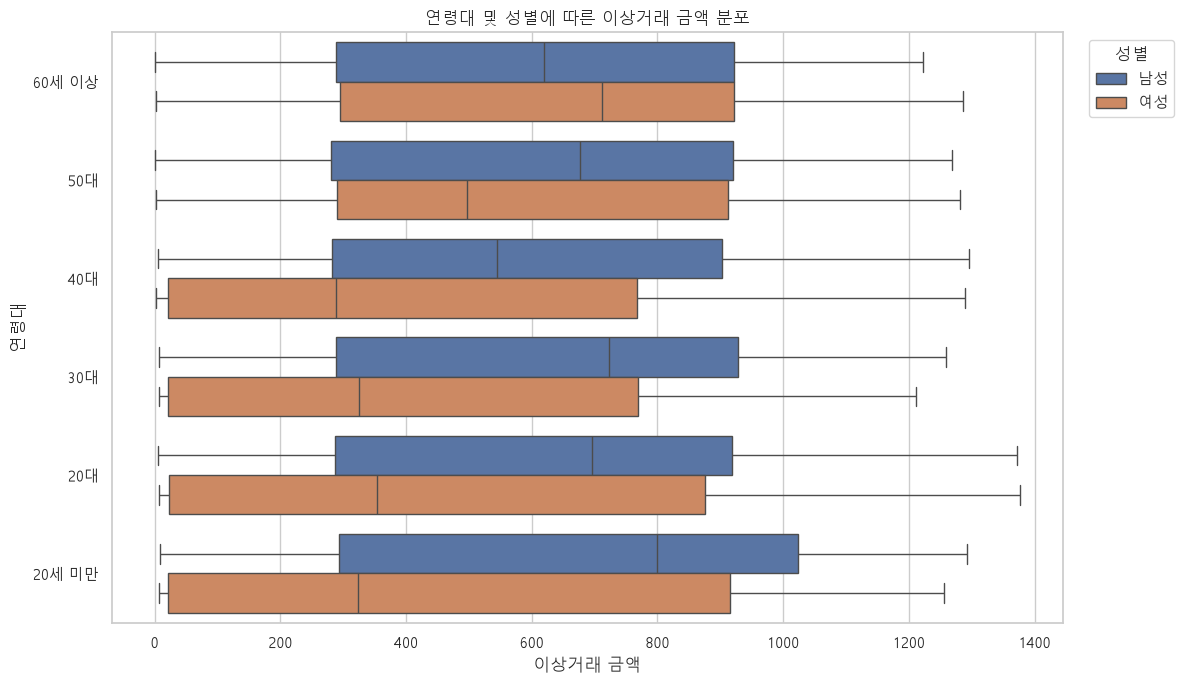

In [9]:
## 연령대 및 성별 박스플롯

plot_order = [
    "60세 이상",
    "50대",
    "40대",
    "30대",
    "20대",
    "20세 미만"
]

plt.figure(figsize=(12, 7))

sns.boxplot(
    data=fraud_age_gender_amount,
    y="age_group",
    x="amt",
    hue="gender_label",
    order=plot_order,
    hue_order=["남성", "여성"],
    showfliers=False
)

plt.title("연령대 및 성별에 따른 이상거래 금액 분포")
plt.xlabel("이상거래 금액")
plt.ylabel("연령대")
plt.legend(
    title="성별",
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)
plt.tight_layout()
plt.show()

모든 연령대에서 남성 고객이 여성 고객보다 중간값 기준으로 더 많은 돈을 잃었음을 알 수 있다. 단, 가장 고령층인 '60세 이상 '은 예외이다.